In [6]:
pip install kagglehub[pandas-datasets]

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import os

# Set the path to your dataset directory
dataset_path = r"C:\Users\AC\OneDrive\Documents\personalised_dataset"

# Load the CSV file
df = pd.read_csv(os.path.join(dataset_path, "personalised_dataset.csv"))

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 records:")
print(df.head(20))
print("\nDataset info:")
print(df.info())

Dataset shape: (2000, 40)

Column names:
['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'Heart_Disease_Risk', 'Diabetes_Risk', 'Health_Risk', 'Predicted_Insurance_Cost', 'Diet_Recommendation', 'Exercise_Recommendation', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index', 'Sleep_Hours', 'Sleep_Quality', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference']

First 5 records:
    Patient_ID  Age  Gender   BMI  Smoking_Status Alcohol_Consumption  \
0            1   55    Male  26.0  Current smoker                 NaN   
1            2   33    Male  29.5      Non-smoker                 Low   
2            3   62  Female  31.3    

In [8]:
# Basic dataset information
print("Dataset shape:", df.shape)

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Missing percentage
print("\nMissing percentage:")
print((df.isnull().mean() * 100).round(2)[df.isnull().mean() > 0])

# Unique values for categorical variables
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print("\nCategorical variables:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

# Numeric summary
print("\nNumerical summary:")
display(df.describe().T)

Dataset shape: (2000, 40)

Duplicate rows: 0

Missing values:
Alcohol_Consumption    470
dtype: int64

Missing percentage:
Alcohol_Consumption    23.5
dtype: float64

Categorical variables:

Gender:
Gender
Male      1037
Female     963
Name: count, dtype: int64

Smoking_Status:
Smoking_Status
Non-smoker        1141
Former smoker      450
Current smoker     409
Name: count, dtype: int64

Alcohol_Consumption:
Alcohol_Consumption
Moderate    664
Low         551
NaN         470
High        315
Name: count, dtype: int64

Physical_Activity_Level:
Physical_Activity_Level
Lightly Active       599
Moderately Active    598
Sedentary            526
Highly Active        277
Name: count, dtype: int64

Diet_Type:
Diet_Type
Balanced         365
Vegan            346
Vegetarian       340
High Protein     323
Mediterranean    321
Keto             305
Name: count, dtype: int64

Blood_Pressure:
Blood_Pressure
115/74    7
113/73    7
117/79    7
106/72    7
106/68    6
         ..
96/67     1
94/67     1
1

,count,mean,std,min,25%,50%,75%,max
Patient_ID,2000.0,1000.500000,577.494589,1.000,500.75000,1000.5000,1500.25000,2000.000
Age,2000.0,49.226000,15.477425,18.000,38.00000,50.0000,60.00000,85.000
BMI,2000.0,27.170100,5.089991,16.000,23.80000,26.9000,30.50000,50.300
Cholesterol,2000.0,197.225500,34.674183,83.600,174.87500,198.1500,219.20000,328.400
Glucose_Level,2000.0,91.485250,12.773423,50.000,83.10000,91.4000,99.80000,134.200
HbA1c,2000.0,5.065200,0.630173,3.500,4.60000,5.1000,5.50000,7.100
Predicted_Insurance_Cost,2000.0,1343.072010,750.814938,331.800,598.19000,1191.9000,2018.10250,3684.190
PRS_Cardiometabolic,2000.0,-0.008260,0.996130,-2.909,-0.68800,-0.0040,0.66325,2.939
PRS_Type2Diabetes,2000.0,0.009289,1.001611,-3.000,-0.67675,0.0025,0.71025,3.000
APOE_e4_Carrier,2000.0,0.145000,0.352189,0.000,0.00000,0.0000,0.00000,1.000


In [9]:
# Extract SBP and DBP from Blood_Pressure
bp_split = df['Blood_Pressure'].str.split('/', expand=True)

df['BP_Systolic_from_String'] = pd.to_numeric(bp_split[0])
df['BP_Diastolic_from_String'] = pd.to_numeric(bp_split[1])

# Check consistency
print("Systolic BP mismatches:",
      (df['BP_Systolic_from_String'] != df['Systolic_BP']).sum())

print("Diastolic BP mismatches:",
      (df['BP_Diastolic_from_String'] != df['Diastolic_BP']).sum())

Systolic BP mismatches: 0
Diastolic BP mismatches: 0


In [10]:
pd.crosstab(
    df['Smoking_Status'],
    df['Alcohol_Consumption'],
    margins=True,
    dropna=False
)

Alcohol_Consumption,High,Low,Moderate,NaN,All
Smoking_Status,,,,,
Current smoker,53,123,146,87,409
Former smoker,72,128,137,113,450
Non-smoker,190,300,381,270,1141
All,315,551,664,470,2000


In [11]:
pd.crosstab(
    df['Gender'],
    df['Alcohol_Consumption'],
    margins=True,
    dropna=False
)

Alcohol_Consumption,High,Low,Moderate,NaN,All
Gender,,,,,
Female,141,259,327,236,963
Male,174,292,337,234,1037
All,315,551,664,470,2000


In [12]:
df.groupby('Alcohol_Consumption', dropna=False)[
    ['Age', 'BMI', 'Glucose_Level', 'HbA1c',
     'Systolic_BP', 'LDL', 'Triglycerides']
].mean()

,Age,BMI,Glucose_Level,HbA1c,Systolic_BP,LDL,Triglycerides
Alcohol_Consumption,,,,,,,
High,48.015873,26.870159,90.752698,5.007937,109.682540,119.562540,148.515873
Low,49.172414,27.329220,90.890563,5.057713,111.520871,117.007623,145.294737
Moderate,49.337349,27.094578,92.321084,5.087651,111.292169,116.008434,147.604217
NaN,49.942553,27.291277,91.492553,5.080638,111.444681,116.170638,149.158085


In [13]:
import numpy as np

df['Alcohol_Missing'] = df['Alcohol_Consumption'].isna().astype(int)

print(df['Alcohol_Missing'].value_counts())

Alcohol_Missing
0    1530
1     470
Name: count, dtype: int64


In [14]:
from scipy.stats import chi2_contingency

categorical_vars = [
    'Gender',
    'Smoking_Status',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality'
]

for var in categorical_vars:
    table = pd.crosstab(df[var], df['Alcohol_Missing'])
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\n{var}")
    print(table)
    print(f"Chi-square = {chi2:.3f}, p = {p:.4f}")


Gender
Alcohol_Missing    0    1
Gender                   
Female           727  236
Male             803  234
Chi-square = 0.942, p = 0.3318

Smoking_Status
Alcohol_Missing    0    1
Smoking_Status           
Current smoker   322   87
Former smoker    337  113
Non-smoker       871  270
Chi-square = 1.797, p = 0.4073

Physical_Activity_Level
Alcohol_Missing            0    1
Physical_Activity_Level          
Highly Active            219   58
Lightly Active           451  148
Moderately Active        467  131
Sedentary                393  133
Chi-square = 3.274, p = 0.3512

Diet_Type
Alcohol_Missing    0   1
Diet_Type               
Balanced         291  74
High Protein     250  73
Keto             223  82
Mediterranean    245  76
Vegan            268  78
Vegetarian       253  87
Chi-square = 5.209, p = 0.3909

Sleep_Quality
Alcohol_Missing    0    1
Sleep_Quality            
Excellent        193   68
Fair             750  223
Good             278   70
Poor             309  109
Chi-squ

In [15]:
from scipy.stats import ttest_ind

continuous_vars = [
    'Age',
    'BMI',
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Sleep_Hours',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference'
]

for var in continuous_vars:
    observed = df.loc[df['Alcohol_Missing'] == 0, var].dropna()
    missing = df.loc[df['Alcohol_Missing'] == 1, var].dropna()

    t_stat, p = ttest_ind(
        observed,
        missing,
        equal_var=False
    )

    print(f"{var:25s} t = {t_stat:8.3f}, p = {p:.4f}")

Age                       t =   -1.113, p = 0.2662
BMI                       t =   -0.581, p = 0.5616
Cholesterol               t =    0.562, p = 0.5741
Glucose_Level             t =   -0.014, p = 0.9887
HbA1c                     t =   -0.616, p = 0.5382
Stress_Level              t =   -0.084, p = 0.9332
Depression_Score          t =   -0.713, p = 0.4759
Anxiety_Score             t =    0.182, p = 0.8554
Sleep_Hours               t =    1.165, p = 0.2443
Systolic_BP               t =   -0.569, p = 0.5692
Diastolic_BP              t =    0.525, p = 0.5998
LDL                       t =    0.574, p = 0.5659
HDL                       t =    0.827, p = 0.4087
Triglycerides             t =   -0.709, p = 0.4785
CRP                       t =   -0.056, p = 0.9551
eGFR                      t =   -0.176, p = 0.8602
Waist_Circumference       t =   -0.721, p = 0.4714


In [16]:
df['Alcohol_Consumption_Clean'] = (
    df['Alcohol_Consumption']
    .fillna('Unknown')
)

print(df['Alcohol_Consumption_Clean'].value_counts())

Alcohol_Consumption_Clean
Moderate    664
Low         551
Unknown     470
High        315
Name: count, dtype: int64


In [17]:
df['Alcohol_Consumption_Clean']

0        Unknown
1            Low
2            Low
3           High
4            Low
          ...   
1995        High
1996         Low
1997    Moderate
1998         Low
1999    Moderate
Name: Alcohol_Consumption_Clean, Length: 2000, dtype: str

In [18]:
import pandas as pd
import numpy as np

numeric_vars = [
    'Age',
    'BMI',
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Predicted_Insurance_Cost',
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Social_Isolation_Index',
    'Sleep_Hours',
    'Resting_Heart_Rate',
    'HRV',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference'
]

outlier_summary = []

for col in numeric_vars:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Outliers_n': outliers,
        'Outliers_%': (outliers / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        'Outliers_n',
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Min,Max,Outliers_n,Outliers_%
11,Social_Isolation_Index,4.00000,6.00000,2.00000,1.000000,9.000000,0.000,10.000,32,1.60
3,Glucose_Level,83.10000,99.80000,16.70000,58.050000,124.850000,50.000,134.200,23,1.15
2,Cholesterol,174.87500,219.20000,44.32500,108.387500,285.687500,83.600,328.400,21,1.05
16,Diastolic_BP,65.00000,77.00000,12.00000,47.000000,95.000000,40.000,109.000,15,0.75
15,Systolic_BP,102.00000,120.00000,18.00000,75.000000,147.000000,80.000,153.000,13,0.65
7,PRS_Type2Diabetes,-0.67675,0.71025,1.38700,-2.757250,2.790750,-3.000,3.000,13,0.65
20,CRP,0.83000,2.09000,1.26000,-1.060000,3.980000,0.000,4.710,13,0.65
19,Triglycerides,107.10000,186.52500,79.42500,-12.037500,305.662500,20.000,335.200,11,0.55
1,BMI,23.80000,30.50000,6.70000,13.750000,40.550000,16.000,50.300,10,0.50
10,Anxiety_Score,3.00000,7.00000,4.00000,-3.000000,13.000000,0.000,16.000,10,0.50


In [19]:
skewness = df[numeric_vars].skew().sort_values(ascending=False)

print(skewness)

Waist_Circumference         0.603293
Predicted_Insurance_Cost    0.434751
Anxiety_Score               0.375843
CRP                         0.333699
Depression_Score            0.287178
BMI                         0.223132
Triglycerides               0.143008
Systolic_BP                 0.099280
HbA1c                       0.089874
HDL                         0.064598
LDL                         0.059205
Diastolic_BP                0.047058
Sleep_Hours                 0.030920
Age                         0.025432
Cholesterol                 0.022176
Social_Isolation_Index      0.020629
PRS_Cardiometabolic         0.014431
Resting_Heart_Rate          0.009821
HRV                        -0.001511
Glucose_Level              -0.021651
PRS_Type2Diabetes          -0.045078
Stress_Level               -0.045127
eGFR                       -0.090299
dtype: float64


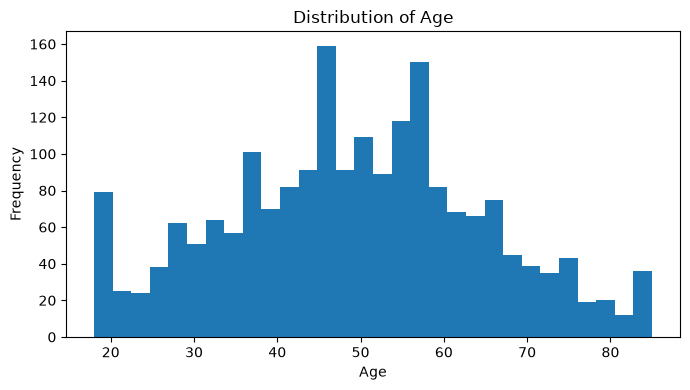

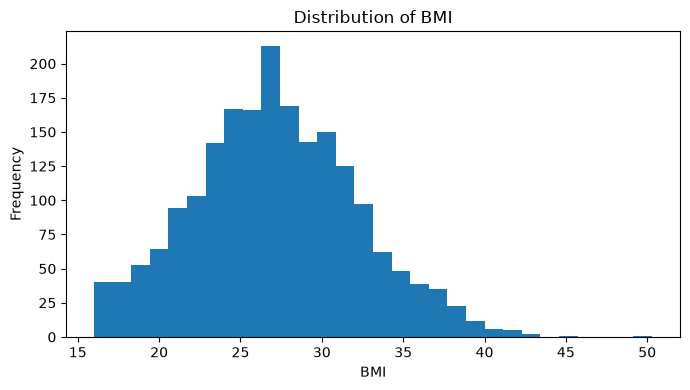

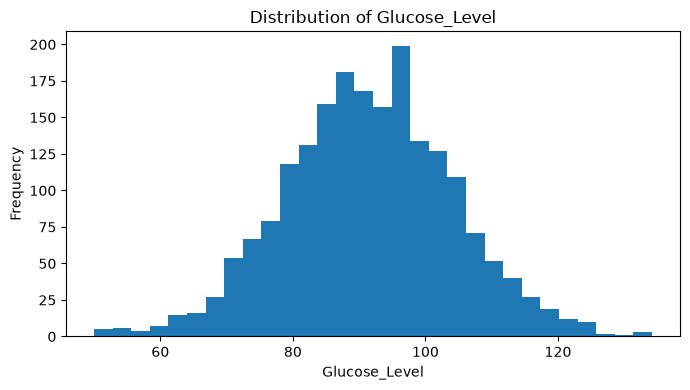

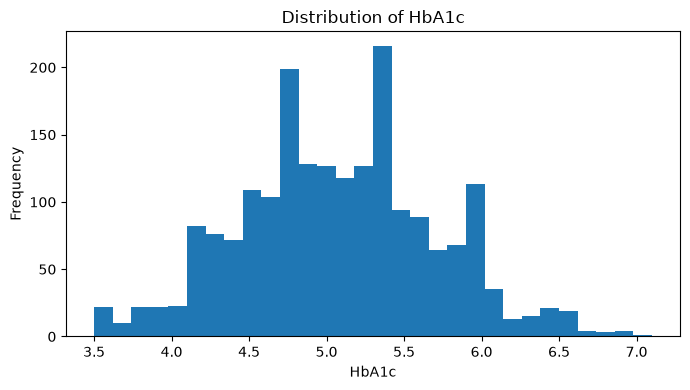

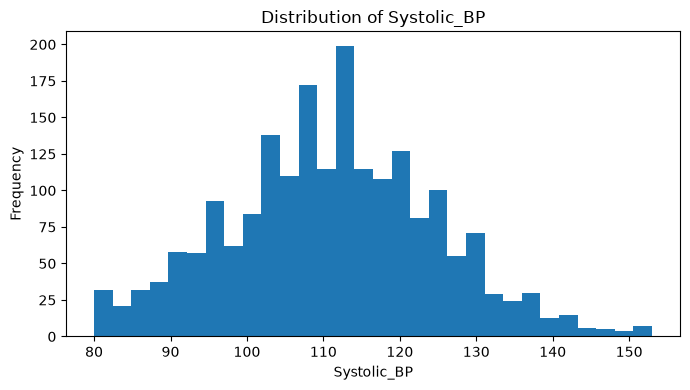

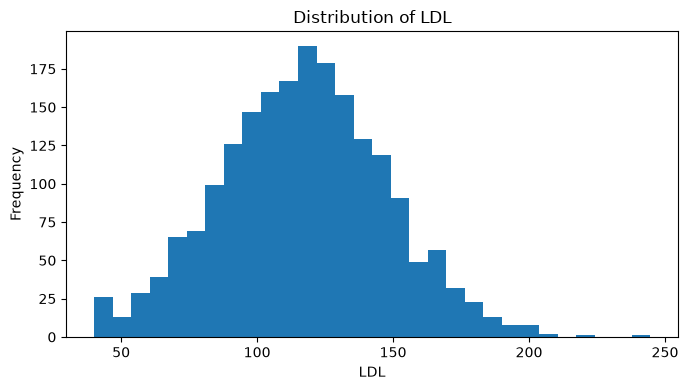

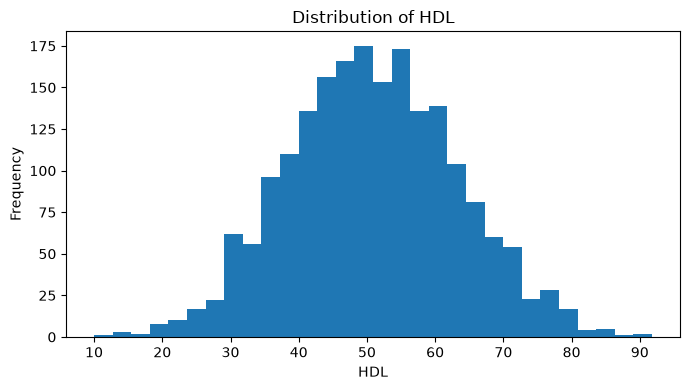

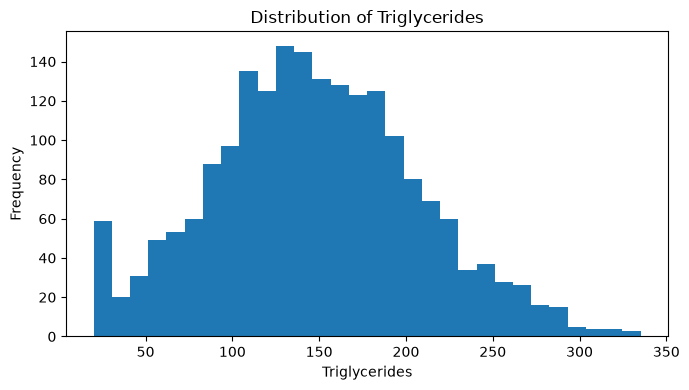

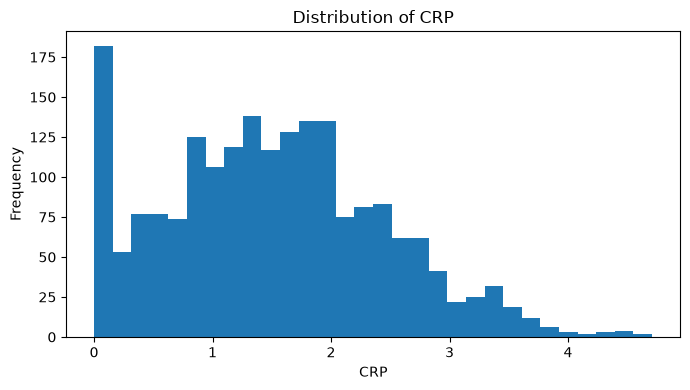

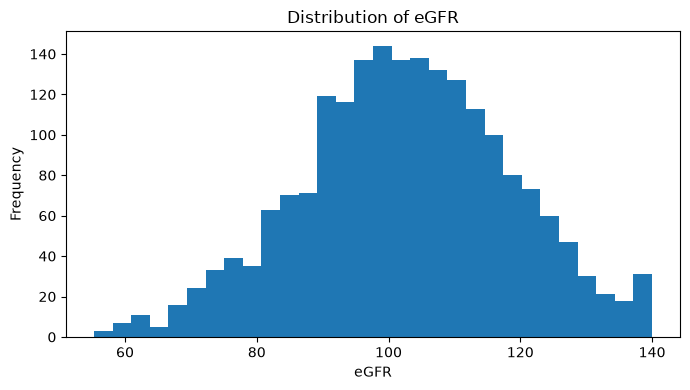

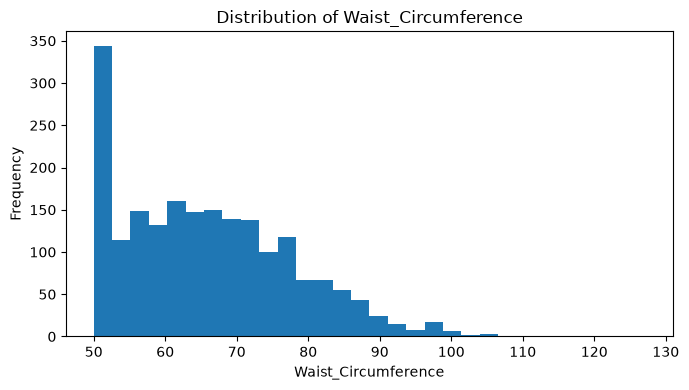

In [20]:
import matplotlib.pyplot as plt

plot_vars = [
    'Age',
    'BMI',
    'Glucose_Level',
    'HbA1c',
    'Systolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference'
]

for col in plot_vars:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [21]:
# Check Blood_Pressure consistency

bp_split = df['Blood_Pressure'].str.split('/', expand=True)

df['BP_Systolic_from_String'] = pd.to_numeric(bp_split[0])
df['BP_Diastolic_from_String'] = pd.to_numeric(bp_split[1])

print(
    "Systolic BP mismatches:",
    (df['BP_Systolic_from_String'] != df['Systolic_BP']).sum()
)

print(
    "Diastolic BP mismatches:",
    (df['BP_Diastolic_from_String'] != df['Diastolic_BP']).sum()
)

Systolic BP mismatches: 0
Diastolic BP mismatches: 0


In [22]:
# Basic clinical range checks

checks = {
    'Age < 18': (df['Age'] < 18).sum(),
    'Age > 100': (df['Age'] > 100).sum(),

    'BMI < 10': (df['BMI'] < 10).sum(),
    'BMI > 60': (df['BMI'] > 60).sum(),

    'HbA1c < 2': (df['HbA1c'] < 2).sum(),
    'HbA1c > 15': (df['HbA1c'] > 15).sum(),

    'SBP < 50': (df['Systolic_BP'] < 50).sum(),
    'SBP > 250': (df['Systolic_BP'] > 250).sum(),

    'DBP < 30': (df['Diastolic_BP'] < 30).sum(),
    'DBP > 150': (df['Diastolic_BP'] > 150).sum(),

    'HDL <= 0': (df['HDL'] <= 0).sum(),
    'LDL < 0': (df['LDL'] < 0).sum(),
    'Triglycerides < 0': (df['Triglycerides'] < 0).sum(),

    'eGFR <= 0': (df['eGFR'] <= 0).sum(),

    'Sleep_Hours <= 0': (df['Sleep_Hours'] <= 0).sum(),
    'Sleep_Hours > 24': (df['Sleep_Hours'] > 24).sum(),
}

for name, count in checks.items():
    print(f"{name}: {count}")

Age < 18: 0
Age > 100: 0
BMI < 10: 0
BMI > 60: 0
HbA1c < 2: 0
HbA1c > 15: 0
SBP < 50: 0
SBP > 250: 0
DBP < 30: 0
DBP > 150: 0
HDL <= 0: 0
LDL < 0: 0
Triglycerides < 0: 0
eGFR <= 0: 0
Sleep_Hours <= 0: 0
Sleep_Hours > 24: 0


In [23]:
df_raw = df.copy()

print(df_raw.shape)

(2000, 44)


In [24]:
df_ml = df_raw.copy()

df_ml['Alcohol_Consumption'] = (
    df_ml['Alcohol_Consumption']
    .fillna('Unknown')
)
print(df_ml['Alcohol_Consumption'].value_counts())

Alcohol_Consumption
Moderate    664
Low         551
Unknown     470
High        315
Name: count, dtype: int64


In [25]:
df_ml = df_ml.drop(
    columns=[
        'BP_Systolic_from_String',
        'BP_Diastolic_from_String'
    ],
    errors='ignore'
)

In [26]:
df_ml = df_ml.drop(columns=['Patient_ID'])

In [27]:
df_ml = df_ml.drop(columns=['Blood_Pressure'])

In [28]:
# Remove variables that are outputs/recommendations
# to prevent data leakage

df_ml = df_ml.drop(
    columns=[
        'Diet_Recommendation',
        'Exercise_Recommendation',
        'Heart_Disease_Risk',
        'Diabetes_Risk',
        'Predicted_Insurance_Cost'
    ],
    errors='ignore'
)

print("Current shape:", df_ml.shape)
print("\nRemaining columns:")
print(df_ml.columns.tolist())

Current shape: (2000, 35)

Remaining columns:
['Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'Health_Risk', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index', 'Sleep_Hours', 'Sleep_Quality', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference', 'Alcohol_Missing', 'Alcohol_Consumption_Clean']


In [29]:
# Target variable
y = df_ml['Health_Risk']

# Predictor variables
X = df_ml.drop(columns=['Health_Risk'])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True)
      .mul(100)
      .round(2)
)

X shape: (2000, 34)
y shape: (2000,)

Target distribution:
Health_Risk
Low         809
High        623
Moderate    568
Name: count, dtype: int64

Target percentage:
Health_Risk
Low         40.45
High        31.15
Moderate    28.40
Name: proportion, dtype: float64


In [30]:
categorical_cols = X.select_dtypes(
    include=['object', 'string']
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numeric_cols)

print("\nNumber of categorical variables:", len(categorical_cols))
print("Number of numerical variables:", len(numeric_cols))

Categorical variables:
['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Sleep_Quality', 'Alcohol_Consumption_Clean']

Numerical variables:
['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index', 'Sleep_Hours', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference', 'Alcohol_Missing']

Number of categorical variables: 7
Number of numerical variables: 27


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (1600, 34)
Testing set : (400, 34)

Training target:
Health_Risk
Low         647
High        498
Moderate    455
Name: count, dtype: int64

Testing target:
Health_Risk
Low         162
High        125
Moderate    113
Name: count, dtype: int64


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [33]:
# Remove redundant alcohol variables
X = X.drop(
    columns=[
        'Alcohol_Missing',
        'Alcohol_Consumption_Clean'
    ],
    errors='ignore'
)

# Re-identify feature types
categorical_cols = X.select_dtypes(
    include=['object', 'string']
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("X shape:", X.shape)

print("\nCategorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numeric_cols)

print("\nTotal features:", X.shape[1])

X shape: (2000, 32)

Categorical variables:
['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Sleep_Quality']

Numerical variables:
['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index', 'Sleep_Hours', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference']

Total features: 32


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (1600, 32)
Testing set : (400, 32)

Training target:
Health_Risk
Low         647
High        498
Moderate    455
Name: count, dtype: int64

Testing target:
Health_Risk
Low         162
High        125
Moderate    113
Name: count, dtype: int64


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessor ready.")

Preprocessor ready.


In [36]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [38]:
from sklearn.ensemble import ExtraTreesClassifier

extra_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ExtraTreesClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

extra_model.fit(X_train, y_train)

print("Extra Trees trained successfully.")

Extra Trees trained successfully.


In [39]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

models = {
    'Logistic Regression': logistic_model,
    'Random Forest': rf_model,
    'Extra Trees': extra_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro_Precision': precision_score(
            y_test, y_pred, average='macro'
        ),
        'Macro_Recall': recall_score(
            y_test, y_pred, average='macro'
        ),
        'Macro_F1': f1_score(
            y_test, y_pred, average='macro'
        ),
        'Weighted_F1': f1_score(
            y_test, y_pred, average='weighted'
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'Macro_F1',
    ascending=False
)

display(results_df.round(4))

,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1
0,Logistic Regression,0.9150,0.9127,0.9125,0.9127,0.9124,0.9156
1,Random Forest,0.7925,0.7745,0.7766,0.7745,0.7741,0.7877
2,Extra Trees,0.7625,0.7318,0.7462,0.7318,0.7175,0.7379


In [40]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n" + "="*70)
    print(name)
    print("="*70)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4
        )
    )


Logistic Regression
              precision    recall  f1-score   support

        High     0.9669    0.9360    0.9512       125
         Low     0.9317    0.9259    0.9288       162
    Moderate     0.8390    0.8761    0.8571       113

    accuracy                         0.9150       400
   macro avg     0.9125    0.9127    0.9124       400
weighted avg     0.9165    0.9150    0.9156       400


Random Forest
              precision    recall  f1-score   support

        High     0.8425    0.8560    0.8492       125
         Low     0.8343    0.9012    0.8665       162
    Moderate     0.6531    0.5664    0.6066       113

    accuracy                         0.7925       400
   macro avg     0.7766    0.7745    0.7741       400
weighted avg     0.7857    0.7925    0.7877       400


Extra Trees
              precision    recall  f1-score   support

        High     0.7551    0.8880    0.8162       125
         Low     0.7887    0.9444    0.8596       162
    Moderate     0.6949   

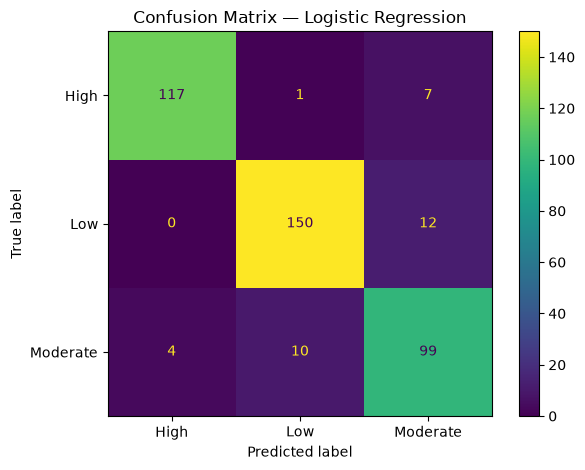

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best
)

plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'macro_f1': 'f1_macro',
    'weighted_f1': 'f1_weighted'
}

cv_results = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Balanced Accuracy',
        'Macro F1',
        'Weighted F1'
    ],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_balanced_accuracy'].mean(),
        cv_results['test_macro_f1'].mean(),
        cv_results['test_weighted_f1'].mean()
    ],
    'SD': [
        cv_results['test_accuracy'].std(),
        cv_results['test_balanced_accuracy'].std(),
        cv_results['test_macro_f1'].std(),
        cv_results['test_weighted_f1'].std()
    ]
})

display(cv_summary.round(4))

,Metric,Mean,SD
0,Accuracy,0.8930,0.0138
1,Balanced Accuracy,0.8909,0.0153
2,Macro F1,0.8898,0.0153
3,Weighted F1,0.8938,0.0142


In [43]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Preprocess X
X_processed = preprocessor.fit_transform(X)

# Feature names
feature_names = preprocessor.get_feature_names_out()

# Mutual information
mi = mutual_info_classif(
    X_processed,
    y_encoded,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': feature_names,
    'Mutual_Information': mi
}).sort_values(
    'Mutual_Information',
    ascending=False
)

display(mi_df.head(20).round(4))

,Feature,Mutual_Information
18,num__Systolic_BP,0.1524
0,num__Age,0.1504
20,num__LDL,0.1130
9,num__Family_History_CVD,0.0880
24,num__eGFR,0.0787
5,num__PRS_Cardiometabolic,0.0658
6,num__PRS_Type2Diabetes,0.0539
21,num__HDL,0.0456
19,num__Diastolic_BP,0.0384
3,num__Glucose_Level,0.0377


In [44]:
# Fit the model if necessary
logistic_model.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (
    logistic_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

classifier = logistic_model.named_steps['classifier']

coef = classifier.coef_

classes = classifier.classes_

print("Classes:")
print(classes)

Classes:
['High' 'Low' 'Moderate']


In [45]:
for i, class_name in enumerate(classes):

    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef[i],
        'Absolute_Coefficient': abs(coef[i])
    }).sort_values(
        'Absolute_Coefficient',
        ascending=False
    )

    print("\n" + "="*70)
    print(f"Top predictors for: {class_name}")
    print("="*70)

    display(coef_df.head(15))


Top predictors for: High


,Feature,Coefficient,Absolute_Coefficient
0,num__Age,3.713041,3.713041
20,num__LDL,3.018343,3.018343
5,num__PRS_Cardiometabolic,2.768903,2.768903
21,num__HDL,-2.626948,2.626948
9,num__Family_History_CVD,2.148655,2.148655
30,cat__Smoking_Status_Non-smoker,-1.604111,1.604111
2,num__Cholesterol,1.509193,1.509193
28,cat__Smoking_Status_Current smoker,1.467079,1.467079
18,num__Systolic_BP,1.357973,1.357973
22,num__Triglycerides,-0.561500,0.561500



Top predictors for: Low


,Feature,Coefficient,Absolute_Coefficient
0,num__Age,-3.470355,3.470355
20,num__LDL,-2.584815,2.584815
5,num__PRS_Cardiometabolic,-2.460650,2.460650
21,num__HDL,2.306955,2.306955
9,num__Family_History_CVD,-1.935623,1.935623
30,cat__Smoking_Status_Non-smoker,1.474366,1.474366
28,cat__Smoking_Status_Current smoker,-1.402821,1.402821
2,num__Cholesterol,-1.286240,1.286240
18,num__Systolic_BP,-1.266257,1.266257
6,num__PRS_Type2Diabetes,-0.551300,0.551300



Top predictors for: Moderate


,Feature,Coefficient,Absolute_Coefficient
20,num__LDL,-0.433527,0.433527
21,num__HDL,0.319993,0.319993
5,num__PRS_Cardiometabolic,-0.308253,0.308253
0,num__Age,-0.242687,0.242687
2,num__Cholesterol,-0.222953,0.222953
9,num__Family_History_CVD,-0.213031,0.213031
45,cat__Sleep_Quality_Excellent,-0.199781,0.199781
1,num__BMI,0.190149,0.190149
4,num__HbA1c,0.140313,0.140313
35,cat__Physical_Activity_Level_Highly Active,0.139344,0.139344


In [46]:
genetic_vars = [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant',
    'Family_History_CVD',
    'Family_History_T2D'
]

print(genetic_vars)

['PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D']


In [47]:
X_clinical = X.drop(
    columns=genetic_vars,
    errors='ignore'
)

X_genetic = X.copy()

print("Clinical-only:", X_clinical.shape)
print("Clinical + genetic:", X_genetic.shape)

Clinical-only: (2000, 26)
Clinical + genetic: (2000, 32)


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Clinical-only feature set
X_clinical = X.drop(
    columns=[
        'PRS_Cardiometabolic',
        'PRS_Type2Diabetes',
        'APOE_e4_Carrier',
        'BRCA_Pathogenic_Variant',
        'Family_History_CVD',
        'Family_History_T2D'
    ],
    errors='ignore'
)

# Identify columns
clinical_cat_cols = X_clinical.select_dtypes(
    include=['object', 'string']
).columns.tolist()

clinical_num_cols = X_clinical.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Preprocessor
clinical_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]),
        clinical_num_cols
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]),
        clinical_cat_cols
    )
])

# Model
clinical_model = Pipeline([
    ('preprocessor', clinical_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

print("Clinical-only model ready.")
print("Clinical features:", X_clinical.shape[1])

Clinical-only model ready.
Clinical features: 26


In [49]:
X_genetic = X.copy()

genetic_cat_cols = X_genetic.select_dtypes(
    include=['object', 'string']
).columns.tolist()

genetic_num_cols = X_genetic.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

genetic_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]),
        genetic_num_cols
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]),
        genetic_cat_cols
    )
])

genetic_model = Pipeline([
    ('preprocessor', genetic_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

print("Clinical + genetic/familial model ready.")
print("Total features:", X_genetic.shape[1])

Clinical + genetic/familial model ready.
Total features: 32


In [50]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clinical,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_genetic,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
clinical_model.fit(Xc_train, yc_train)
genetic_model.fit(Xg_train, yg_train)

print("Both models trained successfully.")

Both models trained successfully.


In [52]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

clinical_pred = clinical_model.predict(Xc_test)
genetic_pred = genetic_model.predict(Xg_test)

comparison = pd.DataFrame({
    'Model': [
        'Clinical-only',
        'Clinical + Genetic/Familial'
    ],
    
    'Accuracy': [
        accuracy_score(yc_test, clinical_pred),
        accuracy_score(yg_test, genetic_pred)
    ],
    
    'Balanced Accuracy': [
        balanced_accuracy_score(yc_test, clinical_pred),
        balanced_accuracy_score(yg_test, genetic_pred)
    ],
    
    'Macro F1': [
        f1_score(yc_test, clinical_pred, average='macro'),
        f1_score(yg_test, genetic_pred, average='macro')
    ],
    
    'Weighted F1': [
        f1_score(yc_test, clinical_pred, average='weighted'),
        f1_score(yg_test, genetic_pred, average='weighted')
    ]
})

display(comparison.round(4))

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Clinical-only,0.675,0.6616,0.6625,0.6776
1,Clinical + Genetic/Familial,0.915,0.9127,0.9124,0.9156


In [53]:
clinical_f1 = f1_score(
    yc_test,
    clinical_pred,
    average='macro'
)

genetic_f1 = f1_score(
    yg_test,
    genetic_pred,
    average='macro'
)

f1_improvement = genetic_f1 - clinical_f1

print("Clinical-only Macro F1:",
      round(clinical_f1, 4))

print("Clinical + Genetic/Familial Macro F1:",
      round(genetic_f1, 4))

print("Absolute improvement:",
      round(f1_improvement, 4))

Clinical-only Macro F1: 0.6625
Clinical + Genetic/Familial Macro F1: 0.9124
Absolute improvement: 0.2499


In [54]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Start with clinical variables
base_features = X_clinical.columns.tolist()

susceptibility_vars = [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant',
    'Family_History_CVD',
    'Family_History_T2D'
]

ablation_results = []

# Clinical-only baseline
feature_sets = {
    'Clinical-only': [],
}

# Add one variable at a time
for var in susceptibility_vars:
    feature_sets[f'Clinical + {var}'] = [var]

# All susceptibility variables
feature_sets['Clinical + All susceptibility'] = susceptibility_vars


for name, added_vars in feature_sets.items():

    selected_features = base_features + added_vars

    X_subset = X[selected_features]

    Xtr, Xte, ytr, yte = train_test_split(
        X_subset,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Build preprocessing specifically for this feature set
    cat_cols = X_subset.select_dtypes(
        include=['object', 'string']
    ).columns.tolist()

    num_cols = X_subset.select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    subset_preprocessor = ColumnTransformer([
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            num_cols
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            cat_cols
        )
    ])

    model = Pipeline([
        ('preprocessor', subset_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    ablation_results.append({
        'Model': name,
        'Accuracy': accuracy_score(yte, pred),
        'Balanced_Accuracy': balanced_accuracy_score(yte, pred),
        'Macro_F1': f1_score(yte, pred, average='macro')
    })


ablation_df = pd.DataFrame(ablation_results)

ablation_df = ablation_df.sort_values(
    'Macro_F1',
    ascending=False
)

display(ablation_df.round(4))

,Model,Accuracy,Balanced_Accuracy,Macro_F1
7,Clinical + All susceptibility,0.9150,0.9127,0.9124
1,Clinical + PRS_Cardiometabolic,0.8050,0.7973,0.7988
5,Clinical + Family_History_CVD,0.7900,0.7801,0.7809
2,Clinical + PRS_Type2Diabetes,0.7200,0.7052,0.7062
6,Clinical + Family_History_T2D,0.7125,0.6996,0.7000
3,Clinical + APOE_e4_Carrier,0.6800,0.6675,0.6687
4,Clinical + BRCA_Pathogenic_Variant,0.6775,0.6645,0.6655
0,Clinical-only,0.6750,0.6616,0.6625


In [55]:
susceptibility_groups = {
    'PRS only': [
        'PRS_Cardiometabolic',
        'PRS_Type2Diabetes'
    ],

    'Family history only': [
        'Family_History_CVD',
        'Family_History_T2D'
    ],

    'Genetic variants only': [
        'APOE_e4_Carrier',
        'BRCA_Pathogenic_Variant'
    ],

    'Genetic + family history': [
        'PRS_Cardiometabolic',
        'PRS_Type2Diabetes',
        'APOE_e4_Carrier',
        'BRCA_Pathogenic_Variant',
        'Family_History_CVD',
        'Family_History_T2D'
    ]
}

group_results = []

for group_name, added_vars in susceptibility_groups.items():

    selected_features = base_features + added_vars
    X_subset = X[selected_features]

    Xtr, Xte, ytr, yte = train_test_split(
        X_subset,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    cat_cols = X_subset.select_dtypes(
        include=['object', 'string']
    ).columns.tolist()

    num_cols = X_subset.select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    subset_preprocessor = ColumnTransformer([
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            num_cols
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            cat_cols
        )
    ])

    model = Pipeline([
        ('preprocessor', subset_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    group_results.append({
        'Feature_Group': group_name,
        'Accuracy': accuracy_score(yte, pred),
        'Balanced_Accuracy': balanced_accuracy_score(yte, pred),
        'Macro_F1': f1_score(yte, pred, average='macro')
    })

group_df = pd.DataFrame(group_results)

display(
    group_df.sort_values(
        'Macro_F1',
        ascending=False
    ).round(4)
)

,Feature_Group,Accuracy,Balanced_Accuracy,Macro_F1
3,Genetic + family history,0.9150,0.9127,0.9124
0,PRS only,0.8150,0.8082,0.8091
1,Family history only,0.7925,0.7858,0.7859
2,Genetic variants only,0.6800,0.6669,0.6683


In [56]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'macro_f1': 'f1_macro',
    'weighted_f1': 'f1_weighted'
}

clinical_cv = cross_validate(
    clinical_model,
    X_clinical,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

genetic_cv = cross_validate(
    genetic_model,
    X_genetic,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_comparison = pd.DataFrame({
    'Model': [
        'Clinical-only',
        'Clinical + Genetic/Familial'
    ],

    'Accuracy_Mean': [
        clinical_cv['test_accuracy'].mean(),
        genetic_cv['test_accuracy'].mean()
    ],

    'Accuracy_SD': [
        clinical_cv['test_accuracy'].std(),
        genetic_cv['test_accuracy'].std()
    ],

    'Balanced_Accuracy_Mean': [
        clinical_cv['test_balanced_accuracy'].mean(),
        genetic_cv['test_balanced_accuracy'].mean()
    ],

    'Macro_F1_Mean': [
        clinical_cv['test_macro_f1'].mean(),
        genetic_cv['test_macro_f1'].mean()
    ],

    'Macro_F1_SD': [
        clinical_cv['test_macro_f1'].std(),
        genetic_cv['test_macro_f1'].std()
    ]
})

display(cv_comparison.round(4))

,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Macro_F1_Mean,Macro_F1_SD
0,Clinical-only,0.6735,0.0228,0.6617,0.6627,0.0188
1,Clinical + Genetic/Familial,0.8930,0.0138,0.8909,0.8898,0.0153


In [57]:
for col in susceptibility_vars:

    print("\n" + "="*60)
    print(col)
    print("="*60)

    print(
        pd.crosstab(
            df_ml[col],
            df_ml['Health_Risk'],
            normalize='index'
        ).round(3)
    )


PRS_Cardiometabolic
Health_Risk          High  Low  Moderate
PRS_Cardiometabolic                     
-2.909                0.0  1.0       0.0
-2.850                0.0  1.0       0.0
-2.747                0.0  1.0       0.0
-2.728                0.0  1.0       0.0
-2.615                0.0  0.0       1.0
...                   ...  ...       ...
 2.622                1.0  0.0       0.0
 2.635                1.0  0.0       0.0
 2.662                0.0  0.0       1.0
 2.835                0.0  0.0       1.0
 2.939                1.0  0.0       0.0

[1538 rows x 3 columns]

PRS_Type2Diabetes
Health_Risk        High  Low  Moderate
PRS_Type2Diabetes                     
-3.000              0.0  1.0       0.0
-2.985              0.0  0.0       1.0
-2.932              0.0  0.0       1.0
-2.808              0.0  1.0       0.0
-2.777              0.0  1.0       0.0
...                 ...  ...       ...
 2.852              0.0  0.0       1.0
 2.872              1.0  0.0       0.0
 2.912      

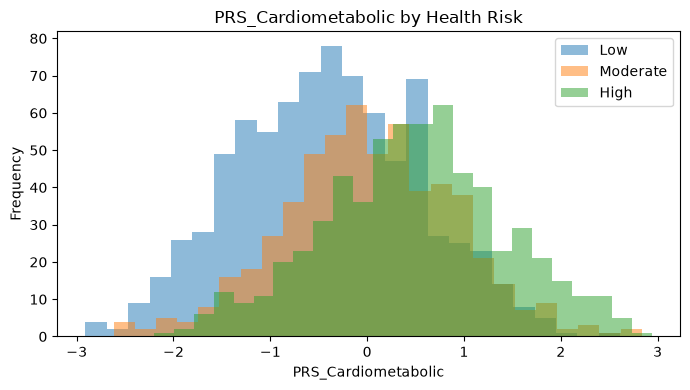

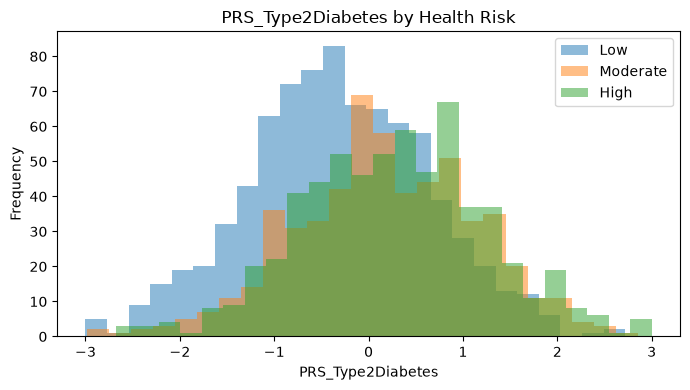

In [58]:
import matplotlib.pyplot as plt

for col in [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes'
]:

    plt.figure(figsize=(7, 4))

    for risk in ['Low', 'Moderate', 'High']:
        plt.hist(
            df_ml.loc[
                df_ml['Health_Risk'] == risk,
                col
            ],
            bins=25,
            alpha=0.5,
            label=risk
        )

    plt.title(f'{col} by Health Risk')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [59]:
# Predicted probabilities
probabilities = genetic_model.predict_proba(Xg_test)

probability_df = pd.DataFrame(
    probabilities,
    columns=genetic_model.named_steps[
        'classifier'
    ].classes_
)

display(probability_df.head(10).round(4))

,High,Low,Moderate
0,0.0000,1.0000,0.0000
1,0.3311,0.0005,0.6684
2,0.9985,0.0000,0.0015
3,0.0000,0.9996,0.0004
4,0.3595,0.0134,0.6271
5,1.0000,0.0000,0.0000
6,0.0000,0.9923,0.0077
7,0.0000,0.9978,0.0022
8,0.0000,1.0000,0.0000
9,0.0000,0.9771,0.0229


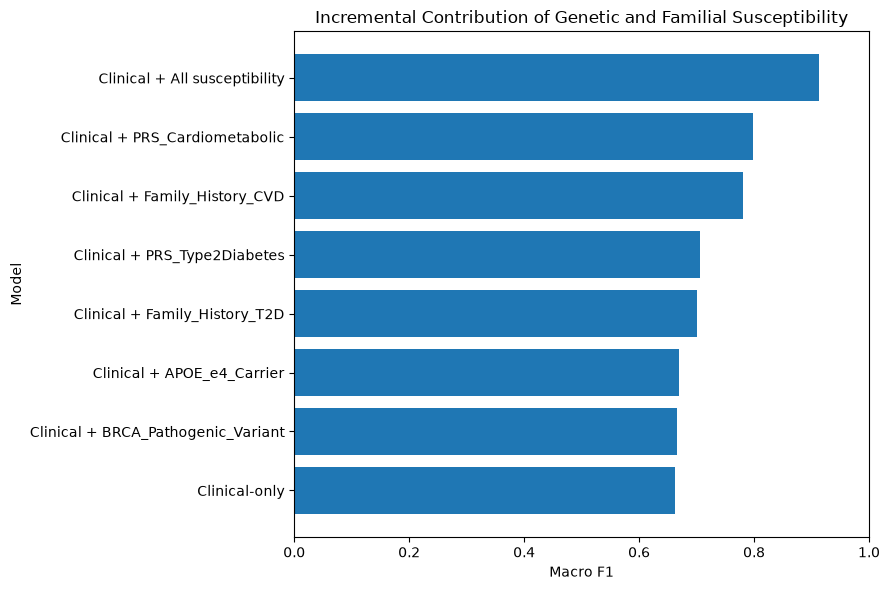

In [60]:
import matplotlib.pyplot as plt

plot_df = ablation_df.sort_values(
    'Macro_F1',
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df['Model'],
    plot_df['Macro_F1']
)

plt.xlabel('Macro F1')
plt.ylabel('Model')
plt.title('Incremental Contribution of Genetic and Familial Susceptibility')

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

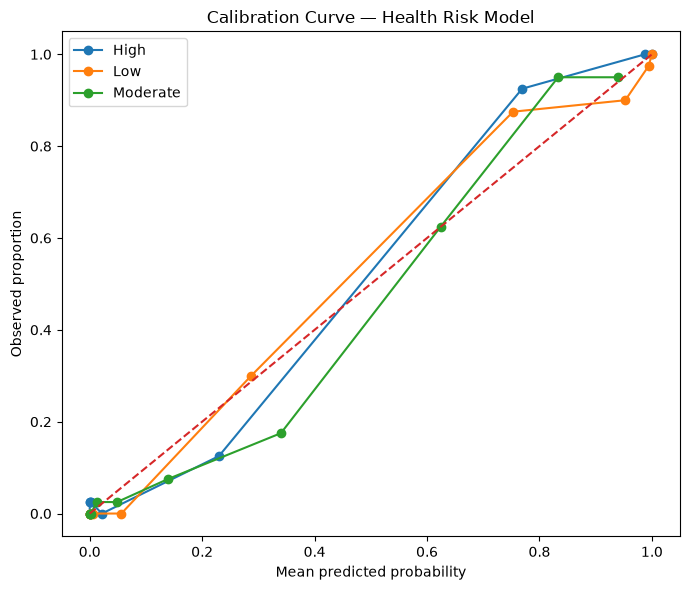

In [61]:
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

classes = genetic_model.named_steps[
    'classifier'
].classes_

probabilities = genetic_model.predict_proba(Xg_test)

plt.figure(figsize=(7, 6))

for i, class_name in enumerate(classes):

    y_binary = (yg_test == class_name).astype(int)

    fraction_pos, mean_pred = calibration_curve(
        y_binary,
        probabilities[:, i],
        n_bins=10,
        strategy='quantile'
    )

    plt.plot(
        mean_pred,
        fraction_pos,
        marker='o',
        label=class_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('Mean predicted probability')
plt.ylabel('Observed proportion')
plt.title('Calibration Curve — Health Risk Model')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
from sklearn.metrics import brier_score_loss

brier_results = []

for i, class_name in enumerate(classes):

    y_binary = (yg_test == class_name).astype(int)

    score = brier_score_loss(
        y_binary,
        probabilities[:, i]
    )

    brier_results.append({
        'Class': class_name,
        'Brier_Score': score
    })

brier_df = pd.DataFrame(brier_results)

display(brier_df.round(4))

,Class,Brier_Score
0,High,0.0269
1,Low,0.0446
2,Moderate,0.0672


In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(
    yg_test,
    classes=classes
)

auc_macro = roc_auc_score(
    y_test_bin,
    probabilities,
    multi_class='ovr',
    average='macro'
)

auc_weighted = roc_auc_score(
    y_test_bin,
    probabilities,
    multi_class='ovr',
    average='weighted'
)

print("Macro ROC-AUC:", round(auc_macro, 4))
print("Weighted ROC-AUC:", round(auc_weighted, 4))

Macro ROC-AUC: 0.9782
Weighted ROC-AUC: 0.9794


In [64]:
import numpy as np

classifier = genetic_model.named_steps['classifier']

feature_names = (
    genetic_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

for i, class_name in enumerate(classes):

    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': classifier.coef_[i]
    })

    coef_df['Odds_Ratio'] = np.exp(
        coef_df['Coefficient']
    )

    coef_df['Abs_Coefficient'] = (
        coef_df['Coefficient'].abs()
    )

    coef_df = coef_df.sort_values(
        'Abs_Coefficient',
        ascending=False
    )

    print("\n" + "="*70)
    print(f"Top predictors — {class_name}")
    print("="*70)

    display(
        coef_df.head(15).round(4)
    )


Top predictors — High


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,num__Age,3.7130,40.9782,3.7130
20,num__LDL,3.0183,20.4574,3.0183
5,num__PRS_Cardiometabolic,2.7689,15.9411,2.7689
21,num__HDL,-2.6269,0.0723,2.6269
9,num__Family_History_CVD,2.1487,8.5733,2.1487
30,cat__Smoking_Status_Non-smoker,-1.6041,0.2011,1.6041
2,num__Cholesterol,1.5092,4.5231,1.5092
28,cat__Smoking_Status_Current smoker,1.4671,4.3365,1.4671
18,num__Systolic_BP,1.3580,3.8883,1.3580
22,num__Triglycerides,-0.5615,0.5704,0.5615



Top predictors — Low


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,num__Age,-3.4704,0.0311,3.4704
20,num__LDL,-2.5848,0.0754,2.5848
5,num__PRS_Cardiometabolic,-2.4607,0.0854,2.4607
21,num__HDL,2.3070,10.0438,2.3070
9,num__Family_History_CVD,-1.9356,0.1443,1.9356
30,cat__Smoking_Status_Non-smoker,1.4744,4.3683,1.4744
28,cat__Smoking_Status_Current smoker,-1.4028,0.2459,1.4028
2,num__Cholesterol,-1.2862,0.2763,1.2862
18,num__Systolic_BP,-1.2663,0.2819,1.2663
6,num__PRS_Type2Diabetes,-0.5513,0.5762,0.5513



Top predictors — Moderate


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
20,num__LDL,-0.4335,0.6482,0.4335
21,num__HDL,0.3200,1.3771,0.3200
5,num__PRS_Cardiometabolic,-0.3083,0.7347,0.3083
0,num__Age,-0.2427,0.7845,0.2427
2,num__Cholesterol,-0.2230,0.8002,0.2230
9,num__Family_History_CVD,-0.2130,0.8081,0.2130
45,cat__Sleep_Quality_Excellent,-0.1998,0.8189,0.1998
1,num__BMI,0.1901,1.2094,0.1901
4,num__HbA1c,0.1403,1.1506,0.1403
35,cat__Physical_Activity_Level_Highly Active,0.1393,1.1495,0.1393


In [65]:
!pip install shap -q

In [66]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [67]:
# Fit final model first
genetic_model.fit(Xg_train, yg_train)

# Transform test data
Xg_test_transformed = (
    genetic_model
    .named_steps['preprocessor']
    .transform(Xg_test)
)

feature_names = (
    genetic_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

print(
    "Transformed shape:",
    Xg_test_transformed.shape
)

Transformed shape: (400, 49)


In [68]:
import shap

classifier = genetic_model.named_steps['classifier']

explainer = shap.LinearExplainer(
    classifier,
    Xg_test_transformed
)

shap_values = explainer(
    Xg_test_transformed
)

print("SHAP calculated successfully.")

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


SHAP calculated successfully.


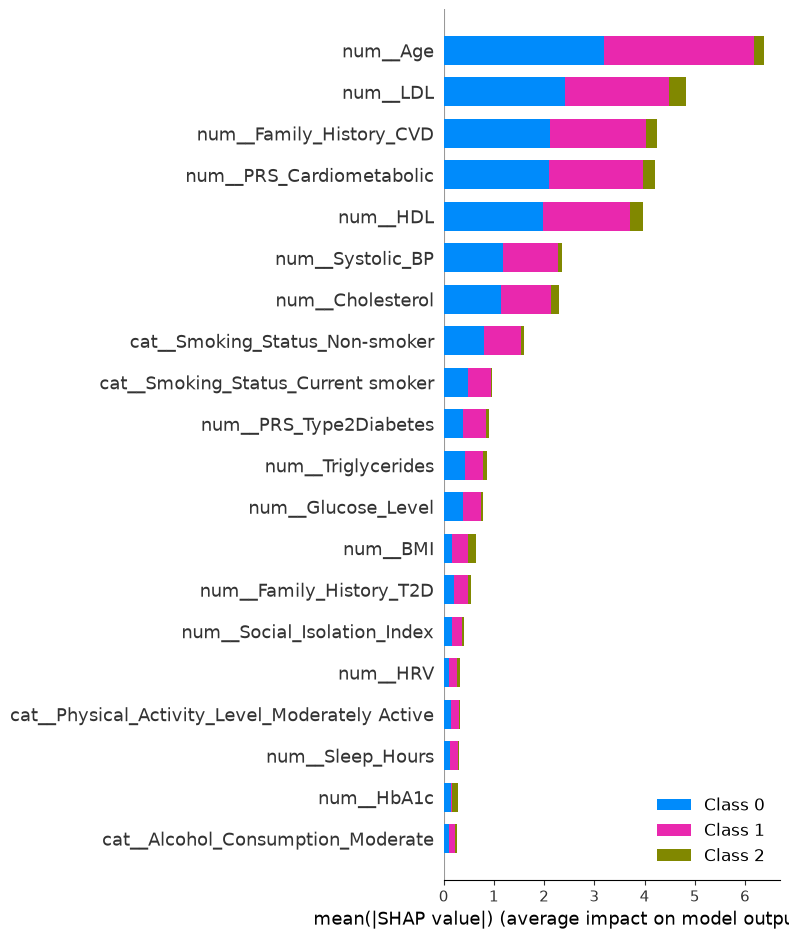

In [69]:
shap.summary_plot(
    shap_values.values,
    Xg_test_transformed,
    feature_names=feature_names,
    plot_type='bar'
)

In [70]:
print("SHAP values shape:")
print(shap_values.values.shape)

print("\nSHAP base values shape:")
print(np.array(shap_values.base_values).shape)

print("\nClasses:")
print(classes)

SHAP values shape:
(400, 49, 3)

SHAP base values shape:
(400, 3)

Classes:
['High' 'Low' 'Moderate']


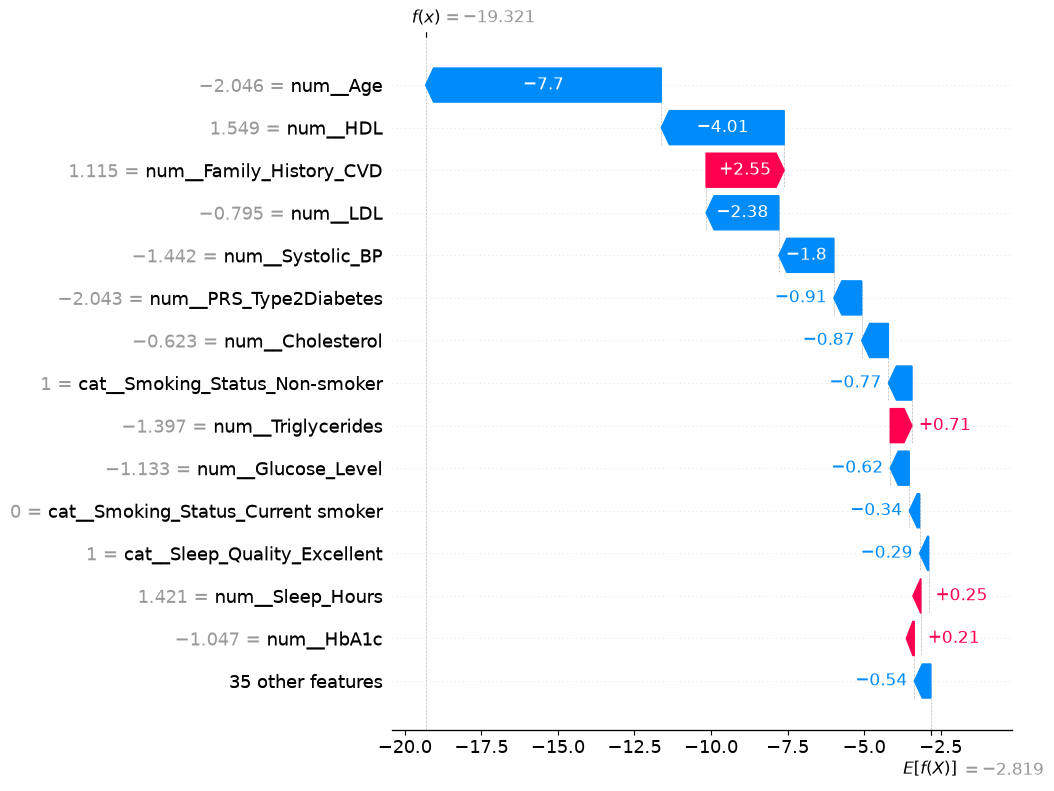

In [71]:
import numpy as np
import shap

# Select target class
target_class = 'High'

# Find class index
class_idx = list(classes).index(target_class)

# Select a patient
patient_index = 0

# Create a single-class SHAP Explanation
patient_high_shap = shap.Explanation(
    values=shap_values.values[
        patient_index, :, class_idx
    ],
    
    base_values=shap_values.base_values[
        patient_index, class_idx
    ],
    
    data=Xg_test_transformed[
        patient_index
    ],
    
    feature_names=feature_names
)

# Plot
shap.plots.waterfall(
    patient_high_shap,
    max_display=15
)

In [72]:
target_class = 'High'
class_idx = list(classes).index(target_class)

# Find patients with high predicted probability
high_probabilities = probabilities[:, class_idx]

# Patient with highest High-risk probability
patient_index = np.argmax(
    high_probabilities
)

print("Selected patient index:", patient_index)

print(
    "True class:",
    yg_test.iloc[patient_index]
)

print("\nPredicted probabilities:")

for class_name, prob in zip(
    classes,
    probabilities[patient_index]
):
    print(
        f"{class_name}: {prob:.4f}"
    )

Selected patient index: 92
True class: High

Predicted probabilities:
High: 1.0000
Low: 0.0000
Moderate: 0.0000


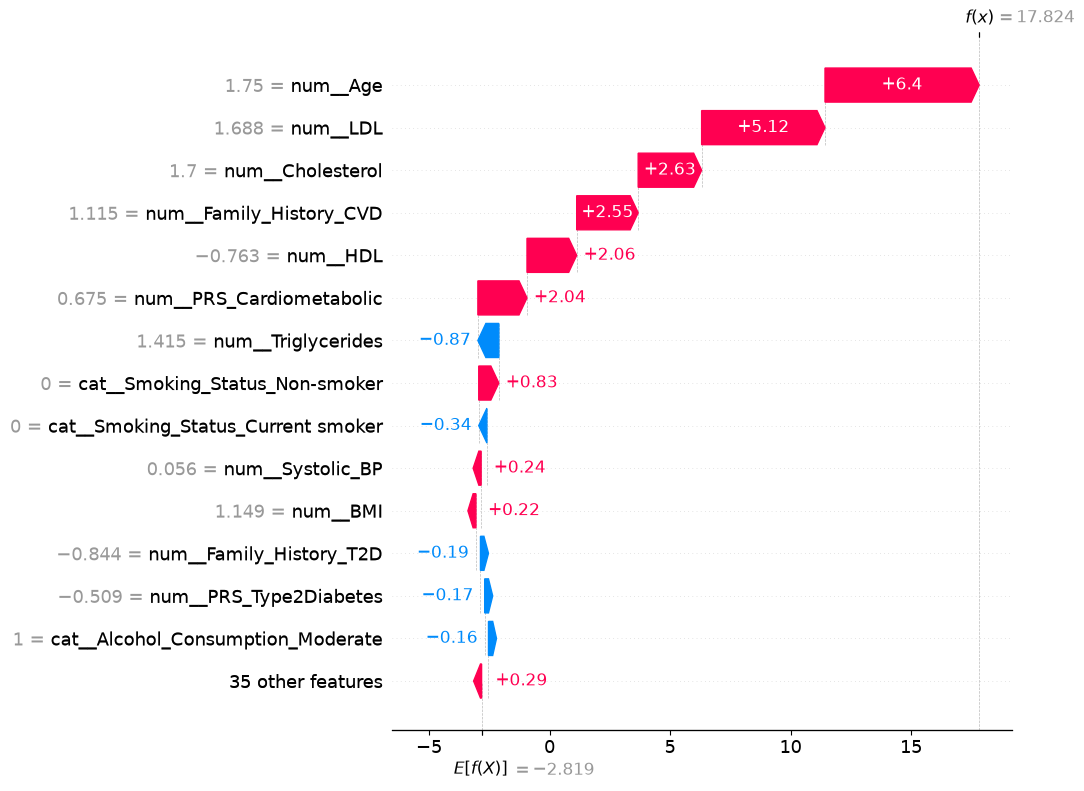

In [73]:
patient_high_shap = shap.Explanation(
    values=shap_values.values[
        patient_index, :, class_idx
    ],
    
    base_values=shap_values.base_values[
        patient_index, class_idx
    ],
    
    data=Xg_test_transformed[
        patient_index
    ],
    
    feature_names=feature_names
)

shap.plots.waterfall(
    patient_high_shap,
    max_display=15
)

In [74]:
def plot_patient_shap(
    patient_index,
    target_class,
    max_display=15
):
    
    class_idx = list(classes).index(
        target_class
    )
    
    patient_explanation = shap.Explanation(
        values=shap_values.values[
            patient_index,
            :,
            class_idx
        ],
        
        base_values=shap_values.base_values[
            patient_index,
            class_idx
        ],
        
        data=Xg_test_transformed[
            patient_index
        ],
        
        feature_names=feature_names
    )
    
    print(
        f"Patient index: {patient_index}"
    )
    
    print(
        f"Explaining class: {target_class}"
    )
    
    shap.plots.waterfall(
        patient_explanation,
        max_display=max_display
    )

Patient index: 2
Explaining class: High


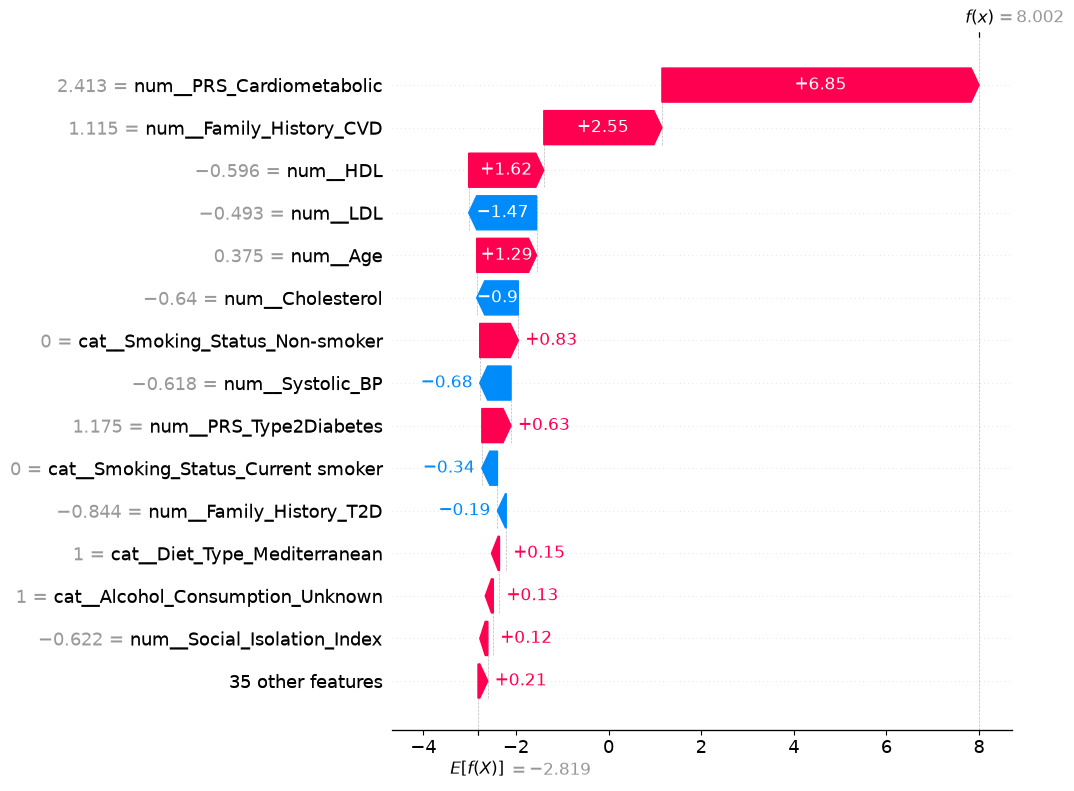

In [75]:
plot_patient_shap(
    patient_index=2,
    target_class='High'
)

In [76]:
patient_original = Xg_test.iloc[
    [patient_index]
].copy()

display(
    patient_original.T
)

,118
Age,76
Gender,Male
BMI,33.0
Smoking_Status,Former smoker
Alcohol_Consumption,Moderate
Physical_Activity_Level,Lightly Active
Diet_Type,Keto
Cholesterol,256.9
Glucose_Level,93.5
HbA1c,5.2


In [77]:
patient_probability = probabilities[
    patient_index
]

patient_prediction = genetic_model.predict(
    Xg_test.iloc[[patient_index]]
)[0]

patient_profile = pd.DataFrame({
    'Risk_Class': classes,
    'Probability': patient_probability
})

print("Predicted Health Risk:")
print(patient_prediction)

print("\nRisk probability:")
display(
    patient_profile.round(4)
)

Predicted Health Risk:
High

Risk probability:


,Risk_Class,Probability
0,High,1.0
1,Low,0.0
2,Moderate,0.0


In [78]:
class_idx = list(classes).index(
    patient_prediction
)

patient_values = shap_values.values[
    patient_index,
    :,
    class_idx
]

patient_contribution = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': patient_values,
    'Absolute_SHAP': np.abs(patient_values)
})

patient_contribution = patient_contribution.sort_values(
    'Absolute_SHAP',
    ascending=False
)

display(
    patient_contribution.head(15).round(4)
)

,Feature,SHAP_Value,Absolute_SHAP
0,num__Age,6.3956,6.3956
20,num__LDL,5.1178,5.1178
2,num__Cholesterol,2.6328,2.6328
9,num__Family_History_CVD,2.5505,2.5505
21,num__HDL,2.0619,2.0619
5,num__PRS_Cardiometabolic,2.0375,2.0375
22,num__Triglycerides,-0.8694,0.8694
30,cat__Smoking_Status_Non-smoker,0.8341,0.8341
28,cat__Smoking_Status_Current smoker,-0.3374,0.3374
18,num__Systolic_BP,0.2379,0.2379


In [79]:
positive = patient_contribution[
    patient_contribution['SHAP_Value'] > 0
].sort_values(
    'SHAP_Value',
    ascending=False
)

negative = patient_contribution[
    patient_contribution['SHAP_Value'] < 0
].sort_values(
    'SHAP_Value',
    ascending=True
)

print("TOP FACTORS PUSHING TOWARD",
      patient_prediction.upper())

display(
    positive.head(10).round(4)
)

print("\nTOP FACTORS PUSHING AWAY FROM",
      patient_prediction.upper())

display(
    negative.head(10).round(4)
)

TOP FACTORS PUSHING TOWARD HIGH


,Feature,SHAP_Value,Absolute_SHAP
0,num__Age,6.3956,6.3956
20,num__LDL,5.1178,5.1178
2,num__Cholesterol,2.6328,2.6328
9,num__Family_History_CVD,2.5505,2.5505
21,num__HDL,2.0619,2.0619
5,num__PRS_Cardiometabolic,2.0375,2.0375
30,cat__Smoking_Status_Non-smoker,0.8341,0.8341
18,num__Systolic_BP,0.2379,0.2379
1,num__BMI,0.2163,0.2163
14,num__Social_Isolation_Index,0.1182,0.1182



TOP FACTORS PUSHING AWAY FROM HIGH


,Feature,SHAP_Value,Absolute_SHAP
22,num__Triglycerides,-0.8694,0.8694
28,cat__Smoking_Status_Current smoker,-0.3374,0.3374
10,num__Family_History_T2D,-0.1891,0.1891
6,num__PRS_Type2Diabetes,-0.1747,0.1747
33,cat__Alcohol_Consumption_Moderate,-0.1577,0.1577
17,num__HRV,-0.1461,0.1461
12,num__Depression_Score,-0.1104,0.1104
41,cat__Diet_Type_Keto,-0.0759,0.0759
38,cat__Physical_Activity_Level_Sedentary,-0.0441,0.0441
15,num__Sleep_Hours,-0.0433,0.0433


In [80]:
non_modifiable = [
    'Age',
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant',
    'Family_History_CVD',
    'Family_History_T2D'
]

In [81]:
modifiable = [
    'BMI',
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'Glucose_Level',
    'HbA1c',
    'Stress_Level',
    'Social_Isolation_Index'
]

In [82]:
monitoring = [
    'eGFR',
    'CRP',
    'Resting_Heart_Rate',
    'HRV',
    'Cholesterol'
]

In [83]:
# Create contribution table
priority_df = patient_contribution.copy()

# Map transformed feature names back to original variables
priority_df['Original_Feature'] = (
    priority_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# Mark modifiability
priority_df['Modifiable'] = (
    priority_df['Original_Feature']
    .isin(modifiable)
)

# Intervention priority
priority_df['Intervention_Priority'] = (
    priority_df['Absolute_SHAP']
    * priority_df['Modifiable'].astype(int)
)

priority_df = priority_df.sort_values(
    'Intervention_Priority',
    ascending=False
)

display(
    priority_df.head(15).round(4)
)

,Feature,SHAP_Value,Absolute_SHAP,Original_Feature,Modifiable,Intervention_Priority
20,num__LDL,5.1178,5.1178,LDL,True,5.1178
21,num__HDL,2.0619,2.0619,HDL,True,2.0619
22,num__Triglycerides,-0.8694,0.8694,Triglycerides,True,0.8694
18,num__Systolic_BP,0.2379,0.2379,Systolic_BP,True,0.2379
1,num__BMI,0.2163,0.2163,BMI,True,0.2163
14,num__Social_Isolation_Index,0.1182,0.1182,Social_Isolation_Index,True,0.1182
19,num__Diastolic_BP,0.0723,0.0723,Diastolic_BP,True,0.0723
15,num__Sleep_Hours,-0.0433,0.0433,Sleep_Hours,True,0.0433
11,num__Stress_Level,0.0119,0.0119,Stress_Level,True,0.0119
3,num__Glucose_Level,0.0075,0.0075,Glucose_Level,True,0.0075


In [84]:
def generate_recommendations(patient):

    recommendations = []

    # BMI
    if patient['BMI'] >= 30:
        recommendations.append({
            'Priority': 'High',
            'Area': 'Weight management',
            'Recommendation':
                'Consider a structured weight-management '
                'approach emphasizing sustainable calorie control '
                'and increased physical activity.'
        })

    elif patient['BMI'] >= 25:
        recommendations.append({
            'Priority': 'Moderate',
            'Area': 'Weight management',
            'Recommendation':
                'Focus on maintaining or gradually reducing '
                'body weight through balanced diet and activity.'
        })

    # Smoking
    if patient['Smoking_Status'] == 'Current smoker':
        recommendations.append({
            'Priority': 'High',
            'Area': 'Smoking',
            'Recommendation':
                'Smoking cessation should be a major preventive priority.'
        })

    # Physical activity
    if patient['Physical_Activity_Level'] == 'Sedentary':
        recommendations.append({
            'Priority': 'High',
            'Area': 'Physical activity',
            'Recommendation':
                'Gradually increase regular physical activity '
                'according to individual tolerance and health status.'
        })

    # Sleep
    if patient['Sleep_Hours'] < 6:
        recommendations.append({
            'Priority': 'Moderate',
            'Area': 'Sleep',
            'Recommendation':
                'Improve sleep duration and regularity.'
        })

    # LDL
    if patient['LDL'] >= 130:
        recommendations.append({
            'Priority': 'High',
            'Area': 'Lipid management',
            'Recommendation':
                'Prioritize heart-healthy dietary patterns and '
                'professional assessment of lipid-related risk.'
        })

    # Triglycerides
    if patient['Triglycerides'] >= 200:
        recommendations.append({
            'Priority': 'High',
            'Area': 'Triglycerides',
            'Recommendation':
                'Reduce excess refined carbohydrate intake and '
                'address other lifestyle contributors.'
        })

    # Blood pressure
    if patient['Systolic_BP'] >= 130:
        recommendations.append({
            'Priority': 'Moderate',
            'Area': 'Blood pressure',
            'Recommendation':
                'Prioritize blood-pressure-friendly lifestyle '
                'measures and appropriate monitoring.'
        })

    return pd.DataFrame(recommendations)

In [85]:
patient = Xg_test.iloc[
    patient_index
]

recommendation_df = generate_recommendations(
    patient
)

display(recommendation_df)

,Priority,Area,Recommendation
0,High,Weight management,Consider a structured weight-management approa...
1,High,Lipid management,Prioritize heart-healthy dietary patterns and ...
2,High,Triglycerides,Reduce excess refined carbohydrate intake and ...


In [86]:
# ==========================================
# STEP 44: Aggregate SHAP to original features
# ==========================================

import pandas as pd
import numpy as np

agg_shap = patient_contribution.copy()

def get_original_feature(feature):
    
    if feature.startswith('num__'):
        return feature.replace('num__', '')
    
    elif feature.startswith('cat__'):
        feature = feature.replace('cat__', '')
        
        # Match categorical variable names
        categorical_originals = [
            'Gender',
            'Smoking_Status',
            'Alcohol_Consumption',
            'Physical_Activity_Level',
            'Diet_Type',
            'Sleep_Quality'
        ]
        
        for original in categorical_originals:
            if feature.startswith(original + '_'):
                return original
        
        return feature
    
    return feature


agg_shap['Original_Feature'] = (
    agg_shap['Feature']
    .apply(get_original_feature)
)

# Aggregate SHAP contributions
agg_shap_final = (
    agg_shap
    .groupby('Original_Feature', as_index=False)
    .agg(
        SHAP_Value=('SHAP_Value', 'sum'),
        Absolute_SHAP=('Absolute_SHAP', 'sum')
    )
    .sort_values(
        'Absolute_SHAP',
        ascending=False
    )
)

display(
    agg_shap_final.head(20).round(4)
)

,Original_Feature,SHAP_Value,Absolute_SHAP
1,Age,6.3956,6.3956
18,LDL,5.1178,5.1178
7,Cholesterol,2.6328,2.6328
11,Family_History_CVD,2.5505,2.5505
15,HDL,2.0619,2.0619
19,PRS_Cardiometabolic,2.0375,2.0375
25,Smoking_Status,0.5916,1.2665
29,Triglycerides,-0.8694,0.8694
21,Physical_Activity_Level,0.1716,0.2646
28,Systolic_BP,0.2379,0.2379


In [87]:
# ==========================================
# STEP 45: Risk-driver classification
# ==========================================

agg_shap_final['Direction'] = np.where(
    agg_shap_final['SHAP_Value'] > 0,
    'Pushes toward predicted class',
    'Pushes away from predicted class'
)

display(
    agg_shap_final.head(15).round(4)
)

,Original_Feature,SHAP_Value,Absolute_SHAP,Direction
1,Age,6.3956,6.3956,Pushes toward predicted class
18,LDL,5.1178,5.1178,Pushes toward predicted class
7,Cholesterol,2.6328,2.6328,Pushes toward predicted class
11,Family_History_CVD,2.5505,2.5505,Pushes toward predicted class
15,HDL,2.0619,2.0619,Pushes toward predicted class
19,PRS_Cardiometabolic,2.0375,2.0375,Pushes toward predicted class
25,Smoking_Status,0.5916,1.2665,Pushes toward predicted class
29,Triglycerides,-0.8694,0.8694,Pushes away from predicted class
21,Physical_Activity_Level,0.1716,0.2646,Pushes toward predicted class
28,Systolic_BP,0.2379,0.2379,Pushes toward predicted class


In [88]:
# ==========================================
# STEP 46: Modifiability
# ==========================================

agg_shap_final['Modifiable'] = (
    agg_shap_final['Original_Feature']
    .isin(modifiable)
)

agg_shap_final['Category'] = np.select(
    [
        agg_shap_final['Original_Feature'].isin(
            non_modifiable
        ),
        
        agg_shap_final['Original_Feature'].isin(
            modifiable
        ),
        
        agg_shap_final['Original_Feature'].isin(
            monitoring
        )
    ],
    [
        'Non-modifiable',
        'Modifiable',
        'Monitoring'
    ],
    default='Other'
)

display(
    agg_shap_final.head(20).round(4)
)

,Original_Feature,SHAP_Value,Absolute_SHAP,Direction,Modifiable,Category
1,Age,6.3956,6.3956,Pushes toward predicted class,False,Non-modifiable
18,LDL,5.1178,5.1178,Pushes toward predicted class,True,Modifiable
7,Cholesterol,2.6328,2.6328,Pushes toward predicted class,False,Monitoring
11,Family_History_CVD,2.5505,2.5505,Pushes toward predicted class,False,Non-modifiable
15,HDL,2.0619,2.0619,Pushes toward predicted class,True,Modifiable
19,PRS_Cardiometabolic,2.0375,2.0375,Pushes toward predicted class,False,Non-modifiable
25,Smoking_Status,0.5916,1.2665,Pushes toward predicted class,True,Modifiable
29,Triglycerides,-0.8694,0.8694,Pushes away from predicted class,True,Modifiable
21,Physical_Activity_Level,0.1716,0.2646,Pushes toward predicted class,True,Modifiable
28,Systolic_BP,0.2379,0.2379,Pushes toward predicted class,True,Modifiable


In [89]:
# ==========================================
# STEP 48: Prototype abnormality scoring
# ==========================================

def abnormality_score(patient, feature):
    
    if feature == 'BMI':
        if patient['BMI'] >= 30:
            return 1.0
        elif patient['BMI'] >= 25:
            return 0.6
        return 0.0

    elif feature == 'LDL':
        if patient['LDL'] >= 160:
            return 1.0
        elif patient['LDL'] >= 130:
            return 0.7
        elif patient['LDL'] >= 100:
            return 0.3
        return 0.0

    elif feature == 'Triglycerides':
        if patient['Triglycerides'] >= 200:
            return 1.0
        elif patient['Triglycerides'] >= 150:
            return 0.6
        return 0.0

    elif feature == 'Systolic_BP':
        if patient['Systolic_BP'] >= 140:
            return 1.0
        elif patient['Systolic_BP'] >= 130:
            return 0.7
        return 0.0

    elif feature == 'Diastolic_BP':
        if patient['Diastolic_BP'] >= 90:
            return 1.0
        elif patient['Diastolic_BP'] >= 80:
            return 0.5
        return 0.0

    elif feature == 'Sleep_Hours':
        if patient['Sleep_Hours'] < 6:
            return 1.0
        elif patient['Sleep_Hours'] < 7:
            return 0.5
        return 0.0

    elif feature == 'Sleep_Quality':
        if patient['Sleep_Quality'] == 'Poor':
            return 1.0
        elif patient['Sleep_Quality'] == 'Fair':
            return 0.4
        return 0.0

    elif feature == 'Stress_Level':
        if patient['Stress_Level'] >= 8:
            return 1.0
        elif patient['Stress_Level'] >= 6:
            return 0.5
        return 0.0

    elif feature == 'Social_Isolation_Index':
        if patient['Social_Isolation_Index'] >= 8:
            return 1.0
        elif patient['Social_Isolation_Index'] >= 6:
            return 0.5
        return 0.0

    elif feature == 'Smoking_Status':
        if patient['Smoking_Status'] == 'Current smoker':
            return 1.0
        elif patient['Smoking_Status'] == 'Former smoker':
            return 0.3
        return 0.0

    elif feature == 'Physical_Activity_Level':
        if patient['Physical_Activity_Level'] == 'Sedentary':
            return 1.0
        elif patient['Physical_Activity_Level'] == 'Lightly Active':
            return 0.5
        return 0.0

    elif feature == 'Alcohol_Consumption':
        if patient['Alcohol_Consumption'] == 'High':
            return 1.0
        elif patient['Alcohol_Consumption'] == 'Moderate':
            return 0.3
        return 0.0

    return 0.0

In [90]:
# ==========================================
# STEP 49: Intervention priority
# ==========================================

patient_for_rules = Xg_test.iloc[patient_index]

agg_shap_final['Abnormality_Score'] = (
    agg_shap_final['Original_Feature']
    .apply(
        lambda x:
        abnormality_score(
            patient_for_rules,
            x
        )
    )
)

agg_shap_final['Intervention_Priority'] = (
    agg_shap_final['Absolute_SHAP']
    *
    agg_shap_final['Abnormality_Score']
    *
    agg_shap_final['Modifiable'].astype(int)
)

priority_table = (
    agg_shap_final
    .sort_values(
        'Intervention_Priority',
        ascending=False
    )
)

display(
    priority_table[
        [
            'Original_Feature',
            'SHAP_Value',
            'Absolute_SHAP',
            'Abnormality_Score',
            'Modifiable',
            'Intervention_Priority'
        ]
    ].head(15).round(4)
)

,Original_Feature,SHAP_Value,Absolute_SHAP,Abnormality_Score,Modifiable,Intervention_Priority
18,LDL,5.1178,5.1178,1.0,True,5.1178
29,Triglycerides,-0.8694,0.8694,1.0,True,0.8694
25,Smoking_Status,0.5916,1.2665,0.3,True,0.3799
4,BMI,0.2163,0.2163,1.0,True,0.2163
21,Physical_Activity_Level,0.1716,0.2646,0.5,True,0.1323
2,Alcohol_Consumption,-0.1904,0.1952,0.3,True,0.0586
24,Sleep_Quality,0.0424,0.1339,0.4,True,0.0536
9,Diastolic_BP,0.0723,0.0723,0.5,True,0.0361
23,Sleep_Hours,-0.0433,0.0433,0.5,True,0.0216
27,Stress_Level,0.0119,0.0119,0.5,True,0.0060


In [91]:
# ==========================================
# STEP 52: Recommendation knowledge base
# ==========================================

recommendation_rules = {

    'LDL': {
        'area': 'Lipid management',
        'recommendation':
            'Prioritize a heart-healthy dietary pattern, '
            'reduce saturated-fat-rich foods, and consider '
            'professional lipid-risk assessment.',
        'action_type': 'Lifestyle + monitoring'
    },

    'BMI': {
        'area': 'Weight management',
        'recommendation':
            'Adopt a sustainable weight-management strategy '
            'combining dietary improvement with regular physical activity.',
        'action_type': 'Lifestyle'
    },

    'Triglycerides': {
        'area': 'Triglyceride management',
        'recommendation':
            'Reduce excess refined carbohydrates and added sugars '
            'and improve overall dietary quality.',
        'action_type': 'Lifestyle + monitoring'
    },

    'Physical_Activity_Level': {
        'area': 'Physical activity',
        'recommendation':
            'Gradually increase regular physical activity and '
            'include appropriate aerobic and resistance exercise.',
        'action_type': 'Lifestyle'
    },

    'Sleep_Hours': {
        'area': 'Sleep',
        'recommendation':
            'Improve sleep duration and maintain a consistent sleep schedule.',
        'action_type': 'Lifestyle'
    },

    'Sleep_Quality': {
        'area': 'Sleep quality',
        'recommendation':
            'Improve sleep regularity and address factors contributing '
            'to poor or insufficient sleep.',
        'action_type': 'Lifestyle'
    },

    'Smoking_Status': {
        'area': 'Smoking',
        'recommendation':
            'Maintain smoking abstinence and avoid returning to smoking.',
        'action_type': 'Preventive'
    },

    'Stress_Level': {
        'area': 'Stress management',
        'recommendation':
            'Consider structured stress-management strategies '
            'and regular physical activity.',
        'action_type': 'Lifestyle'
    },

    'Social_Isolation_Index': {
        'area': 'Social wellbeing',
        'recommendation':
            'Strengthen supportive social connections and regular '
            'meaningful social activity.',
        'action_type': 'Lifestyle'
    }
}

In [92]:
# ==========================================
# STEP 53: Personalized recommendation engine
# ==========================================

def generate_personalized_recommendations(
    patient,
    priority_table,
    top_n=5
):

    recommendations = []

    for _, row in priority_table.iterrows():

        feature = row['Original_Feature']

        if feature not in recommendation_rules:
            continue

        # Only actionable features
        if not row['Modifiable']:
            continue

        # Require some abnormality
        if row['Abnormality_Score'] <= 0:
            continue

        rule = recommendation_rules[feature]

        recommendations.append({
            'Feature': feature,
            'Priority_Score':
                row['Intervention_Priority'],
            'SHAP_Contribution':
                row['SHAP_Value'],
            'Abnormality_Score':
                row['Abnormality_Score'],
            'Area':
                rule['area'],
            'Action_Type':
                rule['action_type'],
            'Recommendation':
                rule['recommendation']
        })

    result = pd.DataFrame(
        recommendations
    )

    if len(result) > 0:
        result = result.sort_values(
            'Priority_Score',
            ascending=False
        ).head(top_n)

    return result

In [93]:
# ==========================================
# STEP 54: Generate patient recommendations
# ==========================================

personalized_recommendations = (
    generate_personalized_recommendations(
        patient_for_rules,
        priority_table,
        top_n=5
    )
)

display(
    personalized_recommendations.round(4)
)

,Feature,Priority_Score,SHAP_Contribution,Abnormality_Score,Area,Action_Type,Recommendation
0,LDL,5.1178,5.1178,1.0,Lipid management,Lifestyle + monitoring,"Prioritize a heart-healthy dietary pattern, re..."
1,Triglycerides,0.8694,-0.8694,1.0,Triglyceride management,Lifestyle + monitoring,Reduce excess refined carbohydrates and added ...
2,Smoking_Status,0.3799,0.5916,0.3,Smoking,Preventive,Maintain smoking abstinence and avoid returnin...
3,BMI,0.2163,0.2163,1.0,Weight management,Lifestyle,Adopt a sustainable weight-management strategy...
4,Physical_Activity_Level,0.1323,0.1716,0.5,Physical activity,Lifestyle,Gradually increase regular physical activity a...


In [94]:
# ==========================================
# STEP 56: Counterfactual simulation
# ==========================================

def predict_patient_scenario(
    model,
    patient,
    modifications
):

    scenario = patient.copy()

    for feature, value in modifications.items():
        scenario[feature] = value

    scenario_df = pd.DataFrame(
        [scenario]
    )

    prediction = model.predict(
        scenario_df
    )[0]

    probabilities = model.predict_proba(
        scenario_df
    )[0]

    probability_dict = {
        cls: round(prob, 4)
        for cls, prob
        in zip(classes, probabilities)
    }

    return prediction, probability_dict

In [95]:
baseline_prediction, baseline_probability = (
    predict_patient_scenario(
        genetic_model,
        patient_for_rules,
        {}
    )
)

print("BASELINE")
print("Prediction:", baseline_prediction)
print("Probability:", baseline_probability)

BASELINE
Prediction: High
Probability: {'High': np.float64(1.0), 'Low': np.float64(0.0), 'Moderate': np.float64(0.0)}


In [96]:
scenario_1 = {
    'BMI': 27,
    'LDL': 110,
    'Triglycerides': 150,
    'Physical_Activity_Level': 'Moderately Active'
}

prediction_1, probability_1 = (
    predict_patient_scenario(
        genetic_model,
        patient_for_rules,
        scenario_1
    )
)

print("SCENARIO 1")
print("Prediction:", prediction_1)
print("Probability:", probability_1)

SCENARIO 1
Prediction: High
Probability: {'High': np.float64(1.0), 'Low': np.float64(0.0), 'Moderate': np.float64(0.0)}


In [97]:
scenario_2 = {
    'LDL': 110
}

prediction_2, probability_2 = (
    predict_patient_scenario(
        genetic_model,
        patient_for_rules,
        scenario_2
    )
)

print("SCENARIO 2")
print("Prediction:", prediction_2)
print("Probability:", probability_2)

SCENARIO 2
Prediction: High
Probability: {'High': np.float64(1.0), 'Low': np.float64(0.0), 'Moderate': np.float64(0.0)}


In [98]:
# ==========================================
# STEP 60: Compare scenarios
# ==========================================

scenario_results = []

scenario_results.append({
    'Scenario': 'Current profile',
    'Prediction': baseline_prediction,
    **baseline_probability
})

scenario_results.append({
    'Scenario': 'LDL improvement',
    'Prediction': prediction_2,
    **probability_2
})

scenario_results.append({
    'Scenario': 'Lifestyle improvement',
    'Prediction': prediction_1,
    **probability_1
})

scenario_df = pd.DataFrame(
    scenario_results
)

display(
    scenario_df.round(4)
)

,Scenario,Prediction,High,Low,Moderate
0,Current profile,High,1.0,0.0,0.0
1,LDL improvement,High,1.0,0.0,0.0
2,Lifestyle improvement,High,1.0,0.0,0.0


In [99]:
# ==========================================
# STEP 61: Diagnose model probability saturation
# ==========================================

def inspect_scenario(model, patient, modifications, label):

    scenario = patient.copy()

    for feature, value in modifications.items():
        scenario[feature] = value

    scenario_df = pd.DataFrame([scenario])

    probabilities = model.predict_proba(scenario_df)[0]
    decision_scores = model.decision_function(scenario_df)[0]

    print("=" * 70)
    print(label)
    print("=" * 70)

    print("\nDecision scores:")
    for cls, score in zip(classes, decision_scores):
        print(f"{cls}: {score:.6f}")

    print("\nPredicted probabilities:")
    for cls, prob in zip(classes, probabilities):
        print(f"{cls}: {prob:.10f}")

    print("\nPrediction:")
    print(model.predict(scenario_df)[0])


# Baseline
inspect_scenario(
    genetic_model,
    patient_for_rules,
    {},
    "BASELINE"
)


# LDL improvement
inspect_scenario(
    genetic_model,
    patient_for_rules,
    {'LDL': 110},
    "LDL = 110"
)


# Stronger multi-factor improvement
inspect_scenario(
    genetic_model,
    patient_for_rules,
    {
        'BMI': 27,
        'LDL': 110,
        'Triglycerides': 150,
        'Physical_Activity_Level': 'Moderately Active'
    },
    "MULTI-FACTOR IMPROVEMENT"
)

BASELINE

Decision scores:
High: 17.823816
Low: -18.007227
Moderate: 0.183411

Predicted probabilities:
High: 0.9999999782
Low: 0.0000000000
Moderate: 0.0000000218

Prediction:
High
LDL = 110

Decision scores:
High: 12.053302
Low: -13.065537
Moderate: 1.012235

Predicted probabilities:
High: 0.9999839705
Low: 0.0000000000
Moderate: 0.0000160295

Prediction:
High
MULTI-FACTOR IMPROVEMENT

Decision scores:
High: 12.135225
Low: -12.814091
Moderate: 0.678866

Predicted probabilities:
High: 0.9999894181
Low: 0.0000000000
Moderate: 0.0000105819

Prediction:
High


In [100]:
# ==========================================
# STEP 62: Quantify counterfactual change
# ==========================================

def compare_scenarios(
    model,
    patient,
    scenarios
):

    results = []

    # Baseline
    baseline_df = pd.DataFrame([patient])

    baseline_prob = model.predict_proba(
        baseline_df
    )[0]

    baseline_score = model.decision_function(
        baseline_df
    )[0]

    for scenario_name, modifications in scenarios.items():

        scenario = patient.copy()

        for feature, value in modifications.items():
            scenario[feature] = value

        scenario_df = pd.DataFrame([scenario])

        prob = model.predict_proba(
            scenario_df
        )[0]

        score = model.decision_function(
            scenario_df
        )[0]

        row = {
            'Scenario': scenario_name,
            'Prediction': model.predict(
                scenario_df
            )[0]
        }

        for i, cls in enumerate(classes):

            row[f'{cls}_Probability'] = prob[i]

            row[f'{cls}_Probability_Change'] = (
                prob[i] - baseline_prob[i]
            )

            row[f'{cls}_Decision_Score'] = score[i]

            row[f'{cls}_Decision_Change'] = (
                score[i] - baseline_score[i]
            )

        results.append(row)

    return pd.DataFrame(results)


scenarios = {

    'Current profile': {},

    'LDL improvement': {
        'LDL': 110
    },

    'BMI improvement': {
        'BMI': 27
    },

    'Lipid improvement': {
        'LDL': 110,
        'Triglycerides': 150
    },

    'Lifestyle improvement': {
        'BMI': 27,
        'LDL': 110,
        'Triglycerides': 150,
        'Physical_Activity_Level':
            'Moderately Active'
    }
}


counterfactual_results = compare_scenarios(
    genetic_model,
    patient_for_rules,
    scenarios
)

display(
    counterfactual_results.round(6)
)

,Scenario,Prediction,High_Probability,High_Probability_Change,High_Decision_Score,High_Decision_Change,Low_Probability,Low_Probability_Change,Low_Decision_Score,Low_Decision_Change,Moderate_Probability,Moderate_Probability_Change,Moderate_Decision_Score,Moderate_Decision_Change
0,Current profile,High,1.000000,0.000000,17.823816,0.000000,0.0,0.0,-18.007227,0.000000,0.000000,0.000000,0.183411,0.000000
1,LDL improvement,High,0.999984,-0.000016,12.053302,-5.770515,0.0,0.0,-13.065537,4.941691,0.000016,0.000016,1.012235,0.828824
2,BMI improvement,High,1.000000,-0.000000,17.583880,-0.239936,0.0,0.0,-17.543505,0.463722,0.000000,0.000000,-0.040375,-0.223786
3,Lipid improvement,High,0.999993,-0.000006,12.834398,-4.989418,0.0,0.0,-13.726094,4.281133,0.000007,0.000006,0.891697,0.708285
4,Lifestyle improvement,High,0.999989,-0.000011,12.135225,-5.688591,0.0,0.0,-12.814091,5.193136,0.000011,0.000011,0.678866,0.495455


In [101]:
# ==========================================
# STEP 63: LDL sensitivity analysis
# ==========================================

ldl_values = [
    170,
    160,
    150,
    140,
    130,
    120,
    110,
    100,
    90
]

ldl_results = []

for ldl in ldl_values:

    scenario = patient_for_rules.copy()
    scenario['LDL'] = ldl

    scenario_df = pd.DataFrame(
        [scenario]
    )

    probabilities = genetic_model.predict_proba(
        scenario_df
    )[0]

    prediction = genetic_model.predict(
        scenario_df
    )[0]

    decision_scores = genetic_model.decision_function(
        scenario_df
    )[0]

    row = {
        'LDL': ldl,
        'Prediction': prediction
    }

    for cls, prob in zip(classes, probabilities):
        row[f'{cls}_Probability'] = prob

    for cls, score in zip(classes, decision_scores):
        row[f'{cls}_Decision_Score'] = score

    ldl_results.append(row)


ldl_sensitivity_df = pd.DataFrame(
    ldl_results
)

display(
    ldl_sensitivity_df.round(6)
)

,LDL,Prediction,High_Probability,Low_Probability,Moderate_Probability,High_Decision_Score,Low_Decision_Score,Moderate_Decision_Score
0,170,High,1.000000,0.0,0.000000,17.931585,-18.099517,0.167932
1,160,High,1.000000,0.0,0.000000,16.951871,-17.260520,0.308649
2,150,High,1.000000,0.0,0.000000,15.972157,-16.421524,0.449366
3,140,High,0.999999,0.0,0.000001,14.992443,-15.582527,0.590084
4,130,High,0.999998,0.0,0.000002,14.012729,-14.743530,0.730801
5,120,High,0.999995,0.0,0.000005,13.033015,-13.904533,0.871518
6,110,High,0.999984,0.0,0.000016,12.053302,-13.065537,1.012235
7,100,High,0.999951,0.0,0.000049,11.073588,-12.226540,1.152952
8,90,High,0.999849,0.0,0.000151,10.093874,-11.387543,1.293669


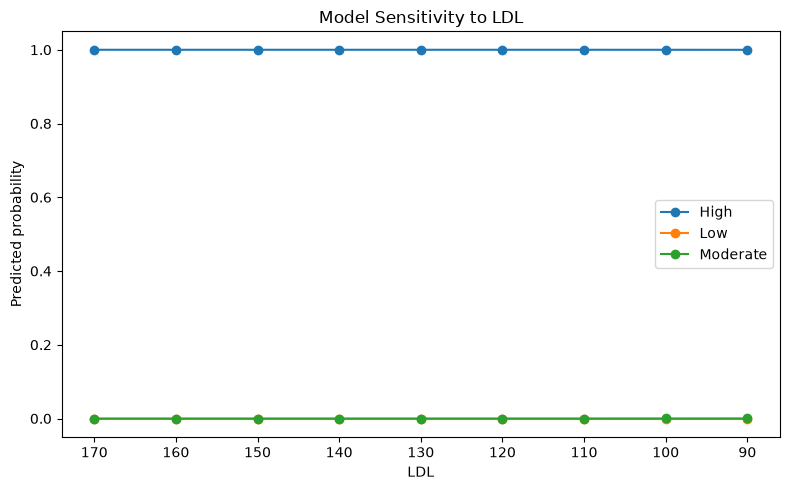

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for cls in classes:

    plt.plot(
        ldl_sensitivity_df['LDL'],
        ldl_sensitivity_df[f'{cls}_Probability'],
        marker='o',
        label=cls
    )

plt.xlabel('LDL')
plt.ylabel('Predicted probability')
plt.title('Model Sensitivity to LDL')
plt.legend()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

In [103]:
# ==========================================
# STEP 65: BMI sensitivity analysis
# ==========================================

bmi_values = [
    33,
    32,
    31,
    30,
    29,
    28,
    27,
    26,
    25,
    24
]

bmi_results = []

for bmi in bmi_values:

    scenario = patient_for_rules.copy()
    scenario['BMI'] = bmi

    scenario_df = pd.DataFrame(
        [scenario]
    )

    probabilities = genetic_model.predict_proba(
        scenario_df
    )[0]

    prediction = genetic_model.predict(
        scenario_df
    )[0]

    row = {
        'BMI': bmi,
        'Prediction': prediction
    }

    for cls, prob in zip(classes, probabilities):
        row[f'{cls}_Probability'] = prob

    bmi_results.append(row)


bmi_sensitivity_df = pd.DataFrame(
    bmi_results
)

display(
    bmi_sensitivity_df.round(6)
)

,BMI,Prediction,High_Probability,Low_Probability,Moderate_Probability
0,33,High,1.0,0.0,0.0
1,32,High,1.0,0.0,0.0
2,31,High,1.0,0.0,0.0
3,30,High,1.0,0.0,0.0
4,29,High,1.0,0.0,0.0
5,28,High,1.0,0.0,0.0
6,27,High,1.0,0.0,0.0
7,26,High,1.0,0.0,0.0
8,25,High,1.0,0.0,0.0
9,24,High,1.0,0.0,0.0


In [104]:
# ==========================================
# STEP 66: Progressive intervention scenarios
# ==========================================

progressive_scenarios = {

    'Baseline': {},

    'LDL improvement': {
        'LDL': 130
    },

    'LDL + TG improvement': {
        'LDL': 130,
        'Triglycerides': 150
    },

    'Lipid + BMI improvement': {
        'LDL': 130,
        'Triglycerides': 150,
        'BMI': 27
    },

    'Comprehensive lifestyle scenario': {
        'LDL': 110,
        'Triglycerides': 150,
        'BMI': 27,
        'Physical_Activity_Level':
            'Moderately Active'
    }
}


progressive_results = compare_scenarios(
    genetic_model,
    patient_for_rules,
    progressive_scenarios
)

display(
    progressive_results.round(6)
)

,Scenario,Prediction,High_Probability,High_Probability_Change,High_Decision_Score,High_Decision_Change,Low_Probability,Low_Probability_Change,Low_Decision_Score,Low_Decision_Change,Moderate_Probability,Moderate_Probability_Change,Moderate_Decision_Score,Moderate_Decision_Change
0,Baseline,High,1.000000,0.000000,17.823816,0.000000,0.0,0.0,-18.007227,0.000000,0.000000,0.000000,0.183411,0.000000
1,LDL improvement,High,0.999998,-0.000002,14.012729,-3.811087,0.0,0.0,-14.743530,3.263697,0.000002,0.000002,0.730801,0.547390
2,LDL + TG improvement,High,0.999999,-0.000001,14.793826,-3.029991,0.0,0.0,-15.404088,2.603140,0.000001,0.000001,0.610262,0.426851
3,Lipid + BMI improvement,High,0.999999,-0.000001,14.553889,-3.269927,0.0,0.0,-14.940366,3.066862,0.000001,0.000001,0.386476,0.203065
4,Comprehensive lifestyle scenario,High,0.999989,-0.000011,12.135225,-5.688591,0.0,0.0,-12.814091,5.193136,0.000011,0.000011,0.678866,0.495455


In [110]:
# ==========================================
# STEP 68: Counterfactual interpretation
# ==========================================

def interpret_counterfactual(
    baseline_probability,
    scenario_probability,
    baseline_prediction,
    scenario_prediction
):

    high_change = (
        scenario_probability['High']
        -
        baseline_probability['High']
    )

    if high_change < -0.01:

        interpretation = (
            "The hypothetical scenario produced a "
            "lower model-predicted probability of the "
            "High-risk class."
        )

    elif high_change > 0.01:

        interpretation = (
            "The hypothetical scenario produced a "
            "higher model-predicted probability of the "
            "High-risk class."
        )

    else:

        interpretation = (
            "The hypothetical scenario produced little "
            "change in the model-predicted High-risk probability."
        )

    return interpretation

In [111]:
# ==========================================
# STEP 68: Counterfactual interpretation
# ==========================================

def interpret_counterfactual(
    baseline_probability,
    scenario_probability,
    baseline_prediction,
    scenario_prediction
):

    high_change = (
        scenario_probability['High']
        -
        baseline_probability['High']
    )

    if high_change < -0.01:

        interpretation = (
            "The hypothetical scenario produced a "
            "lower model-predicted probability of the "
            "High-risk class."
        )

    elif high_change > 0.01:

        interpretation = (
            "The hypothetical scenario produced a "
            "higher model-predicted probability of the "
            "High-risk class."
        )

    else:

        interpretation = (
            "The hypothetical scenario produced little "
            "change in the model-predicted High-risk probability."
        )

    return interpretation

In [112]:
# ==========================================
# STEP 67: Target leakage / class separation check
# ==========================================

print("=" * 70)
print("TARGET LEAKAGE / CLASS SEPARATION CHECK")
print("=" * 70)

# 1. Numerical variables by target
for col in numeric_cols:

    print("\n" + "-" * 60)
    print(col)

    print(
        df_ml.groupby('Health_Risk')[col]
        .agg(['mean', 'std', 'min', 'max'])
        .round(3)
    )


# 2. Categorical variables by target
for col in categorical_cols:

    print("\n" + "-" * 60)
    print(col)

    print(
        pd.crosstab(
            df_ml[col],
            df_ml['Health_Risk'],
            normalize='columns'
        ).round(3)
    )

TARGET LEAKAGE / CLASS SEPARATION CHECK

------------------------------------------------------------
Age
               mean     std  min  max
Health_Risk                          
High         59.578  13.701   18   85
Low          40.017  13.018   18   85
Moderate     50.988  12.462   18   85

------------------------------------------------------------
BMI
               mean    std   min   max
Health_Risk                           
High         28.254  5.128  16.0  45.1
Low          25.854  4.755  16.0  42.2
Moderate     27.857  5.103  16.0  50.3

------------------------------------------------------------
Cholesterol
                mean     std    min    max
Health_Risk                               
High         212.586  32.894  100.6  328.4
Low          186.264  32.623   83.6  310.7
Moderate     195.990  33.211  103.3  279.7

------------------------------------------------------------
Glucose_Level
               mean     std   min    max
Health_Risk                          

In [113]:
# ==========================================
# STEP 68: Feature-target association
# ==========================================

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    df_ml['Health_Risk']
)

correlation_results = []

for col in numeric_cols:

    corr = df_ml[col].corr(
        pd.Series(
            y_encoded,
            index=df_ml.index
        )
    )

    correlation_results.append({
        'Feature': col,
        'Correlation_with_target': corr
    })


target_corr_df = pd.DataFrame(
    correlation_results
)

target_corr_df['Absolute_Correlation'] = (
    target_corr_df['Correlation_with_target']
    .abs()
)

target_corr_df = target_corr_df.sort_values(
    'Absolute_Correlation',
    ascending=False
)

display(
    target_corr_df.round(4)
)

,Feature,Correlation_with_target,Absolute_Correlation
20,LDL,-0.2707,0.2707
0,Age,-0.2283,0.2283
2,Cholesterol,-0.1921,0.1921
5,PRS_Cardiometabolic,-0.1887,0.1887
18,Systolic_BP,-0.1811,0.1811
9,Family_History_CVD,-0.1767,0.1767
24,eGFR,0.1693,0.1693
21,HDL,0.1328,0.1328
19,Diastolic_BP,-0.0934,0.0934
3,Glucose_Level,-0.0441,0.0441


In [114]:
# ==========================================
# STEP 70: Feature groups
# ==========================================

demographic_features = [
    'Age',
    'Gender'
]

lifestyle_features = [
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours'
]

anthropometric_features = [
    'BMI',
    'Waist_Circumference'
]

clinical_features = [
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Resting_Heart_Rate',
    'HRV'
]

psychological_features = [
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Social_Isolation_Index'
]

genetic_features = [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant'
]

family_history_features = [
    'Family_History_CVD',
    'Family_History_T2D'
]

In [115]:
# ==========================================
# STEP 72: Reusable model evaluation
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


def evaluate_feature_set(
    df,
    features,
    target='Health_Risk'
):

    X_subset = df[features].copy()
    y_subset = df[target].copy()

    categorical = X_subset.select_dtypes(
        include=['object', 'string']
    ).columns.tolist()

    numerical = X_subset.select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()

    num_pipe = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])

    cat_pipe = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ])

    prep = ColumnTransformer([
        (
            'num',
            num_pipe,
            numerical
        ),
        (
            'cat',
            cat_pipe,
            categorical
        )
    ])

    model = Pipeline([
        (
            'preprocessor',
            prep
        ),
        (
            'classifier',
            LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                random_state=42
            )
        )
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        'accuracy': 'accuracy',
        'balanced_accuracy': 'balanced_accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    scores = cross_validate(
        model,
        X_subset,
        y_subset,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        'Accuracy': scores[
            'test_accuracy'
        ].mean(),

        'Balanced_Accuracy': scores[
            'test_balanced_accuracy'
        ].mean(),

        'Macro_Precision': scores[
            'test_precision_macro'
        ].mean(),

        'Macro_Recall': scores[
            'test_recall_macro'
        ].mean(),

        'Macro_F1': scores[
            'test_f1_macro'
        ].mean()
    }

In [116]:
# ==========================================
# STEP 73: Incremental model comparison
# ==========================================

model_features = {

    'A_Demographic':
        demographic_features,

    'B_Demographic_Lifestyle':
        demographic_features
        + lifestyle_features,

    'C_Clinical':
        demographic_features
        + lifestyle_features
        + anthropometric_features
        + clinical_features,

    'D_Clinical_Psychological':
        demographic_features
        + lifestyle_features
        + anthropometric_features
        + clinical_features
        + psychological_features,

    'E_Clinical_Genetic':
        demographic_features
        + lifestyle_features
        + anthropometric_features
        + clinical_features
        + genetic_features,

    'F_Clinical_FamilyHistory':
        demographic_features
        + lifestyle_features
        + anthropometric_features
        + clinical_features
        + family_history_features,

    'G_Full_Model':
        demographic_features
        + lifestyle_features
        + anthropometric_features
        + clinical_features
        + psychological_features
        + genetic_features
        + family_history_features
}


incremental_results = []

for model_name, features in model_features.items():

    print(
        f"Evaluating {model_name} "
        f"({len(features)} features)..."
    )

    result = evaluate_feature_set(
        df_ml,
        features
    )

    result['Model'] = model_name
    result['N_Features'] = len(features)

    incremental_results.append(result)


incremental_df = pd.DataFrame(
    incremental_results
)

incremental_df = incremental_df[
    [
        'Model',
        'N_Features',
        'Accuracy',
        'Balanced_Accuracy',
        'Macro_Precision',
        'Macro_Recall',
        'Macro_F1'
    ]
]

display(
    incremental_df.round(4)
)

Evaluating A_Demographic (2 features)...
Evaluating B_Demographic_Lifestyle (8 features)...
Evaluating C_Clinical (22 features)...
Evaluating D_Clinical_Psychological (26 features)...
Evaluating E_Clinical_Genetic (26 features)...
Evaluating F_Clinical_FamilyHistory (24 features)...
Evaluating G_Full_Model (32 features)...


,Model,N_Features,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,A_Demographic,2,0.5475,0.5319,0.5262,0.5319,0.5274
1,B_Demographic_Lifestyle,8,0.5550,0.5393,0.5322,0.5393,0.5342
2,C_Clinical,22,0.6810,0.6695,0.6745,0.6695,0.6707
3,D_Clinical_Psychological,26,0.6735,0.6617,0.6669,0.6617,0.6627
4,E_Clinical_Genetic,26,0.8015,0.7955,0.7962,0.7955,0.7946
5,F_Clinical_FamilyHistory,24,0.7795,0.7733,0.7763,0.7733,0.7731
6,G_Full_Model,32,0.8930,0.8909,0.8896,0.8909,0.8898


In [117]:
print("Health_Risk unique values:")
print(df_ml["Health_Risk"].unique())

print("\nTarget counts:")
print(df_ml["Health_Risk"].value_counts())

print("\nPotential target-related columns:")
for col in df_ml.columns:
    if "risk" in col.lower() or "prediction" in col.lower():
        print(col)

Health_Risk unique values:
<ArrowStringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str

Target counts:
Health_Risk
Low         809
High        623
Moderate    568
Name: count, dtype: int64

Potential target-related columns:
Health_Risk


In [118]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

base_logistic = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

calibrated_model = CalibratedClassifierCV(
    estimator=base_logistic,
    method='sigmoid',
    cv=5
)

calibrated_model.fit(X_train, y_train)

print("Calibrated model trained successfully.")

Calibrated model trained successfully.


In [119]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
    brier_score_loss
)
import numpy as np

y_pred_cal = calibrated_model.predict(X_test)
y_prob_cal = calibrated_model.predict_proba(X_test)

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_cal), 4))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test, y_pred_cal), 4))

print("Macro F1:",
      round(f1_score(y_test, y_pred_cal, average='macro'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cal))

print("\nMacro ROC-AUC:",
      round(
          roc_auc_score(
              y_test,
              y_prob_cal,
              multi_class='ovr',
              average='macro'
          ),
          4
      ))

Accuracy: 0.8975
Balanced Accuracy: 0.8799
Macro F1: 0.8836

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.98      0.92       125
         Low       0.88      1.00      0.94       162
    Moderate       0.99      0.66      0.79       113

    accuracy                           0.90       400
   macro avg       0.91      0.88      0.88       400
weighted avg       0.91      0.90      0.89       400


Macro ROC-AUC: 0.9808


In [120]:
non_modifiable = [
    'Age',
    'Gender',
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'Family_History_CVD',
    'Family_History_T2D'
]

In [121]:
modifiable = [
    'BMI',
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Stress_Level',
    'Sleep_Hours',
    'Sleep_Quality',
    'LDL',
    'HDL',
    'Triglycerides',
    'Systolic_BP',
    'Diastolic_BP',
    'Glucose_Level',
    'HbA1c'
]

In [122]:
df_test = X_test.copy()
df_test["Actual"] = y_test.values
df_test["Predicted"] = y_pred_cal

df_test["Age_Group"] = pd.cut(
    df_test["Age"],
    bins=[17, 39, 59, 100],
    labels=["Young", "Middle", "Older"]
)

for group in ["Gender", "Age_Group", "Smoking_Status"]:
    print("\n", "="*60)
    print(group)

    for level, sub in df_test.groupby(group, observed=True):

        if len(sub) < 20:
            continue

        print(
            level,
            "n =", len(sub),
            "accuracy =",
            round(
                accuracy_score(
                    sub["Actual"],
                    sub["Predicted"]
                ),
                3
            )
        )


Gender
Female n = 194 accuracy = 0.887
Male n = 206 accuracy = 0.908

Age_Group
Young n = 113 accuracy = 0.938
Middle n = 188 accuracy = 0.883
Older n = 99 accuracy = 0.879

Smoking_Status
Current smoker n = 72 accuracy = 0.903
Former smoker n = 101 accuracy = 0.881
Non-smoker n = 227 accuracy = 0.903


In [123]:
print("Health_Risk unique values:")
print(df_ml["Health_Risk"].unique())

print("\nTarget counts:")
print(df_ml["Health_Risk"].value_counts())

print("\nPotential target-related columns:")
for col in df_ml.columns:
    if "risk" in col.lower() or "prediction" in col.lower():
        print(col)

Health_Risk unique values:
<ArrowStringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str

Target counts:
Health_Risk
Low         809
High        623
Moderate    568
Name: count, dtype: int64

Potential target-related columns:
Health_Risk


In [124]:
# ============================================================
# STEP 75: Final ML Dataset Preparation
# ============================================================

df_final = df_ml.copy()

# ------------------------------------------------------------
# 1. Remove variables that should not enter prediction
# ------------------------------------------------------------

drop_for_model = [
    'Health_Risk',              # target
]

# Patient_ID and Blood_Pressure were already removed earlier.
# Diet/Exercise recommendations are also absent from df_ml.

print("Current columns:", len(df_final.columns))

# ------------------------------------------------------------
# 2. Treat missing alcohol consumption explicitly
# ------------------------------------------------------------

df_final['Alcohol_Consumption'] = (
    df_final['Alcohol_Consumption']
    .fillna('Unknown')
)

# ------------------------------------------------------------
# 3. Define target
# ------------------------------------------------------------

y_final = df_final['Health_Risk'].copy()

# ------------------------------------------------------------
# 4. Define predictors
# ------------------------------------------------------------

X_final = df_final.drop(columns=['Health_Risk'])

# ------------------------------------------------------------
# 5. Remove any accidental ID / recommendation variables
# ------------------------------------------------------------

columns_to_remove = [
    'Patient_ID',
    'Diet_Recommendation',
    'Exercise_Recommendation',
    'Alcohol_Consumption_Clean',
    'Alcohol_Missing'
]

columns_to_remove = [
    col for col in columns_to_remove
    if col in X_final.columns
]

X_final = X_final.drop(columns=columns_to_remove)

print("\nFinal X shape:", X_final.shape)
print("Final y shape:", y_final.shape)

print("\nTarget distribution:")
print(y_final.value_counts())

print("\nMissing values:")
print(X_final.isnull().sum().sort_values(ascending=False).head(10))

Current columns: 35

Final X shape: (2000, 32)
Final y shape: (2000,)

Target distribution:
Health_Risk
Low         809
High        623
Moderate    568
Name: count, dtype: int64

Missing values:
Age                        0
Gender                     0
BMI                        0
Smoking_Status             0
Alcohol_Consumption        0
Physical_Activity_Level    0
Diet_Type                  0
Cholesterol                0
Glucose_Level              0
HbA1c                      0
dtype: int64


In [125]:
# ============================================================
# STEP 76: Final Feature Types
# ============================================================

categorical_cols_final = X_final.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

numeric_cols_final = X_final.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical variables:")
print(categorical_cols_final)

print("\nNumerical variables:")
print(numeric_cols_final)

print("\nNumber of categorical variables:",
      len(categorical_cols_final))

print("Number of numerical variables:",
      len(numeric_cols_final))

print("\nTotal predictors:",
      len(categorical_cols_final) + len(numeric_cols_final))

Categorical variables:
['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Sleep_Quality']

Numerical variables:
['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index', 'Sleep_Hours', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference']

Number of categorical variables: 6
Number of numerical variables: 26

Total predictors: 32


In [126]:
# ============================================================
# STEP 77: Final Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_final = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor_final = ColumnTransformer([
    ('num',
     numeric_transformer_final,
     numeric_cols_final),

    ('cat',
     categorical_transformer_final,
     categorical_cols_final)
])

print("Final preprocessing pipeline created.")

Final preprocessing pipeline created.


In [127]:
# ============================================================
# STEP 78: Final Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)

print("Training:", X_train_final.shape)
print("Testing :", X_test_final.shape)

print("\nTraining distribution:")
print(y_train_final.value_counts())

print("\nTesting distribution:")
print(y_test_final.value_counts())

Training: (1600, 32)
Testing : (400, 32)

Training distribution:
Health_Risk
Low         647
High        498
Moderate    455
Name: count, dtype: int64

Testing distribution:
Health_Risk
Low         162
High        125
Moderate    113
Name: count, dtype: int64


In [128]:
# ============================================================
# STEP 79: Final Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

final_logistic = Pipeline([
    ('preprocessor', preprocessor_final),

    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

final_logistic.fit(
    X_train_final,
    y_train_final
)

print("Final Logistic Regression trained successfully.")

Final Logistic Regression trained successfully.


In [129]:
# ============================================================
# STEP 80: 5-Fold Cross-Validation
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

cv_results = cross_validate(
    final_logistic,
    X_final,
    y_final,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1
)

cv_summary = {
    metric: cv_results[f'test_{metric}'].mean()
    for metric in cv_scoring
}

print("5-Fold Cross-Validation Results")
print("=" * 60)

for metric, value in cv_summary.items():
    print(f"{metric:25s}: {value:.4f}")

5-Fold Cross-Validation Results
accuracy                 : 0.8930
balanced_accuracy        : 0.8909
f1_macro                 : 0.8898
precision_macro          : 0.8896
recall_macro             : 0.8909


In [130]:
# ============================================================
# STEP 81: CV Mean ± SD
# ============================================================

for metric in cv_scoring:

    scores = cv_results[f'test_{metric}']

    print(
        f"{metric:25s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

accuracy                 : 0.8930 ± 0.0138
balanced_accuracy        : 0.8909 ± 0.0153
f1_macro                 : 0.8898 ± 0.0153
precision_macro          : 0.8896 ± 0.0158
recall_macro             : 0.8909 ± 0.0153


In [131]:
# ============================================================
# STEP 84: Final Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_final = calibrated_model.predict(X_test_final)
y_prob_final = calibrated_model.predict_proba(X_test_final)

print("=" * 70)
print("FINAL CALIBRATED MODEL")
print("=" * 70)

print(
    "Accuracy:",
    round(accuracy_score(y_test_final, y_pred_final), 4)
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test_final,
            y_pred_final
        ),
        4
    )
)

print(
    "Macro Precision:",
    round(
        precision_score(
            y_test_final,
            y_pred_final,
            average='macro'
        ),
        4
    )
)

print(
    "Macro Recall:",
    round(
        recall_score(
            y_test_final,
            y_pred_final,
            average='macro'
        ),
        4
    )
)

print(
    "Macro F1:",
    round(
        f1_score(
            y_test_final,
            y_pred_final,
            average='macro'
        ),
        4
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_final,
        y_pred_final,
        digits=4
    )
)

FINAL CALIBRATED MODEL
Accuracy: 0.8975
Balanced Accuracy: 0.8799
Macro Precision: 0.9129
Macro Recall: 0.8799
Macro F1: 0.8836

Classification Report:
              precision    recall  f1-score   support

        High     0.8714    0.9760    0.9208       125
         Low     0.8804    1.0000    0.9364       162
    Moderate     0.9868    0.6637    0.7937       113

    accuracy                         0.8975       400
   macro avg     0.9129    0.8799    0.8836       400
weighted avg     0.9077    0.8975    0.8912       400



In [132]:
# ============================================================
# STEP 85: Probability-Based Evaluation
# ============================================================

from sklearn.metrics import roc_auc_score, brier_score_loss

classes = calibrated_model.classes_

macro_auc = roc_auc_score(
    y_test_final,
    y_prob_final,
    multi_class='ovr',
    average='macro'
)

weighted_auc = roc_auc_score(
    y_test_final,
    y_prob_final,
    multi_class='ovr',
    average='weighted'
)

print("Macro ROC-AUC   :", round(macro_auc, 4))
print("Weighted ROC-AUC:", round(weighted_auc, 4))

print("\nBrier Scores:")

for i, cls in enumerate(classes):

    y_binary = (
        y_test_final == cls
    ).astype(int)

    brier = brier_score_loss(
        y_binary,
        y_prob_final[:, i]
    )

    print(
        f"{cls:10s}: {brier:.4f}"
    )

Macro ROC-AUC   : 0.9808
Weighted ROC-AUC: 0.9819

Brier Scores:
High      : 0.0487
Low       : 0.0637
Moderate  : 0.1123


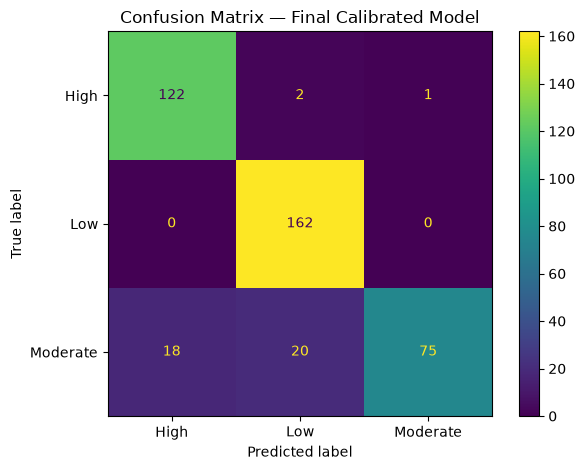

In [133]:
# ============================================================
# STEP 86: Final Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_final,
    display_labels=classes,
    values_format='d'
)

plt.title(
    "Confusion Matrix — Final Calibrated Model"
)

plt.tight_layout()
plt.show()

In [134]:
# ============================================================
# STEP 87: Patient-Level Explainable Risk Engine
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get fitted preprocessing and classifier
# ------------------------------------------------------------

fitted_preprocessor = (
    final_logistic.named_steps['preprocessor']
)

fitted_classifier = (
    final_logistic.named_steps['classifier']
)

# ------------------------------------------------------------
# 2. Get transformed feature names
# ------------------------------------------------------------

feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of transformed features:",
      len(feature_names))

print("\nFirst 20 transformed features:")
print(feature_names[:20])


# ------------------------------------------------------------
# 3. Patient explanation function
# ------------------------------------------------------------

def explain_patient(
    patient_index=0,
    top_n=15
):

    patient = X_test_final.iloc[[patient_index]]

    # Transform patient using fitted preprocessing
    patient_transformed = (
        fitted_preprocessor.transform(patient)
    )

    # Model prediction
    predicted_class = final_logistic.predict(
        patient
    )[0]

    # Calibrated probabilities
    probabilities = calibrated_model.predict_proba(
        patient
    )[0]

    probability_table = pd.DataFrame({
        'Risk_Class': calibrated_model.classes_,
        'Probability': probabilities
    })

    probability_table['Probability_%'] = (
        probability_table['Probability'] * 100
    ).round(2)

    probability_table = probability_table.sort_values(
        'Probability',
        ascending=False
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Logistic regression coefficients
    # --------------------------------------------------------

    coefficients = fitted_classifier.coef_

    classes = fitted_classifier.classes_

    # Find predicted class
    class_index = list(classes).index(
        predicted_class
    )

    # Contribution of each feature to predicted class score
    contributions = (
        patient_transformed[0]
        * coefficients[class_index]
    )

    contribution_df = pd.DataFrame({
        'Feature': feature_names,
        'Contribution': contributions
    })

    # Remove zero contributions
    contribution_df = contribution_df[
        contribution_df['Contribution'].abs() > 1e-10
    ]

    # --------------------------------------------------------
    # Add modifiability
    # --------------------------------------------------------

    def get_base_feature(feature):

        feature = feature.replace(
            'num__', ''
        ).replace(
            'cat__', ''
        )

        # One-hot feature:
        # Smoking_Status_Current smoker
        # → Smoking_Status
        for original_col in X_final.columns:

            if feature == original_col:
                return original_col

            if feature.startswith(
                original_col + '_'
            ):
                return original_col

        return feature

    contribution_df[
        'Base_Feature'
    ] = contribution_df['Feature'].apply(
        get_base_feature
    )

    contribution_df['Modifiable'] = (
        contribution_df['Base_Feature']
        .isin(modifiable)
    )

    contribution_df['Direction'] = np.where(
        contribution_df['Contribution'] > 0,
        'Increases predicted risk',
        'Decreases predicted risk'
    )

    # Strongest absolute contributions
    contribution_df['Absolute_Contribution'] = (
        contribution_df['Contribution'].abs()
    )

    contribution_df = contribution_df.sort_values(
        'Absolute_Contribution',
        ascending=False
    ).head(top_n)

    contribution_df[
        'Contribution'
    ] = contribution_df[
        'Contribution'
    ].round(4)

    contribution_df[
        'Absolute_Contribution'
    ] = contribution_df[
        'Absolute_Contribution'
    ].round(4)

    # --------------------------------------------------------
    # Patient information
    # --------------------------------------------------------

    patient_information = patient.iloc[0].to_dict()

    return {
        'patient_index': patient_index,
        'predicted_class': predicted_class,
        'probabilities': probability_table,
        'patient_information': patient_information,
        'top_contributors': contribution_df
    }


# ------------------------------------------------------------
# 4. Test with first patient
# ------------------------------------------------------------

patient_result = explain_patient(
    patient_index=0,
    top_n=15
)

print("=" * 70)
print("PATIENT-LEVEL RISK PROFILE")
print("=" * 70)

print(
    "\nPredicted risk:",
    patient_result['predicted_class']
)

print("\nRisk probabilities:")
display(
    patient_result['probabilities']
)

print("\nTop contributing factors:")
display(
    patient_result['top_contributors']
)

Number of transformed features: 49

First 20 transformed features:
['num__Age' 'num__BMI' 'num__Cholesterol' 'num__Glucose_Level'
 'num__HbA1c' 'num__PRS_Cardiometabolic' 'num__PRS_Type2Diabetes'
 'num__APOE_e4_Carrier' 'num__BRCA_Pathogenic_Variant'
 'num__Family_History_CVD' 'num__Family_History_T2D' 'num__Stress_Level'
 'num__Depression_Score' 'num__Anxiety_Score'
 'num__Social_Isolation_Index' 'num__Sleep_Hours'
 'num__Resting_Heart_Rate' 'num__HRV' 'num__Systolic_BP'
 'num__Diastolic_BP']
PATIENT-LEVEL RISK PROFILE

Predicted risk: Low

Risk probabilities:


,Risk_Class,Probability,Probability_%
0,Low,7.745950e-01,77.46
1,Moderate,2.254050e-01,22.54
2,High,8.891719e-09,0.00



Top contributing factors:


,Feature,Contribution,Base_Feature,Modifiable,Direction,Absolute_Contribution
0,num__Age,7.1011,Age,False,Increases predicted risk,7.1011
21,num__HDL,3.5731,HDL,True,Increases predicted risk,3.5731
9,num__Family_History_CVD,-2.1589,Family_History_CVD,False,Decreases predicted risk,2.1589
20,num__LDL,2.0543,LDL,True,Increases predicted risk,2.0543
18,num__Systolic_BP,1.8254,Systolic_BP,True,Increases predicted risk,1.8254
30,cat__Smoking_Status_Non-smoker,1.4744,Smoking_Status,True,Increases predicted risk,1.4744
6,num__PRS_Type2Diabetes,1.1265,PRS_Type2Diabetes,False,Increases predicted risk,1.1265
2,num__Cholesterol,0.8008,Cholesterol,False,Increases predicted risk,0.8008
22,num__Triglycerides,-0.6632,Triglycerides,True,Decreases predicted risk,0.6632
45,cat__Sleep_Quality_Excellent,0.5424,Sleep_Quality,True,Increases predicted risk,0.5424


In [135]:
# ============================================================
# STEP 88: Personalized Risk Profile
# ============================================================

def generate_patient_profile(
    patient_index=0,
    top_n=10
):

    result = explain_patient(
        patient_index=patient_index,
        top_n=top_n
    )

    patient = result['patient_information']
    probs = result['probabilities']
    contributors = result['top_contributors']

    print("\n")
    print("╔" + "═" * 68 + "╗")
    print("║" + " PERSONALIZED HEALTH RISK PROFILE".center(68) + "║")
    print("╚" + "═" * 68 + "╝")

    print(
        f"\nPatient index: {patient_index}"
    )

    print(
        f"Predicted Health Risk: "
        f"{result['predicted_class'].upper()}"
    )

    print("\n" + "-" * 70)
    print("RISK PROBABILITIES")
    print("-" * 70)

    for _, row in probs.iterrows():

        print(
            f"{row['Risk_Class']:10s} : "
            f"{row['Probability_%']:6.2f}%"
        )

    print("\n" + "-" * 70)
    print("TOP PREDICTIVE CONTRIBUTORS")
    print("-" * 70)

    for _, row in contributors.iterrows():

        mod_status = (
            "MODIFIABLE"
            if row['Modifiable']
            else "NON-MODIFIABLE"
        )

        print(
            f"{row['Base_Feature']:30s} | "
            f"{row['Direction']:25s} | "
            f"{mod_status}"
        )


generate_patient_profile(
    patient_index=0,
    top_n=10
)



╔════════════════════════════════════════════════════════════════════╗
║                  PERSONALIZED HEALTH RISK PROFILE                  ║
╚════════════════════════════════════════════════════════════════════╝

Patient index: 0
Predicted Health Risk: LOW

----------------------------------------------------------------------
RISK PROBABILITIES
----------------------------------------------------------------------
Low        :  77.46%
Moderate   :  22.54%
High       :   0.00%

----------------------------------------------------------------------
TOP PREDICTIVE CONTRIBUTORS
----------------------------------------------------------------------
Age                            | Increases predicted risk  | NON-MODIFIABLE
HDL                            | Increases predicted risk  | MODIFIABLE
Family_History_CVD             | Decreases predicted risk  | NON-MODIFIABLE
LDL                            | Increases predicted risk  | MODIFIABLE
Systolic_BP                    | Increases predi

In [136]:
# ============================================================
# STEP 89: Patient Clinical Snapshot
# ============================================================

def patient_snapshot(patient_index=0):

    patient = X_test_final.iloc[patient_index]

    snapshot_features = [
        'Age',
        'BMI',
        'Smoking_Status',
        'Alcohol_Consumption',
        'Physical_Activity_Level',
        'Diet_Type',
        'Cholesterol',
        'Glucose_Level',
        'HbA1c',
        'LDL',
        'HDL',
        'Triglycerides',
        'Systolic_BP',
        'Diastolic_BP',
        'Stress_Level',
        'Sleep_Hours',
        'Sleep_Quality',
        'PRS_Cardiometabolic',
        'PRS_Type2Diabetes',
        'Family_History_CVD',
        'Family_History_T2D'
    ]

    snapshot_features = [
        x for x in snapshot_features
        if x in patient.index
    ]

    snapshot = pd.DataFrame({
        'Feature': snapshot_features,
        'Patient_Value': [
            patient[x]
            for x in snapshot_features
        ],
        'Modifiable': [
            x in modifiable
            for x in snapshot_features
        ]
    })

    return snapshot


display(
    patient_snapshot(0)
)

,Feature,Patient_Value,Modifiable
0,Age,18,False
1,BMI,31.7,True
2,Smoking_Status,Non-smoker,True
3,Alcohol_Consumption,Moderate,True
4,Physical_Activity_Level,Lightly Active,True
5,Diet_Type,Balanced,True
6,Cholesterol,175.7,False
7,Glucose_Level,76.9,True
8,HbA1c,4.4,True
9,LDL,92.4,True


In [137]:
# ============================================================
# STEP 90: Modifiable vs Non-Modifiable Contributors
# ============================================================

def split_contributors(patient_index=0):

    result = explain_patient(
        patient_index=patient_index,
        top_n=20
    )

    contributors = result['top_contributors']

    modifiable_risk = contributors[
        (contributors['Modifiable'] == True) &
        (contributors['Contribution'] > 0)
    ].copy()

    nonmodifiable_risk = contributors[
        (contributors['Modifiable'] == False) &
        (contributors['Contribution'] > 0)
    ].copy()

    protective_factors = contributors[
        contributors['Contribution'] < 0
    ].copy()

    print("=" * 70)
    print("MODIFIABLE RISK CONTRIBUTORS")
    print("=" * 70)

    display(modifiable_risk)

    print("=" * 70)
    print("NON-MODIFIABLE RISK CONTRIBUTORS")
    print("=" * 70)

    display(nonmodifiable_risk)

    print("=" * 70)
    print("FACTORS REDUCING PREDICTED RISK")
    print("=" * 70)

    display(protective_factors)


split_contributors(0)

MODIFIABLE RISK CONTRIBUTORS


,Feature,Contribution,Base_Feature,Modifiable,Direction,Absolute_Contribution
21,num__HDL,3.5731,HDL,True,Increases predicted risk,3.5731
20,num__LDL,2.0543,LDL,True,Increases predicted risk,2.0543
18,num__Systolic_BP,1.8254,Systolic_BP,True,Increases predicted risk,1.8254
30,cat__Smoking_Status_Non-smoker,1.4744,Smoking_Status,True,Increases predicted risk,1.4744
45,cat__Sleep_Quality_Excellent,0.5424,Sleep_Quality,True,Increases predicted risk,0.5424
3,num__Glucose_Level,0.5109,Glucose_Level,True,Increases predicted risk,0.5109
33,cat__Alcohol_Consumption_Moderate,0.3090,Alcohol_Consumption,True,Increases predicted risk,0.3090
19,num__Diastolic_BP,0.1535,Diastolic_BP,True,Increases predicted risk,0.1535


NON-MODIFIABLE RISK CONTRIBUTORS


,Feature,Contribution,Base_Feature,Modifiable,Direction,Absolute_Contribution
0,num__Age,7.1011,Age,False,Increases predicted risk,7.1011
6,num__PRS_Type2Diabetes,1.1265,PRS_Type2Diabetes,False,Increases predicted risk,1.1265
2,num__Cholesterol,0.8008,Cholesterol,False,Increases predicted risk,0.8008
5,num__PRS_Cardiometabolic,0.2731,PRS_Cardiometabolic,False,Increases predicted risk,0.2731
10,num__Family_History_T2D,0.2319,Family_History_T2D,False,Increases predicted risk,0.2319
24,num__eGFR,0.1442,eGFR,False,Increases predicted risk,0.1442
17,num__HRV,0.0900,HRV,False,Increases predicted risk,0.0900


FACTORS REDUCING PREDICTED RISK


,Feature,Contribution,Base_Feature,Modifiable,Direction,Absolute_Contribution
9,num__Family_History_CVD,-2.1589,Family_History_CVD,False,Decreases predicted risk,2.1589
22,num__Triglycerides,-0.6632,Triglycerides,True,Decreases predicted risk,0.6632
1,num__BMI,-0.3521,BMI,True,Decreases predicted risk,0.3521
15,num__Sleep_Hours,-0.2767,Sleep_Hours,True,Decreases predicted risk,0.2767
23,num__CRP,-0.0903,CRP,False,Decreases predicted risk,0.0903


In [138]:
# ============================================================
# STEP 91A: Aggregate One-Hot Contributions to Original Features
# ============================================================

def get_base_feature_name(feature_name):

    feature_name = (
        feature_name
        .replace("num__", "")
        .replace("cat__", "")
    )

    for original_col in X_final.columns:

        if feature_name == original_col:
            return original_col

        if feature_name.startswith(
            original_col + "_"
        ):
            return original_col

    return feature_name


def get_patient_contributions(patient_index=0):

    patient = X_test_final.iloc[[patient_index]]

    # Transform patient
    patient_transformed = (
        fitted_preprocessor.transform(patient)
    )

    # Predicted class
    predicted_class = final_logistic.predict(
        patient
    )[0]

    # Class index
    class_index = list(
        fitted_classifier.classes_
    ).index(predicted_class)

    # Logistic coefficients
    coefficients = fitted_classifier.coef_[class_index]

    # Feature-level contribution
    contributions = (
        patient_transformed[0] * coefficients
    )

    contribution_df = pd.DataFrame({
        "Transformed_Feature": feature_names,
        "Contribution": contributions
    })

    # Convert transformed feature → original feature
    contribution_df["Base_Feature"] = (
        contribution_df[
            "Transformed_Feature"
        ].apply(get_base_feature_name)
    )

    # Aggregate one-hot variables
    aggregated = (
        contribution_df
        .groupby("Base_Feature")["Contribution"]
        .sum()
        .reset_index()
    )

    aggregated["Absolute_Contribution"] = (
        aggregated["Contribution"].abs()
    )

    aggregated["Modifiable"] = (
        aggregated["Base_Feature"]
        .isin(modifiable)
    )

    aggregated["Direction"] = np.where(
        aggregated["Contribution"] > 0,
        "Increases model-predicted risk",
        "Decreases model-predicted risk"
    )

    aggregated = aggregated.sort_values(
        "Absolute_Contribution",
        ascending=False
    )

    return predicted_class, aggregated


predicted_class, contribution_table = (
    get_patient_contributions(0)
)

print("Predicted class:", predicted_class)

display(
    contribution_table.head(20)
)

Predicted class: Low


,Base_Feature,Contribution,Absolute_Contribution,Modifiable,Direction
1,Age,7.101124,7.101124,False,Increases model-predicted risk
15,HDL,3.573141,3.573141,True,Increases model-predicted risk
11,Family_History_CVD,-2.158926,2.158926,False,Decreases model-predicted risk
18,LDL,2.054252,2.054252,True,Increases model-predicted risk
28,Systolic_BP,1.825365,1.825365,True,Increases model-predicted risk
25,Smoking_Status,1.474366,1.474366,True,Increases model-predicted risk
20,PRS_Type2Diabetes,1.126489,1.126489,False,Increases model-predicted risk
7,Cholesterol,0.800840,0.800840,False,Increases model-predicted risk
29,Triglycerides,-0.663234,0.663234,True,Decreases model-predicted risk
24,Sleep_Quality,0.542438,0.542438,True,Increases model-predicted risk


In [139]:
# ============================================================
# STEP 91B: Intervention Priority Score
# ============================================================

def intervention_priority(
    patient_index=0,
    top_n=10
):

    predicted_class, contributions = (
        get_patient_contributions(
            patient_index
        )
    )

    # --------------------------------------------------------
    # Keep only modifiable factors that increase
    # model-predicted risk
    # --------------------------------------------------------

    intervention_df = contributions[
        (contributions["Modifiable"] == True) &
        (contributions["Contribution"] > 0)
    ].copy()

    if len(intervention_df) == 0:

        print(
            "No positive modifiable contributors "
            "were identified."
        )

        return intervention_df

    # --------------------------------------------------------
    # Normalize contribution to 0–100
    # --------------------------------------------------------

    max_contribution = (
        intervention_df["Absolute_Contribution"]
        .max()
    )

    intervention_df["Priority_Score"] = (
        intervention_df["Absolute_Contribution"]
        / max_contribution
        * 100
    )

    # --------------------------------------------------------
    # Priority category
    # --------------------------------------------------------

    def priority_category(score):

        if score >= 70:
            return "HIGH"

        elif score >= 40:
            return "MODERATE"

        else:
            return "LOW"

    intervention_df["Priority"] = (
        intervention_df["Priority_Score"]
        .apply(priority_category)
    )

    # --------------------------------------------------------
    # Clinical validation flag
    # --------------------------------------------------------

    intervention_df["Clinical_Review"] = (
        "Required before generating advice"
    )

    # --------------------------------------------------------
    # Sort
    # --------------------------------------------------------

    intervention_df = (
        intervention_df
        .sort_values(
            "Priority_Score",
            ascending=False
        )
        .head(top_n)
    )

    intervention_df[
        "Priority_Score"
    ] = intervention_df[
        "Priority_Score"
    ].round(1)

    intervention_df[
        "Contribution"
    ] = intervention_df[
        "Contribution"
    ].round(4)

    return intervention_df


priority_df = intervention_priority(
    patient_index=0,
    top_n=10
)

display(priority_df)

,Base_Feature,Contribution,Absolute_Contribution,Modifiable,Direction,Priority_Score,Priority,Clinical_Review
15,HDL,3.5731,3.573141,True,Increases model-predicted risk,100.0,HIGH,Required before generating advice
18,LDL,2.0543,2.054252,True,Increases model-predicted risk,57.5,MODERATE,Required before generating advice
28,Systolic_BP,1.8254,1.825365,True,Increases model-predicted risk,51.1,MODERATE,Required before generating advice
25,Smoking_Status,1.4744,1.474366,True,Increases model-predicted risk,41.3,MODERATE,Required before generating advice
24,Sleep_Quality,0.5424,0.542438,True,Increases model-predicted risk,15.2,LOW,Required before generating advice
14,Glucose_Level,0.5109,0.510883,True,Increases model-predicted risk,14.3,LOW,Required before generating advice
2,Alcohol_Consumption,0.3090,0.308968,True,Increases model-predicted risk,8.6,LOW,Required before generating advice
9,Diastolic_BP,0.1535,0.153506,True,Increases model-predicted risk,4.3,LOW,Required before generating advice
10,Diet_Type,0.0175,0.017472,True,Increases model-predicted risk,0.5,LOW,Required before generating advice


In [140]:
# ============================================================
# STEP 91C: Patient Intervention Priorities
# ============================================================

def show_intervention_priorities(
    patient_index=0
):

    result = intervention_priority(
        patient_index=patient_index,
        top_n=10
    )

    print("\n")
    print("╔" + "═" * 68 + "╗")
    print(
        "║" +
        " PERSONALIZED INTERVENTION PRIORITIES".center(68) +
        "║"
    )
    print("╚" + "═" * 68 + "╝")

    predicted_class, _ = (
        get_patient_contributions(
            patient_index
        )
    )

    print(
        f"\nPredicted Health Risk: "
        f"{predicted_class.upper()}"
    )

    print("\n" + "-" * 70)

    if len(result) == 0:

        print(
            "No positive modifiable model contributors."
        )

        return

    for i, (_, row) in enumerate(
        result.iterrows(),
        start=1
    ):

        print(
            f"{i}. {row['Base_Feature']}"
        )

        print(
            f"   Contribution: "
            f"{row['Contribution']:.4f}"
        )

        print(
            f"   Priority score: "
            f"{row['Priority_Score']:.1f}/100"
        )

        print(
            f"   Priority: "
            f"{row['Priority']}"
        )

        print(
            f"   Status: "
            f"{row['Clinical_Review']}"
        )

        print()


show_intervention_priorities(0)



╔════════════════════════════════════════════════════════════════════╗
║                PERSONALIZED INTERVENTION PRIORITIES                ║
╚════════════════════════════════════════════════════════════════════╝

Predicted Health Risk: LOW

----------------------------------------------------------------------
1. HDL
   Contribution: 3.5731
   Priority score: 100.0/100
   Priority: HIGH
   Status: Required before generating advice

2. LDL
   Contribution: 2.0543
   Priority score: 57.5/100
   Priority: MODERATE
   Status: Required before generating advice

3. Systolic_BP
   Contribution: 1.8254
   Priority score: 51.1/100
   Priority: MODERATE
   Status: Required before generating advice

4. Smoking_Status
   Contribution: 1.4744
   Priority score: 41.3/100
   Priority: MODERATE
   Status: Required before generating advice

5. Sleep_Quality
   Contribution: 0.5424
   Priority score: 15.2/100
   Priority: LOW
   Status: Required before generating advice

6. Glucose_Level
   Contribut

In [141]:
# ============================================================
# STEP 92: Add Patient Values to Intervention Priorities
# ============================================================

def intervention_with_values(
    patient_index=0,
    top_n=10
):

    priority_df = intervention_priority(
        patient_index=patient_index,
        top_n=top_n
    )

    patient = X_test_final.iloc[
        patient_index
    ]

    if len(priority_df) == 0:
        return priority_df

    priority_df["Patient_Value"] = (
        priority_df["Base_Feature"]
        .map(patient.to_dict())
    )

    columns = [
        "Base_Feature",
        "Patient_Value",
        "Contribution",
        "Priority_Score",
        "Priority",
        "Clinical_Review"
    ]

    return priority_df[columns]


patient_intervention = (
    intervention_with_values(0)
)

display(patient_intervention)

,Base_Feature,Patient_Value,Contribution,Priority_Score,Priority,Clinical_Review
15,HDL,70.3,3.5731,100.0,HIGH,Required before generating advice
18,LDL,92.4,2.0543,57.5,MODERATE,Required before generating advice
28,Systolic_BP,92,1.8254,51.1,MODERATE,Required before generating advice
25,Smoking_Status,Non-smoker,1.4744,41.3,MODERATE,Required before generating advice
24,Sleep_Quality,Excellent,0.5424,15.2,LOW,Required before generating advice
14,Glucose_Level,76.9,0.5109,14.3,LOW,Required before generating advice
2,Alcohol_Consumption,Moderate,0.3090,8.6,LOW,Required before generating advice
9,Diastolic_BP,61,0.1535,4.3,LOW,Required before generating advice
10,Diet_Type,Balanced,0.0175,0.5,LOW,Required before generating advice


In [142]:
# ============================================================
# STEP 93: Recommendation Mapping
# ============================================================

recommendation_map = {

    "BMI":
        "Review weight-management pattern, "
        "dietary intake and physical activity.",

    "Smoking_Status":
        "Smoking status should be reviewed; "
        "cessation support may be appropriate "
        "for current smokers.",

    "Alcohol_Consumption":
        "Review alcohol consumption pattern "
        "and consider reduction where appropriate.",

    "Physical_Activity_Level":
        "Review physical activity and consider "
        "increasing regular activity gradually.",

    "Diet_Type":
        "Review dietary pattern and overall "
        "diet quality.",

    "Stress_Level":
        "Review stress burden and consider "
        "stress-management strategies.",

    "Sleep_Hours":
        "Review sleep duration and sleep habits.",

    "Sleep_Quality":
        "Review sleep quality and possible "
        "sleep-related contributors.",

    "LDL":
        "Review lipid profile and cardiovascular "
        "risk factors; clinical assessment may "
        "be appropriate.",

    "Triglycerides":
        "Review triglyceride level and related "
        "dietary and metabolic factors.",

    "Systolic_BP":
        "Review blood-pressure measurements "
        "and monitor blood-pressure pattern.",

    "Diastolic_BP":
        "Review blood-pressure measurements "
        "and monitor blood-pressure pattern.",

    "Glucose_Level":
        "Review glycemic measures and metabolic "
        "risk factors.",

    "HbA1c":
        "Review HbA1c and overall glycemic status."
}

In [143]:
# ============================================================
# STEP 94: Personalized Recommendation Candidates
# ============================================================

def generate_recommendation_candidates(
    patient_index=0,
    top_n=10
):

    priority_df = intervention_with_values(
        patient_index=patient_index,
        top_n=top_n
    )

    if len(priority_df) == 0:
        return priority_df

    recommendations = []

    for _, row in priority_df.iterrows():

        feature = row["Base_Feature"]

        if feature in recommendation_map:

            recommendation = (
                recommendation_map[feature]
            )

        else:

            recommendation = (
                "Model signal identified; "
                "clinical review required."
            )

        recommendations.append({
            "Feature":
                feature,

            "Patient_Value":
                row["Patient_Value"],

            "Priority":
                row["Priority"],

            "Priority_Score":
                row["Priority_Score"],

            "Recommendation":
                recommendation
        })

    return pd.DataFrame(
        recommendations
    )


recommendations = (
    generate_recommendation_candidates(
        patient_index=0
    )
)

display(recommendations)

,Feature,Patient_Value,Priority,Priority_Score,Recommendation
0,HDL,70.3,HIGH,100.0,Model signal identified; clinical review requi...
1,LDL,92.4,MODERATE,57.5,Review lipid profile and cardiovascular risk f...
2,Systolic_BP,92,MODERATE,51.1,Review blood-pressure measurements and monitor...
3,Smoking_Status,Non-smoker,MODERATE,41.3,Smoking status should be reviewed; cessation s...
4,Sleep_Quality,Excellent,LOW,15.2,Review sleep quality and possible sleep-relate...
5,Glucose_Level,76.9,LOW,14.3,Review glycemic measures and metabolic risk fa...
6,Alcohol_Consumption,Moderate,LOW,8.6,Review alcohol consumption pattern and conside...
7,Diastolic_BP,61,LOW,4.3,Review blood-pressure measurements and monitor...
8,Diet_Type,Balanced,LOW,0.5,Review dietary pattern and overall diet quality.


In [144]:
# ============================================================
# STEP 95A: Clinically-Constrained Intervention Rules
# ============================================================

modifiable_numeric = [
    'BMI',
    'Glucose_Level',
    'HbA1c',
    'Stress_Level',
    'Sleep_Hours',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'Triglycerides',
    'Waist_Circumference'
]

modifiable_categorical = [
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality'
]

# ------------------------------------------------------------
# Dataset-derived reference values
# ------------------------------------------------------------

reference_values = {
    
    # Lower values are generally preferable for the
    # counterfactual simulation, but only when the
    # patient's current value is above the reference.
    
    'BMI': X_final['BMI'].quantile(0.25),
    'Glucose_Level': X_final['Glucose_Level'].quantile(0.25),
    'HbA1c': X_final['HbA1c'].quantile(0.25),
    'Stress_Level': X_final['Stress_Level'].quantile(0.25),
    'LDL': X_final['LDL'].quantile(0.25),
    'Triglycerides': X_final['Triglycerides'].quantile(0.25),
    'Waist_Circumference': X_final['Waist_Circumference'].quantile(0.25),

    # For BP, use the lower quartile as a dataset-derived
    # reference, but do NOT reduce an already-low BP.
    'Systolic_BP': X_final['Systolic_BP'].quantile(0.25),
    'Diastolic_BP': X_final['Diastolic_BP'].quantile(0.25),
    
    # Sleep is different: too little is undesirable,
    # therefore use the median as a reasonable dataset
    # reference rather than simply minimizing it.
    'Sleep_Hours': X_final['Sleep_Hours'].median()
}

print("Reference values:")
display(
    pd.DataFrame.from_dict(
        reference_values,
        orient='index',
        columns=['Reference_Value']
    ).round(2)
)

Reference values:


,Reference_Value
BMI,23.80
Glucose_Level,83.10
HbA1c,4.60
Stress_Level,4.20
LDL,96.20
Triglycerides,107.10
Waist_Circumference,55.88
Systolic_BP,102.00
Diastolic_BP,65.00
Sleep_Hours,6.90


In [145]:
# ============================================================
# STEP 95B: Generate Individual Counterfactuals
# ============================================================

def generate_counterfactuals(patient_index=0):

    patient = X_test_final.iloc[
        patient_index
    ].copy()

    scenarios = []

    # --------------------------------------------------------
    # Baseline
    # --------------------------------------------------------

    scenarios.append({
        'Scenario': 'Baseline',
        'Changes': {},
        'Patient': patient.copy()
    })

    # --------------------------------------------------------
    # Numeric variables
    # --------------------------------------------------------

    for feature in modifiable_numeric:

        if feature not in patient.index:
            continue

        current_value = patient[feature]

        if pd.isna(current_value):
            continue

        reference = reference_values[feature]

        new_patient = patient.copy()

        # Sleep: improve low sleep toward median
        if feature == 'Sleep_Hours':

            if current_value < reference:

                new_patient[feature] = reference

                scenarios.append({
                    'Scenario':
                        f'{feature} improvement',

                    'Changes': {
                        feature:
                            (current_value, reference)
                    },

                    'Patient':
                        new_patient
                })

        # Other variables: reduce only when
        # current value is above reference
        else:

            if current_value > reference:

                new_patient[feature] = reference

                scenarios.append({
                    'Scenario':
                        f'{feature} improvement',

                    'Changes': {
                        feature:
                            (current_value, reference)
                    },

                    'Patient':
                        new_patient
                })

    # --------------------------------------------------------
    # Smoking
    # --------------------------------------------------------

    if 'Smoking_Status' in patient.index:

        if patient['Smoking_Status'] == 'Current smoker':

            new_patient = patient.copy()

            new_patient[
                'Smoking_Status'
            ] = 'Non-smoker'

            scenarios.append({
                'Scenario':
                    'Smoking cessation scenario',

                'Changes': {
                    'Smoking_Status':
                        (
                            'Current smoker',
                            'Non-smoker'
                        )
                },

                'Patient':
                    new_patient
            })

    # --------------------------------------------------------
    # Physical activity
    # --------------------------------------------------------

    if 'Physical_Activity_Level' in patient.index:

        activity_order = [
            'Sedentary',
            'Lightly Active',
            'Moderately Active',
            'Highly Active'
        ]

        current_activity = (
            patient['Physical_Activity_Level']
        )

        if current_activity in activity_order:

            current_index = activity_order.index(
                current_activity
            )

            if current_index < 2:

                target_activity = (
                    'Moderately Active'
                )

                new_patient = patient.copy()

                new_patient[
                    'Physical_Activity_Level'
                ] = target_activity

                scenarios.append({
                    'Scenario':
                        'Physical activity improvement',

                    'Changes': {
                        'Physical_Activity_Level':
                            (
                                current_activity,
                                target_activity
                            )
                    },

                    'Patient':
                        new_patient
                })

    return scenarios

In [146]:
# ============================================================
# STEP 95C: Evaluate Counterfactual Scenarios
# ============================================================

def evaluate_counterfactuals(
    patient_index=0
):

    scenarios = generate_counterfactuals(
        patient_index
    )

    results = []

    for scenario in scenarios:

        patient_df = pd.DataFrame(
            [scenario['Patient']]
        )

        probabilities = (
            calibrated_model
            .predict_proba(patient_df)[0]
        )

        predicted_class = (
            calibrated_model
            .classes_[
                np.argmax(probabilities)
            ]
        )

        result = {
            'Scenario':
                scenario['Scenario'],

            'Predicted_Class':
                predicted_class,

            'Changes':
                scenario['Changes']
        }

        for i, cls in enumerate(
            calibrated_model.classes_
        ):

            result[
                f'{cls}_Probability'
            ] = probabilities[i]

        results.append(result)

    results_df = pd.DataFrame(results)

    return results_df


counterfactual_results = (
    evaluate_counterfactuals(0)
)

display(counterfactual_results)

,Scenario,Predicted_Class,Changes,High_Probability,Low_Probability,Moderate_Probability
0,Baseline,Low,{},8.891719e-09,0.774595,0.225405
1,BMI improvement,Low,"{'BMI': (31.7, 23.8)}",6.953260e-09,0.776359,0.223641
2,Stress_Level improvement,Low,"{'Stress_Level': (5.0, 4.2)}",9.104980e-09,0.774334,0.225666
3,Waist_Circumference improvement,Low,"{'Waist_Circumference': (70.1, 55.875)}",8.909630e-09,0.774205,0.225795
4,Physical activity improvement,Low,"{'Physical_Activity_Level': ('Lightly Active',...",6.021181e-09,0.774715,0.225285


In [147]:
# ============================================================
# STEP 95D: Calculate Probability Changes
# ============================================================

def add_probability_changes(
    counterfactual_results
):

    results = counterfactual_results.copy()

    baseline = results.iloc[0]

    for cls in calibrated_model.classes_:

        baseline_probability = (
            baseline[
                f'{cls}_Probability'
            ]
        )

        results[
            f'{cls}_Change'
        ] = (
            results[
                f'{cls}_Probability'
            ]
            - baseline_probability
        )

    return results


counterfactual_results = (
    add_probability_changes(
        counterfactual_results
    )
)

display(
    counterfactual_results.round(4)
)

,Scenario,Predicted_Class,Changes,High_Probability,Low_Probability,Moderate_Probability,High_Change,Low_Change,Moderate_Change
0,Baseline,Low,{},0.0,0.7746,0.2254,0.0,0.0000,0.0000
1,BMI improvement,Low,"{'BMI': (31.7, 23.8)}",0.0,0.7764,0.2236,-0.0,0.0018,-0.0018
2,Stress_Level improvement,Low,"{'Stress_Level': (5.0, 4.2)}",0.0,0.7743,0.2257,0.0,-0.0003,0.0003
3,Waist_Circumference improvement,Low,"{'Waist_Circumference': (70.1, 55.875)}",0.0,0.7742,0.2258,0.0,-0.0004,0.0004
4,Physical activity improvement,Low,"{'Physical_Activity_Level': ('Lightly Active',...",0.0,0.7747,0.2253,-0.0,0.0001,-0.0001


In [148]:
# ============================================================
# STEP 95E: Intervention Ranking
# ============================================================

def rank_counterfactuals(
    patient_index=0
):

    results = evaluate_counterfactuals(
        patient_index
    )

    results = add_probability_changes(
        results
    )

    # Baseline high probability
    baseline_high = results.iloc[0][
        'High_Probability'
    ]

    # Reduction in High probability
    results[
        'High_Risk_Probability_Reduction'
    ] = (
        baseline_high
        - results['High_Probability']
    )

    # Percentage-point reduction
    results[
        'High_Risk_Reduction_Percentage_Points'
    ] = (
        results[
            'High_Risk_Probability_Reduction'
        ] * 100
    )

    # Remove baseline from ranking
    ranked = results[
        results['Scenario'] != 'Baseline'
    ].copy()

    ranked = ranked.sort_values(
        'High_Risk_Probability_Reduction',
        ascending=False
    )

    return results, ranked


all_cf, ranked_cf = (
    rank_counterfactuals(0)
)

display(
    ranked_cf[
        [
            'Scenario',
            'High_Probability',
            'Moderate_Probability',
            'Low_Probability',
            'High_Risk_Probability_Reduction',
            'High_Risk_Reduction_Percentage_Points'
        ]
    ].round(4)
)

,Scenario,High_Probability,Moderate_Probability,Low_Probability,High_Risk_Probability_Reduction,High_Risk_Reduction_Percentage_Points
4,Physical activity improvement,0.0,0.2253,0.7747,0.0,0.0
1,BMI improvement,0.0,0.2236,0.7764,0.0,0.0
3,Waist_Circumference improvement,0.0,0.2258,0.7742,-0.0,-0.0
2,Stress_Level improvement,0.0,0.2257,0.7743,-0.0,-0.0


In [149]:
# ============================================================
# STEP 96: Multi-Factor Counterfactual Scenarios
# ============================================================

from itertools import combinations


def create_multi_factor_scenarios(
    patient_index=0,
    max_combination_size=3
):

    patient = X_test_final.iloc[
        patient_index
    ].copy()

    single_scenarios = (
        generate_counterfactuals(
            patient_index
        )
    )

    # Remove baseline
    single_scenarios = [
        s for s in single_scenarios
        if s['Scenario'] != 'Baseline'
    ]

    if len(single_scenarios) == 0:

        return []


    scenarios = []

    # --------------------------------------------------------
    # Generate combinations
    # --------------------------------------------------------

    for combination_size in range(
        2,
        min(
            max_combination_size,
            len(single_scenarios)
        ) + 1
    ):

        for combination in combinations(
            single_scenarios,
            combination_size
        ):

            new_patient = patient.copy()

            changes = {}

            valid = True

            for intervention in combination:

                for feature, values in (
                    intervention['Changes']
                    .items()
                ):

                    old_value, new_value = values

                    # Prevent conflicting modifications
                    if feature in changes:

                        if (
                            changes[feature][1]
                            != new_value
                        ):
                            valid = False

                    changes[feature] = (
                        old_value,
                        new_value
                    )

                    new_patient[
                        feature
                    ] = new_value

            if not valid:
                continue

            scenario_name = (
                " + ".join(
                    changes.keys()
                )
            )

            scenarios.append({
                'Scenario':
                    scenario_name,

                'Changes':
                    changes,

                'Patient':
                    new_patient
            })

    return scenarios

In [150]:
# ============================================================
# STEP 96B: Evaluate Multi-Factor Scenarios
# ============================================================

def evaluate_multi_factor_scenarios(
    patient_index=0,
    max_combination_size=3
):

    patient = X_test_final.iloc[
        patient_index
    ].copy()

    baseline_prob = (
        calibrated_model
        .predict_proba(
            pd.DataFrame([patient])
        )[0]
    )

    scenarios = (
        create_multi_factor_scenarios(
            patient_index,
            max_combination_size
        )
    )

    results = []

    for scenario in scenarios:

        patient_df = pd.DataFrame([
            scenario['Patient']
        ])

        probabilities = (
            calibrated_model
            .predict_proba(
                patient_df
            )[0]
        )

        result = {
            'Scenario':
                scenario['Scenario'],

            'Changes':
                scenario['Changes']
        }

        for i, cls in enumerate(
            calibrated_model.classes_
        ):

            result[
                f'{cls}_Probability'
            ] = probabilities[i]

            result[
                f'{cls}_Change'
            ] = (
                probabilities[i]
                - baseline_prob[i]
            )

        results.append(result)

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:

        results_df[
            'High_Risk_Reduction'
        ] = (
            -results_df[
                'High_Change'
            ]
        )

        results_df = (
            results_df
            .sort_values(
                'High_Risk_Reduction',
                ascending=False
            )
        )

    return results_df


multi_cf = (
    evaluate_multi_factor_scenarios(
        patient_index=0,
        max_combination_size=3
    )
)

display(
    multi_cf.head(15).round(4)
)

,Scenario,Changes,High_Probability,High_Change,Low_Probability,Low_Change,Moderate_Probability,Moderate_Change,High_Risk_Reduction
8,BMI + Waist_Circumference + Physical_Activity_...,"{'BMI': (31.7, 23.8), 'Waist_Circumference': (...",0.0,-0.0,0.7761,0.0015,0.2239,-0.0015,0.0
2,BMI + Physical_Activity_Level,"{'BMI': (31.7, 23.8), 'Physical_Activity_Level...",0.0,-0.0,0.7765,0.0019,0.2235,-0.0019,0.0
7,BMI + Stress_Level + Physical_Activity_Level,"{'BMI': (31.7, 23.8), 'Stress_Level': (5.0, 4....",0.0,-0.0,0.7762,0.0016,0.2238,-0.0016,0.0
5,Waist_Circumference + Physical_Activity_Level,"{'Waist_Circumference': (70.1, 55.875), 'Physi...",0.0,-0.0,0.7743,-0.0003,0.2257,0.0003,0.0
9,Stress_Level + Waist_Circumference + Physical_...,"{'Stress_Level': (5.0, 4.2), 'Waist_Circumfere...",0.0,-0.0,0.7741,-0.0005,0.2259,0.0005,0.0
4,Stress_Level + Physical_Activity_Level,"{'Stress_Level': (5.0, 4.2), 'Physical_Activit...",0.0,-0.0,0.7745,-0.0001,0.2255,0.0001,0.0
1,BMI + Waist_Circumference,"{'BMI': (31.7, 23.8), 'Waist_Circumference': (...",0.0,-0.0,0.7760,0.0014,0.2240,-0.0014,0.0
6,BMI + Stress_Level + Waist_Circumference,"{'BMI': (31.7, 23.8), 'Stress_Level': (5.0, 4....",0.0,-0.0,0.7757,0.0011,0.2243,-0.0011,0.0
0,BMI + Stress_Level,"{'BMI': (31.7, 23.8), 'Stress_Level': (5.0, 4.2)}",0.0,-0.0,0.7761,0.0015,0.2239,-0.0015,0.0
3,Stress_Level + Waist_Circumference,"{'Stress_Level': (5.0, 4.2), 'Waist_Circumfere...",0.0,0.0,0.7739,-0.0007,0.2261,0.0007,-0.0


In [151]:
# ============================================================
# STEP 97: Find Representative High-Risk Patient
# ============================================================

test_probabilities = (
    calibrated_model
    .predict_proba(X_test_final)
)

high_class_index = list(
    calibrated_model.classes_
).index('High')

high_probabilities = (
    test_probabilities[:, high_class_index]
)

high_patient_index = int(
    np.argmax(high_probabilities)
)

print(
    "Representative high-risk patient index:",
    high_patient_index
)

print(
    "Predicted High probability:",
    round(
        high_probabilities[
            high_patient_index
        ] * 100,
        2
    ),
    "%"
)

print("\nPatient:")
display(
    X_test_final.iloc[
        [high_patient_index]
    ]
)

Representative high-risk patient index: 84
Predicted High probability: 79.08 %

Patient:


,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Cholesterol,Glucose_Level,HbA1c,...,Resting_Heart_Rate,HRV,Systolic_BP,Diastolic_BP,LDL,HDL,Triglycerides,CRP,eGFR,Waist_Circumference
1019,60,Male,17.9,Current smoker,Moderate,Highly Active,Balanced,229.7,71.1,3.5,...,61,55,108,68,170.4,38.5,104.0,0.3,97.7,50.0


In [152]:
# ============================================================
# STEP 98: High-Risk Patient Counterfactual Analysis
# ============================================================

high_risk_cf = (
    evaluate_multi_factor_scenarios(
        patient_index=high_patient_index,
        max_combination_size=3
    )
)

print(
    "Number of counterfactual scenarios:",
    len(high_risk_cf)
)

display(
    high_risk_cf.head(20).round(4)
)

Number of counterfactual scenarios: 20


,Scenario,Changes,High_Probability,High_Change,Low_Probability,Low_Change,Moderate_Probability,Moderate_Change,High_Risk_Reduction
18,Systolic_BP + LDL + Smoking_Status,"{'Systolic_BP': (108, 102.0), 'LDL': (170.4, 9...",0.7688,-0.0220,0.0014,0.0014,0.2298,0.0206,0.0220
15,Stress_Level + LDL + Smoking_Status,"{'Stress_Level': (7.2, 4.2), 'LDL': (170.4, 96...",0.7739,-0.0169,0.0009,0.0009,0.2252,0.0160,0.0169
19,Diastolic_BP + LDL + Smoking_Status,"{'Diastolic_BP': (68, 65.0), 'LDL': (170.4, 96...",0.7755,-0.0153,0.0009,0.0009,0.2236,0.0144,0.0153
9,LDL + Smoking_Status,"{'LDL': (170.4, 96.2), 'Smoking_Status': ('Cur...",0.7755,-0.0153,0.0009,0.0009,0.2236,0.0144,0.0153
11,Stress_Level + Systolic_BP + LDL,"{'Stress_Level': (7.2, 4.2), 'Systolic_BP': (1...",0.7835,-0.0073,0.0001,0.0001,0.2163,0.0071,0.0073
2,Stress_Level + LDL,"{'Stress_Level': (7.2, 4.2), 'LDL': (170.4, 96...",0.7842,-0.0066,0.0001,0.0001,0.2157,0.0065,0.0066
13,Stress_Level + Diastolic_BP + LDL,"{'Stress_Level': (7.2, 4.2), 'Diastolic_BP': (...",0.7844,-0.0064,0.0001,0.0001,0.2155,0.0063,0.0064
5,Systolic_BP + LDL,"{'Systolic_BP': (108, 102.0), 'LDL': (170.4, 9...",0.7845,-0.0063,0.0001,0.0001,0.2153,0.0061,0.0063
16,Systolic_BP + Diastolic_BP + LDL,"{'Systolic_BP': (108, 102.0), 'Diastolic_BP': ...",0.7847,-0.0061,0.0001,0.0001,0.2152,0.0060,0.0061
7,Diastolic_BP + LDL,"{'Diastolic_BP': (68, 65.0), 'LDL': (170.4, 96...",0.7854,-0.0054,0.0001,0.0001,0.2145,0.0053,0.0054


In [153]:
# ============================================================
# STEP 99: Personalized Counterfactual Summary
# ============================================================

def personalized_counterfactual_summary(
    patient_index
):

    patient = X_test_final.iloc[
        patient_index
    ]

    baseline_prob = (
        calibrated_model
        .predict_proba(
            pd.DataFrame([patient])
        )[0]
    )

    baseline_class = (
        calibrated_model
        .classes_[
            np.argmax(baseline_prob)
        ]
    )

    print("\n")
    print("╔" + "═" * 72 + "╗")
    print(
        "║" +
        " PERSONALIZED WHAT-IF SIMULATOR".center(72) +
        "║"
    )
    print("╚" + "═" * 72 + "╝")

    print(
        f"\nPatient index: {patient_index}"
    )

    print(
        f"Current predicted risk: "
        f"{baseline_class.upper()}"
    )

    print("\nCurrent probabilities:")

    for i, cls in enumerate(
        calibrated_model.classes_
    ):

        print(
            f"  {cls:10s}: "
            f"{baseline_prob[i] * 100:6.2f}%"
        )

    # --------------------------------------------------------
    # Generate scenarios
    # --------------------------------------------------------

    scenarios = (
        evaluate_multi_factor_scenarios(
            patient_index,
            max_combination_size=3
        )
    )

    if len(scenarios) == 0:

        print(
            "\nNo applicable counterfactual "
            "interventions identified."
        )

        return scenarios

    # --------------------------------------------------------
    # Top scenarios
    # --------------------------------------------------------

    top = scenarios.head(5)

    print("\n" + "-" * 72)
    print("TOP MODEL-RESPONSIVE SCENARIOS")
    print("-" * 72)

    for rank, (_, row) in enumerate(
        top.iterrows(),
        start=1
    ):

        print(
            f"\n{rank}. {row['Scenario']}"
        )

        print(
            f"   High-risk probability: "
            f"{row['High_Probability'] * 100:.2f}%"
        )

        print(
            f"   Change in High probability: "
            f"{row['High_Change'] * 100:+.2f} percentage points"
        )

        print(
            f"   Moderate probability: "
            f"{row['Moderate_Probability'] * 100:.2f}%"
        )

        print(
            f"   Low probability: "
            f"{row['Low_Probability'] * 100:.2f}%"
        )

        print(
            f"   Changes: {row['Changes']}"
        )

    return scenarios


high_risk_summary = (
    personalized_counterfactual_summary(
        high_patient_index
    )
)



╔════════════════════════════════════════════════════════════════════════╗
║                     PERSONALIZED WHAT-IF SIMULATOR                     ║
╚════════════════════════════════════════════════════════════════════════╝

Patient index: 84
Current predicted risk: HIGH

Current probabilities:
  High      :  79.08%
  Low       :   0.00%
  Moderate  :  20.92%

------------------------------------------------------------------------
TOP MODEL-RESPONSIVE SCENARIOS
------------------------------------------------------------------------

1. Systolic_BP + LDL + Smoking_Status
   High-risk probability: 76.88%
   Change in High probability: -2.20 percentage points
   Moderate probability: 22.98%
   Low probability: 0.14%
   Changes: {'Systolic_BP': (np.int64(108), np.float64(102.0)), 'LDL': (np.float64(170.4), np.float64(96.2)), 'Smoking_Status': ('Current smoker', 'Non-smoker')}

2. Stress_Level + LDL + Smoking_Status
   High-risk probability: 77.39%
   Change in High probability: -1.69 

In [154]:
# ============================================================
# STEP 100A: Clinical Recommendation Domains
# ============================================================

clinical_domains = {

    'LDL': {
        'domain': 'Lipid management',
        'direction': 'lower',
        'actionable': True
    },

    'Triglycerides': {
        'domain': 'Lipid/metabolic management',
        'direction': 'lower',
        'actionable': True
    },

    'BMI': {
        'domain': 'Weight management',
        'direction': 'context',
        'actionable': True
    },

    'Systolic_BP': {
        'domain': 'Blood pressure',
        'direction': 'context',
        'actionable': True
    },

    'Diastolic_BP': {
        'domain': 'Blood pressure',
        'direction': 'context',
        'actionable': True
    },

    'Glucose_Level': {
        'domain': 'Glycemic management',
        'direction': 'lower',
        'actionable': True
    },

    'HbA1c': {
        'domain': 'Glycemic management',
        'direction': 'lower',
        'actionable': True
    },

    'Smoking_Status': {
        'domain': 'Smoking',
        'direction': 'improve',
        'actionable': True
    },

    'Alcohol_Consumption': {
        'domain': 'Alcohol',
        'direction': 'lower',
        'actionable': True
    },

    'Physical_Activity_Level': {
        'domain': 'Physical activity',
        'direction': 'increase',
        'actionable': True
    },

    'Sleep_Hours': {
        'domain': 'Sleep duration',
        'direction': 'context',
        'actionable': True
    },

    'Sleep_Quality': {
        'domain': 'Sleep quality',
        'direction': 'improve',
        'actionable': True
    },

    'Stress_Level': {
        'domain': 'Stress management',
        'direction': 'lower',
        'actionable': True
    },

    'Waist_Circumference': {
        'domain': 'Central adiposity',
        'direction': 'context',
        'actionable': True
    },

    'Diet_Type': {
        'domain': 'Dietary pattern',
        'direction': 'improve',
        'actionable': True
    }
}

print(
    "Clinical domains defined:",
    len(clinical_domains)
)

Clinical domains defined: 15


In [155]:
# ============================================================
# STEP 100B: Clinical Plausibility Rules
# ============================================================

def assess_clinical_plausibility(feature, value):

    # --------------------------------------------------------
    # LDL
    # --------------------------------------------------------

    if feature == 'LDL':

        if value >= 160:
            return 'HIGH'

        elif value >= 130:
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Triglycerides
    # --------------------------------------------------------

    elif feature == 'Triglycerides':

        if value >= 200:
            return 'HIGH'

        elif value >= 150:
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Glucose
    # --------------------------------------------------------

    elif feature == 'Glucose_Level':

        if value >= 126:
            return 'HIGH'

        elif value >= 100:
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # HbA1c
    # --------------------------------------------------------

    elif feature == 'HbA1c':

        if value >= 6.5:
            return 'HIGH'

        elif value >= 5.7:
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Smoking
    # --------------------------------------------------------

    elif feature == 'Smoking_Status':

        if value == 'Current smoker':
            return 'HIGH'

        elif value == 'Former smoker':
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Stress
    # --------------------------------------------------------

    elif feature == 'Stress_Level':

        if value >= 7:
            return 'HIGH'

        elif value >= 5:
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Sleep quality
    # --------------------------------------------------------

    elif feature == 'Sleep_Quality':

        if value == 'Poor':
            return 'HIGH'

        elif value == 'Fair':
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Physical activity
    # --------------------------------------------------------

    elif feature == 'Physical_Activity_Level':

        if value == 'Sedentary':
            return 'HIGH'

        elif value == 'Lightly Active':
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Alcohol
    # --------------------------------------------------------

    elif feature == 'Alcohol_Consumption':

        if value == 'High':
            return 'HIGH'

        elif value == 'Moderate':
            return 'MODERATE'

        else:
            return 'LOW'


    # --------------------------------------------------------
    # Default
    # --------------------------------------------------------

    return 'UNKNOWN'

In [156]:
# ============================================================
# STEP 100C: BMI Clinical Plausibility
# ============================================================

def assess_bmi(value):

    if value < 18.5:
        return 'LOW_BMI'

    elif value < 25:
        return 'HEALTHY_RANGE'

    elif value < 30:
        return 'OVERWEIGHT_RANGE'

    else:
        return 'HIGH_BMI'

In [157]:
# ============================================================
# STEP 100D: Blood Pressure Plausibility
# ============================================================

def assess_blood_pressure(sbp, dbp):

    if sbp >= 140 or dbp >= 90:

        return 'HIGH'

    elif sbp >= 130 or dbp >= 80:

        return 'MODERATE'

    else:

        return 'LOW'

In [158]:
# ============================================================
# STEP 100E: Clinical Recommendation Gate
# ============================================================

def clinical_gate(feature, value):

    # BMI
    if feature == 'BMI':

        status = assess_bmi(value)

        if status == 'HIGH_BMI':
            return True, 'Weight-management review'

        elif status == 'OVERWEIGHT_RANGE':
            return True, 'Weight-management review'

        else:
            return False, 'No BMI-directed intervention'


    # Blood pressure
    if feature in ['Systolic_BP', 'Diastolic_BP']:

        # Need both values
        return True, 'Blood-pressure review'


    # Everything else
    status = assess_clinical_plausibility(
        feature,
        value
    )

    if status in ['HIGH', 'MODERATE']:

        return True, status

    return False, status

In [159]:
# ============================================================
# STEP 101: Improved Personalized Recommendation Engine
# ============================================================

def generate_clinical_recommendations(
    patient_index=0,
    top_n=10
):

    # --------------------------------------------------------
    # Patient
    # --------------------------------------------------------

    patient = X_test_final.iloc[
        patient_index
    ]

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    probabilities = (
        calibrated_model
        .predict_proba(
            pd.DataFrame([patient])
        )[0]
    )

    predicted_class = (
        calibrated_model
        .classes_[
            np.argmax(probabilities)
        ]
    )

    # --------------------------------------------------------
    # Existing SHAP/contribution system
    # --------------------------------------------------------

    predicted_class_xai, contributions = (
        get_patient_contributions(
            patient_index
        )
    )

    recommendations = []

    # --------------------------------------------------------
    # Evaluate every contribution
    # --------------------------------------------------------

    for _, row in contributions.iterrows():

        feature = row['Base_Feature']

        if feature not in clinical_domains:
            continue

        if not row['Modifiable']:
            continue

        if row['Contribution'] <= 0:
            continue

        if feature not in patient.index:
            continue

        value = patient[feature]

        # ----------------------------------------------------
        # Clinical gate
        # ----------------------------------------------------

        allowed, clinical_status = (
            clinical_gate(
                feature,
                value
            )
        )

        if not allowed:
            continue

        recommendations.append({

            'Feature':
                feature,

            'Patient_Value':
                value,

            'Model_Contribution':
                row['Contribution'],

            'Clinical_Status':
                clinical_status,

            'Domain':
                clinical_domains[
                    feature
                ]['domain']
        })

    recommendations_df = pd.DataFrame(
        recommendations
    )

    if len(recommendations_df) == 0:

        return predicted_class, probabilities, pd.DataFrame()

    # --------------------------------------------------------
    # Sort by model contribution
    # --------------------------------------------------------

    recommendations_df = (
        recommendations_df
        .sort_values(
            'Model_Contribution',
            ascending=False
        )
        .head(top_n)
    )

    return (
        predicted_class,
        probabilities,
        recommendations_df
    )

In [160]:
# ============================================================
# STEP 101B: Recommendation Text
# ============================================================

recommendation_text = {

    'LDL':
        'Review lipid profile and cardiovascular risk factors; consider lifestyle modification and clinical assessment where appropriate.',

    'Triglycerides':
        'Review triglyceride level, dietary pattern, metabolic factors and physical activity.',

    'Glucose_Level':
        'Review glycemic status and metabolic risk factors; consider follow-up testing where clinically appropriate.',

    'HbA1c':
        'Review HbA1c and overall glycemic status with appropriate clinical follow-up.',

    'Smoking_Status':
        'Smoking cessation support should be considered for current smokers.',

    'Alcohol_Consumption':
        'Review alcohol consumption pattern and consider reduction where appropriate.',

    'Physical_Activity_Level':
        'Consider gradually increasing regular physical activity according to individual capability and clinical status.',

    'Stress_Level':
        'Review stress burden and consider appropriate stress-management strategies.',

    'Sleep_Hours':
        'Review sleep duration and sleep habits.',

    'Sleep_Quality':
        'Review sleep quality and possible contributors to poor sleep.',

    'BMI':
        'Review weight status, dietary pattern and physical activity; management should be individualized.',

    'Systolic_BP':
        'Review blood-pressure measurements and monitor the blood-pressure pattern.',

    'Diastolic_BP':
        'Review blood-pressure measurements and monitor the blood-pressure pattern.',

    'Waist_Circumference':
        'Review central adiposity and associated metabolic risk factors.',

    'Diet_Type':
        'Review dietary pattern and overall diet quality.'
}

In [161]:
# ============================================================
# STEP 101C: Final Recommendation Table
# ============================================================

def final_recommendation_table(
    patient_index=0,
    top_n=10
):

    predicted_class, probabilities, recs = (
        generate_clinical_recommendations(
            patient_index,
            top_n
        )
    )

    if len(recs) == 0:

        return pd.DataFrame()

    recs = recs.copy()

    recs[
        'Recommendation'
    ] = recs[
        'Feature'
    ].map(
        recommendation_text
    )

    # --------------------------------------------------------
    # Normalize model contribution
    # --------------------------------------------------------

    max_contribution = (
        recs[
            'Model_Contribution'
        ].max()
    )

    recs[
        'Model_Signal_Score'
    ] = (
        recs[
            'Model_Contribution'
        ]
        / max_contribution
        * 100
    )

    recs[
        'Model_Signal_Score'
    ] = recs[
        'Model_Signal_Score'
    ].round(1)

    return recs[
        [
            'Feature',
            'Patient_Value',
            'Domain',
            'Clinical_Status',
            'Model_Contribution',
            'Model_Signal_Score',
            'Recommendation'
        ]
    ]

In [162]:
# ============================================================
# STEP 102: Test High-Risk Patient
# ============================================================

high_risk_recommendations = (
    final_recommendation_table(
        patient_index=high_patient_index,
        top_n=10
    )
)

display(
    high_risk_recommendations
)

,Feature,Patient_Value,Domain,Clinical_Status,Model_Contribution,Model_Signal_Score,Recommendation
0,LDL,170.4,Lipid management,HIGH,5.242976,100.0,Review lipid profile and cardiovascular risk f...
1,Smoking_Status,Current smoker,Smoking,HIGH,1.467079,28.0,Smoking cessation support should be considered...
2,Sleep_Quality,Fair,Sleep quality,MODERATE,0.083712,1.6,Review sleep quality and possible contributors...
3,Stress_Level,7.2,Stress management,HIGH,0.022966,0.4,Review stress burden and consider appropriate ...


In [163]:
# ============================================================
# STEP 104: TARGET CONSTRUCTION / LEAKAGE AUDIT
# ============================================================

print("=" * 70)
print("TARGET CONSTRUCTION / LEAKAGE AUDIT")
print("=" * 70)

print("\nTarget:")
print("Health_Risk")

print("\nPotential predictor groups:")

clinical_features = [
    'Age',
    'BMI',
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference'
]

behavioral_features = [
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours'
]

genetic_features = [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant',
    'Family_History_CVD',
    'Family_History_T2D'
]

psychological_features = [
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Social_Isolation_Index'
]

print("\nClinical:")
print(clinical_features)

print("\nBehavioral:")
print(behavioral_features)

print("\nGenetic/familial:")
print(genetic_features)

print("\nPsychological:")
print(psychological_features)

TARGET CONSTRUCTION / LEAKAGE AUDIT

Target:
Health_Risk

Potential predictor groups:

Clinical:
['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Waist_Circumference']

Behavioral:
['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Sleep_Quality', 'Sleep_Hours']

Genetic/familial:
['PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D']

Psychological:
['Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Social_Isolation_Index']


In [164]:
# ============================================================
# STEP 104B: Univariate Association Audit
# ============================================================

from sklearn.preprocessing import LabelEncoder

audit_results = []

y_encoded = LabelEncoder().fit_transform(y)

for feature in clinical_features:

    if feature not in df_ml.columns:
        continue

    try:

        corr = (
            df_ml[feature]
            .corr(
                pd.Series(
                    y_encoded,
                    index=df_ml.index
                )
            )
        )

        audit_results.append({

            'Feature':
                feature,

            'Target_Association':
                corr
        })

    except:

        pass


audit_df = pd.DataFrame(
    audit_results
)

audit_df[
    'Absolute_Association'
] = audit_df[
    'Target_Association'
].abs()

audit_df = (
    audit_df
    .sort_values(
        'Absolute_Association',
        ascending=False
    )
)

display(
    audit_df.round(4)
)

,Feature,Target_Association,Absolute_Association
7,LDL,-0.2707,0.2707
0,Age,-0.2283,0.2283
2,Cholesterol,-0.1921,0.1921
5,Systolic_BP,-0.1811,0.1811
11,eGFR,0.1693,0.1693
8,HDL,0.1328,0.1328
6,Diastolic_BP,-0.0934,0.0934
3,Glucose_Level,-0.0441,0.0441
1,BMI,-0.0363,0.0363
10,CRP,-0.0350,0.0350


In [165]:
# ============================================================
# STEP 105A: Proper Multiclass Target Association
# ANOVA + Eta Squared
# ============================================================

from scipy.stats import f_oneway
import numpy as np
import pandas as pd

continuous_features = [
    'Age',
    'BMI',
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference',
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Social_Isolation_Index',
    'Sleep_Hours',
    'Resting_Heart_Rate',
    'HRV',
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes'
]

anova_results = []

for feature in continuous_features:

    if feature not in df_ml.columns:
        continue

    groups = []

    for risk_class in ['Low', 'Moderate', 'High']:

        values = df_ml.loc[
            df_ml['Health_Risk'] == risk_class,
            feature
        ].dropna()

        groups.append(values)

    # ANOVA
    F_stat, p_value = f_oneway(*groups)

    # --------------------------------------------------------
    # Eta squared
    # --------------------------------------------------------

    grand_mean = df_ml[feature].mean()

    ss_between = sum(
        len(group) *
        (group.mean() - grand_mean) ** 2
        for group in groups
    )

    ss_total = sum(
        (df_ml[feature].dropna() - grand_mean) ** 2
    )

    eta_squared = (
        ss_between / ss_total
        if ss_total > 0
        else np.nan
    )

    anova_results.append({

        'Feature': feature,
        'F_statistic': F_stat,
        'P_value': p_value,
        'Eta_squared': eta_squared
    })


anova_df = pd.DataFrame(anova_results)

anova_df = anova_df.sort_values(
    'Eta_squared',
    ascending=False
)

display(
    anova_df.round(4)
)

,Feature,F_statistic,P_value,Eta_squared
0,Age,400.6662,0.0000,0.2864
5,Systolic_BP,294.3030,0.0000,0.2276
7,LDL,249.3045,0.0000,0.1998
11,eGFR,204.9626,0.0000,0.1703
20,PRS_Cardiometabolic,165.5339,0.0000,0.1422
2,Cholesterol,113.3749,0.0000,0.1020
21,PRS_Type2Diabetes,82.2144,0.0000,0.0761
6,Diastolic_BP,75.1095,0.0000,0.0700
8,HDL,67.5549,0.0000,0.0634
3,Glucose_Level,60.3748,0.0000,0.0570


In [166]:
# ============================================================
# STEP 105B: Interpret Eta Squared
# ============================================================

def interpret_eta_squared(eta):

    if eta < 0.01:
        return 'Negligible'

    elif eta < 0.06:
        return 'Small'

    elif eta < 0.14:
        return 'Medium'

    else:
        return 'Large'


anova_df['Effect_Size'] = (
    anova_df['Eta_squared']
    .apply(interpret_eta_squared)
)

display(
    anova_df.round(4)
)

,Feature,F_statistic,P_value,Eta_squared,Effect_Size
0,Age,400.6662,0.0000,0.2864,Large
5,Systolic_BP,294.3030,0.0000,0.2276,Large
7,LDL,249.3045,0.0000,0.1998,Large
11,eGFR,204.9626,0.0000,0.1703,Large
20,PRS_Cardiometabolic,165.5339,0.0000,0.1422,Large
2,Cholesterol,113.3749,0.0000,0.1020,Medium
21,PRS_Type2Diabetes,82.2144,0.0000,0.0761,Medium
6,Diastolic_BP,75.1095,0.0000,0.0700,Medium
8,HDL,67.5549,0.0000,0.0634,Medium
3,Glucose_Level,60.3748,0.0000,0.0570,Small


In [167]:
# ============================================================
# STEP 106: Categorical Association with Health_Risk
# Chi-square + Cramer's V
# ============================================================

from scipy.stats import chi2_contingency

categorical_features = [
    'Gender',
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality'
]

categorical_results = []

for feature in categorical_features:

    contingency = pd.crosstab(
        df_ml[feature],
        df_ml['Health_Risk']
    )

    chi2, p, dof, expected = (
        chi2_contingency(contingency)
    )

    n = contingency.values.sum()

    min_dimension = min(
        contingency.shape
    ) - 1

    cramers_v = np.sqrt(
        chi2 /
        (n * min_dimension)
    )

    categorical_results.append({

        'Feature': feature,
        'Chi_square': chi2,
        'P_value': p,
        'Cramers_V': cramers_v
    })


categorical_df = pd.DataFrame(
    categorical_results
)

categorical_df = (
    categorical_df
    .sort_values(
        'Cramers_V',
        ascending=False
    )
)

display(
    categorical_df.round(4)
)

,Feature,Chi_square,P_value,Cramers_V
1,Smoking_Status,43.2987,0.0000,0.1040
4,Diet_Type,34.5864,0.0001,0.0930
5,Sleep_Quality,14.4679,0.0248,0.0601
3,Physical_Activity_Level,10.2406,0.1149,0.0506
2,Alcohol_Consumption,3.5156,0.7419,0.0296
0,Gender,1.5409,0.4628,0.0278


In [168]:
# ============================================================
# STEP 107A: Feature Groups for Ablation Study
# ============================================================

clinical_features = [
    'Age',
    'BMI',
    'Cholesterol',
    'Glucose_Level',
    'HbA1c',
    'Systolic_BP',
    'Diastolic_BP',
    'LDL',
    'HDL',
    'Triglycerides',
    'CRP',
    'eGFR',
    'Waist_Circumference',
    'Resting_Heart_Rate',
    'HRV'
]

behavioral_features = [
    'Smoking_Status',
    'Alcohol_Consumption',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours'
]

genetic_features = [
    'PRS_Cardiometabolic',
    'PRS_Type2Diabetes',
    'APOE_e4_Carrier',
    'BRCA_Pathogenic_Variant',
    'Family_History_CVD',
    'Family_History_T2D'
]

psychological_features = [
    'Stress_Level',
    'Depression_Score',
    'Anxiety_Score',
    'Social_Isolation_Index'
]

print("Clinical:", len(clinical_features))
print("Behavioral:", len(behavioral_features))
print("Genetic/Familial:", len(genetic_features))
print("Psychological:", len(psychological_features))

Clinical: 15
Behavioral: 6
Genetic/Familial: 6
Psychological: 4


In [169]:
# ============================================================
# STEP 107B: Ablation Feature Sets
# ============================================================

feature_sets = {

    'Clinical-only':
        clinical_features,

    'Clinical + Behavioral':
        clinical_features + behavioral_features,

    'Clinical + Genetic/Familial':
        clinical_features + genetic_features,

    'Clinical + Psychological':
        clinical_features + psychological_features,

    'Clinical + Behavioral + Genetic/Familial':
        clinical_features
        + behavioral_features
        + genetic_features,

    'Clinical + All domains':
        clinical_features
        + behavioral_features
        + genetic_features
        + psychological_features
}

for name, features in feature_sets.items():

    print(
        f"{name}: {len(features)} features"
    )

Clinical-only: 15 features
Clinical + Behavioral: 21 features
Clinical + Genetic/Familial: 21 features
Clinical + Psychological: 19 features
Clinical + Behavioral + Genetic/Familial: 27 features
Clinical + All domains: 31 features


In [170]:
# ============================================================
# STEP 108: 5-Fold Cross-Validated Ablation
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ablation_results = []

for model_name, features in feature_sets.items():

    X_subset = df_ml[
        features
    ].copy()

    y_subset = df_ml[
        'Health_Risk'
    ].copy()

    categorical_subset = (
        X_subset
        .select_dtypes(
            include=['object', 'string']
        )
        .columns
        .tolist()
    )

    numerical_subset = (
        X_subset
        .select_dtypes(
            include=['int64', 'float64']
        )
        .columns
        .tolist()
    )

    numerical_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])

    categorical_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ])

    preprocessor_cv = ColumnTransformer([
        (
            'num',
            numerical_transformer,
            numerical_subset
        ),
        (
            'cat',
            categorical_transformer,
            categorical_subset
        )
    ])

    model = Pipeline([
        (
            'preprocessor',
            preprocessor_cv
        ),
        (
            'classifier',
            LogisticRegression(
                max_iter=2000,
                class_weight='balanced',
                random_state=42
            )
        )
    ])

    fold_accuracy = []
    fold_balanced = []
    fold_f1 = []
    fold_auc = []

    for train_idx, val_idx in cv.split(
        X_subset,
        y_subset
    ):

        X_train_cv = X_subset.iloc[
            train_idx
        ]

        X_val_cv = X_subset.iloc[
            val_idx
        ]

        y_train_cv = y_subset.iloc[
            train_idx
        ]

        y_val_cv = y_subset.iloc[
            val_idx
        ]

        model.fit(
            X_train_cv,
            y_train_cv
        )

        pred = model.predict(
            X_val_cv
        )

        prob = model.predict_proba(
            X_val_cv
        )

        fold_accuracy.append(
            accuracy_score(
                y_val_cv,
                pred
            )
        )

        fold_balanced.append(
            balanced_accuracy_score(
                y_val_cv,
                pred
            )
        )

        fold_f1.append(
            f1_score(
                y_val_cv,
                pred,
                average='macro'
            )
        )

        auc = roc_auc_score(
            y_val_cv,
            prob,
            multi_class='ovr',
            average='macro'
        )

        fold_auc.append(auc)

    ablation_results.append({

        'Model':
            model_name,

        'Accuracy_Mean':
            np.mean(fold_accuracy),

        'Accuracy_SD':
            np.std(fold_accuracy),

        'Balanced_Accuracy_Mean':
            np.mean(fold_balanced),

        'Macro_F1_Mean':
            np.mean(fold_f1),

        'Macro_F1_SD':
            np.std(fold_f1),

        'Macro_ROC_AUC_Mean':
            np.mean(fold_auc),

        'Macro_ROC_AUC_SD':
            np.std(fold_auc)
    })


ablation_df = pd.DataFrame(
    ablation_results
)

ablation_df = (
    ablation_df
    .sort_values(
        'Macro_F1_Mean',
        ascending=False
    )
)

display(
    ablation_df.round(4)
)

,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Macro_F1_Mean,Macro_F1_SD,Macro_ROC_AUC_Mean,Macro_ROC_AUC_SD
4,Clinical + Behavioral + Genetic/Familial,0.8930,0.0073,0.8916,0.8902,0.0086,0.9768,0.0040
5,Clinical + All domains,0.8925,0.0130,0.8907,0.8894,0.0144,0.9761,0.0048
2,Clinical + Genetic/Familial,0.8645,0.0138,0.8614,0.8597,0.0142,0.9666,0.0025
1,Clinical + Behavioral,0.6820,0.0209,0.6702,0.6709,0.0176,0.8618,0.0082
0,Clinical-only,0.6770,0.0190,0.6657,0.6663,0.0185,0.8622,0.0100
3,Clinical + Psychological,0.6750,0.0244,0.6643,0.6651,0.0223,0.8608,0.0100


In [171]:
# ============================================================
# STEP 109: Incremental Improvement
# ============================================================

baseline_f1 = (
    ablation_df.loc[
        ablation_df['Model'] == 'Clinical-only',
        'Macro_F1_Mean'
    ].iloc[0]
)

ablation_df[
    'Macro_F1_Improvement_vs_Clinical'
] = (
    ablation_df[
        'Macro_F1_Mean'
    ]
    - baseline_f1
)

ablation_df[
    'Macro_F1_Improvement_Percent'
] = (
    ablation_df[
        'Macro_F1_Improvement_vs_Clinical'
    ]
    / baseline_f1
    * 100
)

display(
    ablation_df.round(4)
)

,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Macro_F1_Mean,Macro_F1_SD,Macro_ROC_AUC_Mean,Macro_ROC_AUC_SD,Macro_F1_Improvement_vs_Clinical,Macro_F1_Improvement_Percent
4,Clinical + Behavioral + Genetic/Familial,0.8930,0.0073,0.8916,0.8902,0.0086,0.9768,0.0040,0.2239,33.6090
5,Clinical + All domains,0.8925,0.0130,0.8907,0.8894,0.0144,0.9761,0.0048,0.2231,33.4896
2,Clinical + Genetic/Familial,0.8645,0.0138,0.8614,0.8597,0.0142,0.9666,0.0025,0.1934,29.0261
1,Clinical + Behavioral,0.6820,0.0209,0.6702,0.6709,0.0176,0.8618,0.0082,0.0046,0.6947
0,Clinical-only,0.6770,0.0190,0.6657,0.6663,0.0185,0.8622,0.0100,0.0000,0.0000
3,Clinical + Psychological,0.6750,0.0244,0.6643,0.6651,0.0223,0.8608,0.0100,-0.0012,-0.1852


In [172]:
# ============================================================
# STEP 109: Incremental Improvement
# ============================================================

baseline_f1 = (
    ablation_df.loc[
        ablation_df['Model'] == 'Clinical-only',
        'Macro_F1_Mean'
    ].iloc[0]
)

ablation_df[
    'Macro_F1_Improvement_vs_Clinical'
] = (
    ablation_df[
        'Macro_F1_Mean'
    ]
    - baseline_f1
)

ablation_df[
    'Macro_F1_Improvement_Percent'
] = (
    ablation_df[
        'Macro_F1_Improvement_vs_Clinical'
    ]
    / baseline_f1
    * 100
)

display(
    ablation_df.round(4)
)

,Model,Accuracy_Mean,Accuracy_SD,Balanced_Accuracy_Mean,Macro_F1_Mean,Macro_F1_SD,Macro_ROC_AUC_Mean,Macro_ROC_AUC_SD,Macro_F1_Improvement_vs_Clinical,Macro_F1_Improvement_Percent
4,Clinical + Behavioral + Genetic/Familial,0.8930,0.0073,0.8916,0.8902,0.0086,0.9768,0.0040,0.2239,33.6090
5,Clinical + All domains,0.8925,0.0130,0.8907,0.8894,0.0144,0.9761,0.0048,0.2231,33.4896
2,Clinical + Genetic/Familial,0.8645,0.0138,0.8614,0.8597,0.0142,0.9666,0.0025,0.1934,29.0261
1,Clinical + Behavioral,0.6820,0.0209,0.6702,0.6709,0.0176,0.8618,0.0082,0.0046,0.6947
0,Clinical-only,0.6770,0.0190,0.6657,0.6663,0.0185,0.8622,0.0100,0.0000,0.0000
3,Clinical + Psychological,0.6750,0.0244,0.6643,0.6651,0.0223,0.8608,0.0100,-0.0012,-0.1852


In [176]:
# ============================================================
# STEP 111: Correct BP Clinical Gate
# ============================================================

def clinical_gate(feature, value, patient=None):

    # --------------------------------------------------------
    # BMI
    # --------------------------------------------------------

    if feature == 'BMI':

        status = assess_bmi(value)

        if status in [
            'HIGH_BMI',
            'OVERWEIGHT_RANGE'
        ]:

            return True, status

        return False, status


    # --------------------------------------------------------
    # Blood pressure
    # --------------------------------------------------------

    if feature in [
        'Systolic_BP',
        'Diastolic_BP'
    ]:

        if patient is None:

            return False, 'Insufficient BP context'

        sbp = patient['Systolic_BP']
        dbp = patient['Diastolic_BP']

        bp_status = assess_blood_pressure(
            sbp,
            dbp
        )

        if bp_status in [
            'HIGH',
            'MODERATE'
        ]:

            return True, bp_status

        return False, bp_status


    # --------------------------------------------------------
    # Other variables
    # --------------------------------------------------------

    status = assess_clinical_plausibility(
        feature,
        value
    )

    if status in [
        'HIGH',
        'MODERATE'
    ]:

        return True, status

    return False, status

In [177]:
clinical_gate(
    feature,
    value,
    patient
)

(False, 'LOW')

In [178]:
# ============================================================
# STEP 112: Paired Cross-Validation Comparison
# Clinical-only vs Clinical + Genetic/Familial
# ============================================================

from scipy.stats import ttest_rel

# ------------------------------------------------------------
# Store fold-wise results
# ------------------------------------------------------------

comparison_scores = {
    'Clinical-only': [],
    'Clinical + Genetic/Familial': [],
    'Clinical + Behavioral + Genetic/Familial': [],
    'Clinical + All domains': []
}

comparison_models = [
    'Clinical-only',
    'Clinical + Genetic/Familial',
    'Clinical + Behavioral + Genetic/Familial',
    'Clinical + All domains'
]

for model_name in comparison_models:

    features = feature_sets[model_name]

    X_subset = df_ml[features].copy()
    y_subset = df_ml['Health_Risk'].copy()

    categorical_subset = (
        X_subset
        .select_dtypes(
            include=['object', 'string']
        )
        .columns
        .tolist()
    )

    numerical_subset = (
        X_subset
        .select_dtypes(
            include=['int64', 'float64']
        )
        .columns
        .tolist()
    )

    numerical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor_temp = ColumnTransformer([
        ('num', numerical_transformer, numerical_subset),
        ('cat', categorical_transformer, categorical_subset)
    ])

    model_temp = Pipeline([
        ('preprocessor', preprocessor_temp),
        ('classifier', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    for train_idx, val_idx in cv.split(
        X_subset,
        y_subset
    ):

        X_train_cv = X_subset.iloc[train_idx]
        X_val_cv = X_subset.iloc[val_idx]

        y_train_cv = y_subset.iloc[train_idx]
        y_val_cv = y_subset.iloc[val_idx]

        model_temp.fit(
            X_train_cv,
            y_train_cv
        )

        pred = model_temp.predict(
            X_val_cv
        )

        fold_f1 = f1_score(
            y_val_cv,
            pred,
            average='macro'
        )

        comparison_scores[
            model_name
        ].append(fold_f1)


# ============================================================
# Pairwise statistical comparisons
# ============================================================

statistical_results = []

baseline_scores = comparison_scores['Clinical-only']

for model_name in comparison_models[1:]:

    scores = comparison_scores[model_name]

    t_stat, p_value = ttest_rel(
        scores,
        baseline_scores
    )

    statistical_results.append({
        'Comparison':
            f'{model_name} vs Clinical-only',

        'Mean_F1_Model':
            np.mean(scores),

        'Mean_F1_Clinical':
            np.mean(baseline_scores),

        'Mean_Difference':
            np.mean(scores) -
            np.mean(baseline_scores),

        't_statistic':
            t_stat,

        'P_value':
            p_value
    })


comparison_df = pd.DataFrame(
    statistical_results
)

display(
    comparison_df.round(5)
)

,Comparison,Mean_F1_Model,Mean_F1_Clinical,Mean_Difference,t_statistic,P_value
0,Clinical + Genetic/Familial vs Clinical-only,0.85971,0.66631,0.19340,46.47084,0.00000
1,Clinical + Behavioral + Genetic/Familial vs Cl...,0.89024,0.66631,0.22394,18.40518,0.00005
2,Clinical + All domains vs Clinical-only,0.88945,0.66631,0.22314,15.70872,0.00010


In [179]:
# ============================================================
# STEP 113: Paired Effect Size — Cohen's dz
# ============================================================

effect_results = []

baseline_scores = np.array(
    comparison_scores['Clinical-only']
)

for model_name in comparison_models[1:]:

    model_scores = np.array(
        comparison_scores[model_name]
    )

    differences = (
        model_scores -
        baseline_scores
    )

    cohens_dz = (
        differences.mean() /
        differences.std(ddof=1)
    )

    effect_results.append({

        'Comparison':
            f'{model_name} vs Clinical-only',

        'Mean_Improvement':
            differences.mean(),

        'Cohens_dz':
            cohens_dz

    })


effect_df = pd.DataFrame(
    effect_results
)

display(
    effect_df.round(4)
)

,Comparison,Mean_Improvement,Cohens_dz
0,Clinical + Genetic/Familial vs Clinical-only,0.1934,20.7824
1,Clinical + Behavioral + Genetic/Familial vs Cl...,0.2239,8.2310
2,Clinical + All domains vs Clinical-only,0.2231,7.0252


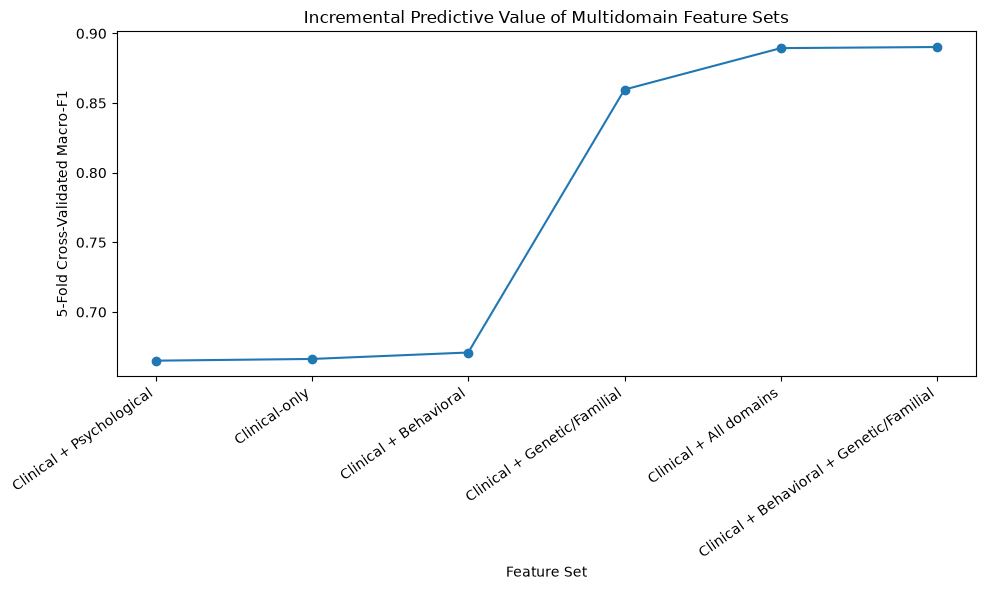

In [180]:
# ============================================================
# STEP 115: Ablation Performance Visualization
# ============================================================

import matplotlib.pyplot as plt

plot_df = ablation_df.copy()

plot_df = plot_df.sort_values(
    'Macro_F1_Mean'
)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df['Model'],
    plot_df['Macro_F1_Mean'],
    marker='o'
)

plt.xticks(
    rotation=35,
    ha='right'
)

plt.ylabel('5-Fold Cross-Validated Macro-F1')
plt.xlabel('Feature Set')
plt.title(
    'Incremental Predictive Value of Multidomain Feature Sets'
)

plt.tight_layout()
plt.show()

In [181]:
# ============================================================
# STEP 116A: Final Candidate Model
# Clinical + Behavioral + Genetic/Familial
# ============================================================

final_features = (
    clinical_features
    + behavioral_features
    + genetic_features
)

X_final = df_ml[
    final_features
].copy()

y_final = df_ml[
    'Health_Risk'
].copy()

categorical_final = (
    X_final
    .select_dtypes(
        include=['object', 'string']
    )
    .columns
    .tolist()
)

numerical_final = (
    X_final
    .select_dtypes(
        include=['int64', 'float64']
    )
    .columns
    .tolist()
)

final_preprocessor = ColumnTransformer([

    (
        'num',
        Pipeline([
            (
                'imputer',
                SimpleImputer(
                    strategy='median'
                )
            ),
            (
                'scaler',
                StandardScaler()
            )
        ]),
        numerical_final
    ),

    (
        'cat',
        Pipeline([
            (
                'imputer',
                SimpleImputer(
                    strategy='most_frequent'
                )
            ),
            (
                'onehot',
                OneHotEncoder(
                    handle_unknown='ignore'
                )
            )
        ]),
        categorical_final
    )
])

final_model = Pipeline([

    (
        'preprocessor',
        final_preprocessor
    ),

    (
        'classifier',
        LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=42
        )
    )
])

final_model.fit(
    X_final,
    y_final
)

print(
    "Final candidate model trained."
)

print(
    "Number of raw features:",
    len(final_features)
)

Final candidate model trained.
Number of raw features: 27


In [182]:
# ============================================================
# STEP 118: Final Candidate — Independent Test Evaluation
# ============================================================

X_train_final = X_train[
    final_features
].copy()

X_test_final = X_test[
    final_features
].copy()

final_model_test = final_model

final_model_test.fit(
    X_train_final,
    y_train
)

test_pred = final_model_test.predict(
    X_test_final
)

test_prob = final_model_test.predict_proba(
    X_test_final
)

final_test_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_test_balanced = balanced_accuracy_score(
    y_test,
    test_pred
)

final_test_macro_f1 = f1_score(
    y_test,
    test_pred,
    average='macro'
)

final_test_weighted_f1 = f1_score(
    y_test,
    test_pred,
    average='weighted'
)

final_test_auc = roc_auc_score(
    y_test,
    test_prob,
    multi_class='ovr',
    average='macro'
)

print("=" * 65)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 65)

print(
    f"Accuracy          : {final_test_accuracy:.4f}"
)

print(
    f"Balanced Accuracy : {final_test_balanced:.4f}"
)

print(
    f"Macro-F1          : {final_test_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : {final_test_weighted_f1:.4f}"
)

print(
    f"Macro ROC-AUC     : {final_test_auc:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        digits=4
    )
)

FINAL TEST-SET PERFORMANCE
Accuracy          : 0.9125
Balanced Accuracy : 0.9097
Macro-F1          : 0.9094
Weighted-F1       : 0.9130
Macro ROC-AUC     : 0.9791

Classification Report:

              precision    recall  f1-score   support

        High     0.9590    0.9360    0.9474       125
         Low     0.9317    0.9259    0.9288       162
    Moderate     0.8376    0.8673    0.8522       113

    accuracy                         0.9125       400
   macro avg     0.9094    0.9097    0.9094       400
weighted avg     0.9136    0.9125    0.9130       400



In [183]:
# ============================================================
# STEP 119A: Probability Calibration
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    classification_report
)
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Create a fresh copy of the final 27-feature model
# ------------------------------------------------------------

calibration_base_model = Pipeline([
    (
        'preprocessor',
        final_preprocessor
    ),
    (
        'classifier',
        LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# Calibrate using ONLY the training data
# ------------------------------------------------------------

calibrated_model = CalibratedClassifierCV(
    estimator=calibration_base_model,
    method='sigmoid',
    cv=5
)

calibrated_model.fit(
    X_train_final,
    y_train
)

print("Calibrated final model trained successfully.")

Calibrated final model trained successfully.


In [184]:
# ============================================================
# STEP 119B: Calibrated Predictions on Untouched Test Set
# ============================================================

calibrated_test_pred = calibrated_model.predict(
    X_test_final
)

calibrated_test_prob = calibrated_model.predict_proba(
    X_test_final
)

print("Calibrated predictions generated.")
print("Probability matrix shape:", calibrated_test_prob.shape)

Calibrated predictions generated.
Probability matrix shape: (400, 3)


In [185]:
# ============================================================
# STEP 119C: Calibrated Model Performance
# ============================================================

cal_accuracy = accuracy_score(
    y_test,
    calibrated_test_pred
)

cal_balanced = balanced_accuracy_score(
    y_test,
    calibrated_test_pred
)

cal_macro_f1 = f1_score(
    y_test,
    calibrated_test_pred,
    average='macro'
)

cal_weighted_f1 = f1_score(
    y_test,
    calibrated_test_pred,
    average='weighted'
)

cal_auc = roc_auc_score(
    y_test,
    calibrated_test_prob,
    multi_class='ovr',
    average='macro'
)

cal_logloss = log_loss(
    y_test,
    calibrated_test_prob
)

print("=" * 65)
print("CALIBRATED FINAL MODEL — TEST SET")
print("=" * 65)

print(f"Accuracy          : {cal_accuracy:.4f}")
print(f"Balanced Accuracy : {cal_balanced:.4f}")
print(f"Macro-F1          : {cal_macro_f1:.4f}")
print(f"Weighted-F1       : {cal_weighted_f1:.4f}")
print(f"Macro ROC-AUC     : {cal_auc:.4f}")
print(f"Log Loss          : {cal_logloss:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        calibrated_test_pred,
        digits=4
    )
)

CALIBRATED FINAL MODEL — TEST SET
Accuracy          : 0.9050
Balanced Accuracy : 0.8888
Macro-F1          : 0.8934
Weighted-F1       : 0.8998
Macro ROC-AUC     : 0.9815
Log Loss          : 0.4366

Classification Report:

              precision    recall  f1-score   support

        High     0.8905    0.9760    0.9313       125
         Low     0.8804    1.0000    0.9364       162
    Moderate     0.9873    0.6903    0.8125       113

    accuracy                         0.9050       400
   macro avg     0.9194    0.8888    0.8934       400
weighted avg     0.9138    0.9050    0.8998       400



In [186]:
# ============================================================
# STEP 119D: Class-wise Brier Scores
# ============================================================

classes = calibrated_model.classes_

brier_results = []

for i, class_name in enumerate(classes):

    y_binary = (
        y_test == class_name
    ).astype(int)

    brier = brier_score_loss(
        y_binary,
        calibrated_test_prob[:, i]
    )

    brier_results.append({
        'Class': class_name,
        'Brier_Score': brier
    })

brier_df = pd.DataFrame(
    brier_results
)

display(
    brier_df.round(4)
)

,Class,Brier_Score
0,High,0.0489
1,Low,0.0634
2,Moderate,0.1120


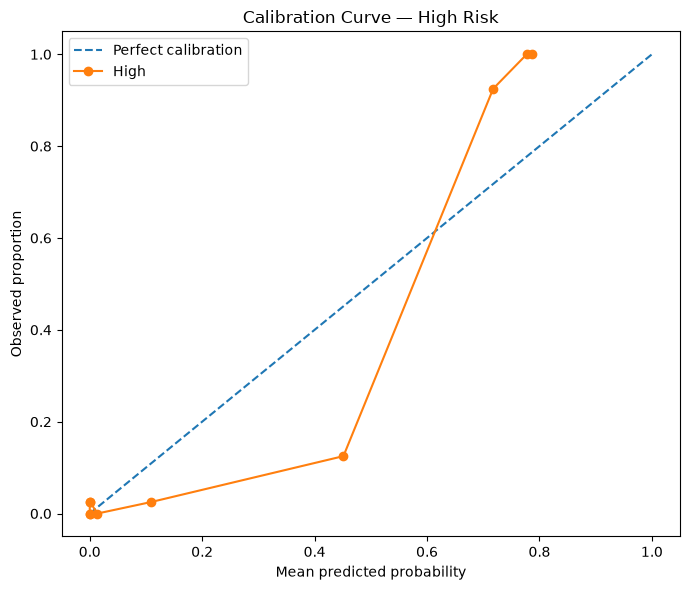

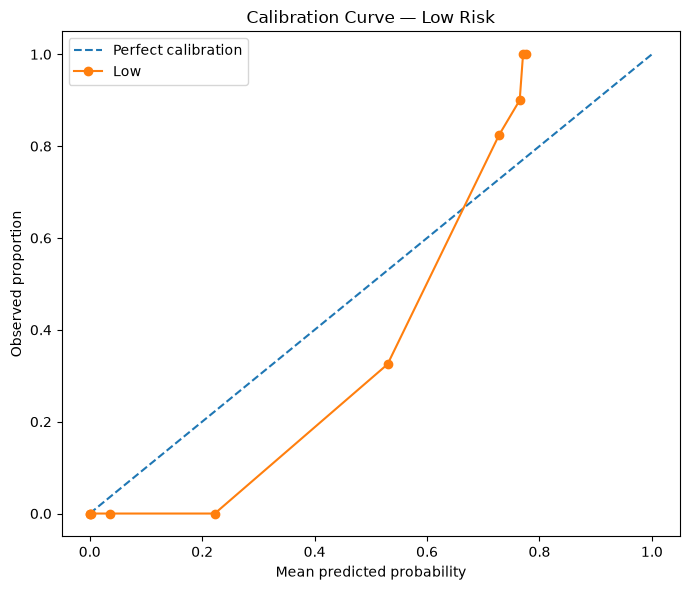

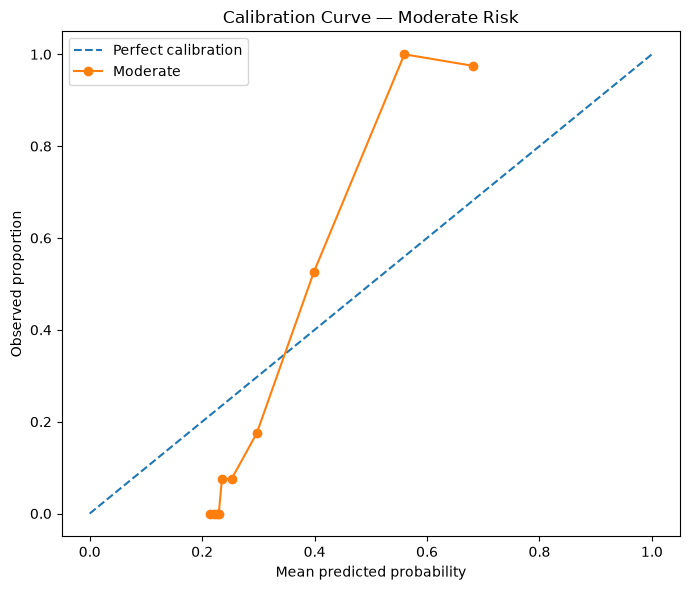

In [187]:
# ============================================================
# STEP 120: Reliability Curves
# ============================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

for i, class_name in enumerate(classes):

    y_binary = (
        y_test == class_name
    ).astype(int)

    prob_true, prob_pred = calibration_curve(
        y_binary,
        calibrated_test_prob[:, i],
        n_bins=10,
        strategy='quantile'
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        label='Perfect calibration'
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker='o',
        label=f'{class_name}'
    )

    plt.xlabel('Mean predicted probability')
    plt.ylabel('Observed proportion')
    plt.title(
        f'Calibration Curve — {class_name} Risk'
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

Confusion Matrix:
[[122   2   1]
 [  0 162   0]
 [ 15  20  78]]


<Figure size 700x600 with 0 Axes>

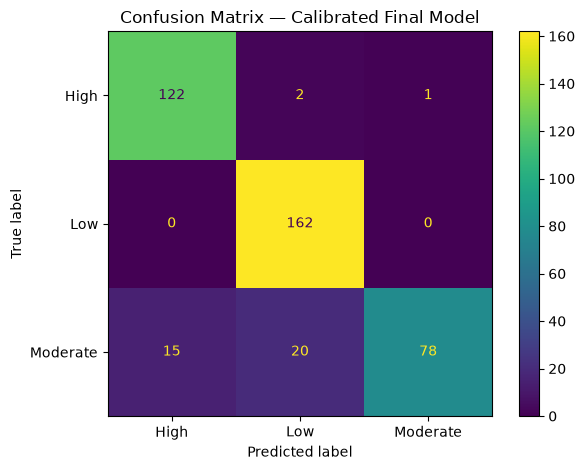

In [188]:
# ============================================================
# STEP 121: Final Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Confusion matrix for calibrated final model
# ------------------------------------------------------------

cm_calibrated = confusion_matrix(
    y_test,
    calibrated_test_pred,
    labels=classes
)

print("Confusion Matrix:")
print(cm_calibrated)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_calibrated,
    display_labels=classes
)

disp.plot(
    values_format='d'
)

plt.title(
    'Confusion Matrix — Calibrated Final Model'
)

plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

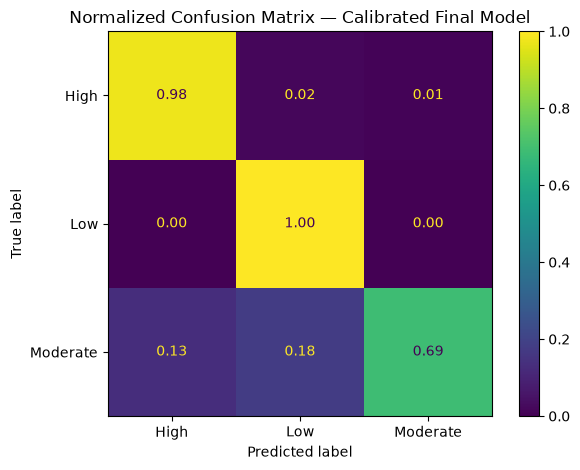

In [189]:
# ============================================================
# STEP 121B: Normalized Confusion Matrix
# ============================================================

cm_normalized = confusion_matrix(
    y_test,
    calibrated_test_pred,
    labels=classes,
    normalize='true'
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=classes
)

disp.plot(
    values_format='.2f'
)

plt.title(
    'Normalized Confusion Matrix — Calibrated Final Model'
)

plt.tight_layout()
plt.show()

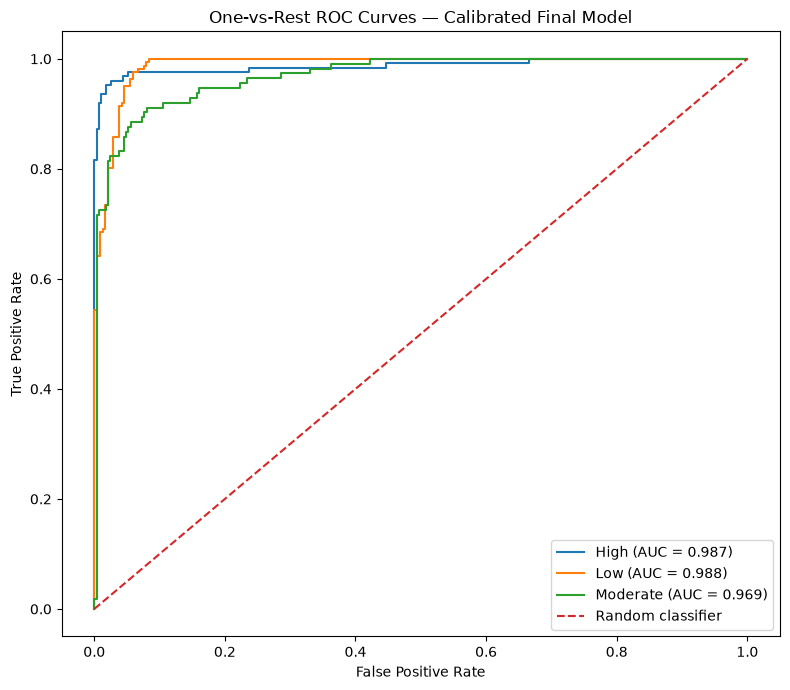

In [190]:
# ============================================================
# STEP 122: Multiclass ROC Curves
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# Binarize the outcome
# ------------------------------------------------------------

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(8, 7))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        calibrated_test_prob[:, i]
    )

    roc_auc_class = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        marker=None,
        label=f'{class_name} (AUC = {roc_auc_class:.3f})'
    )

# ------------------------------------------------------------
# Random classifier reference
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'One-vs-Rest ROC Curves — Calibrated Final Model'
)

plt.legend()
plt.tight_layout()
plt.show()

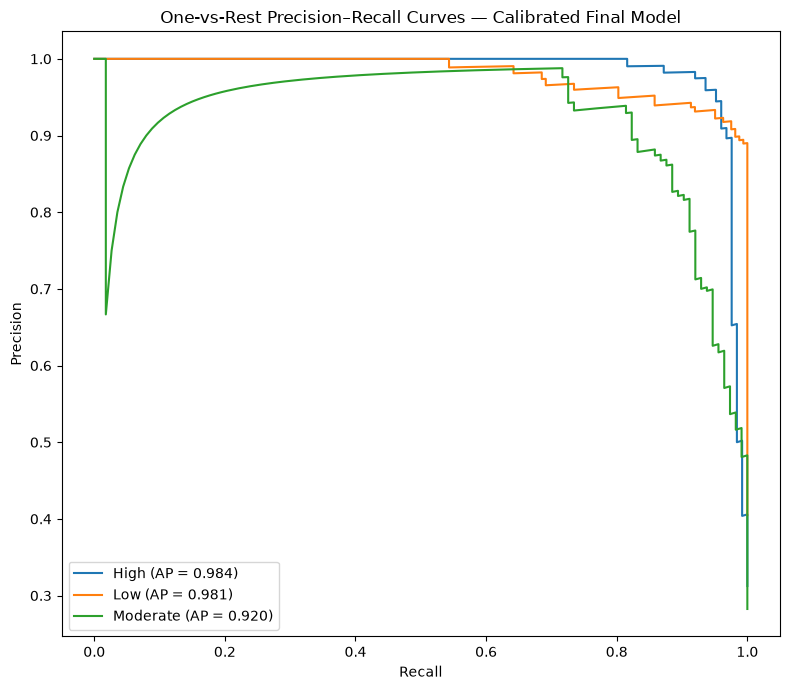

In [191]:
# ============================================================
# STEP 123: Precision-Recall Curves
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 7))

for i, class_name in enumerate(classes):

    precision, recall, _ = precision_recall_curve(
        y_test_binary[:, i],
        calibrated_test_prob[:, i]
    )

    ap = average_precision_score(
        y_test_binary[:, i],
        calibrated_test_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f'{class_name} (AP = {ap:.3f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title(
    'One-vs-Rest Precision–Recall Curves — Calibrated Final Model'
)

plt.legend()
plt.tight_layout()
plt.show()

In [192]:
# ============================================================
# STEP 124: Class-specific ROC-AUC and Average Precision
# ============================================================

roc_results = []

for i, class_name in enumerate(classes):

    # ROC-AUC
    class_auc = roc_auc_score(
        y_test_binary[:, i],
        calibrated_test_prob[:, i]
    )

    # Average Precision
    class_ap = average_precision_score(
        y_test_binary[:, i],
        calibrated_test_prob[:, i]
    )

    roc_results.append({
        'Class': class_name,
        'ROC_AUC': class_auc,
        'Average_Precision': class_ap
    })

roc_pr_df = pd.DataFrame(
    roc_results
)

display(
    roc_pr_df.round(4)
)

,Class,ROC_AUC,Average_Precision
0,High,0.9872,0.9841
1,Low,0.9883,0.9810
2,Moderate,0.9690,0.9202


In [193]:
# ============================================================
# STEP 125: Misclassification Analysis
# ============================================================

error_df = X_test_final.copy()

error_df['Actual_Risk'] = y_test.values

error_df['Predicted_Risk'] = calibrated_test_pred

error_df['Prediction_Correct'] = (
    error_df['Actual_Risk']
    ==
    error_df['Predicted_Risk']
)

# ------------------------------------------------------------
# Only incorrect predictions
# ------------------------------------------------------------

errors_only = error_df[
    ~error_df['Prediction_Correct']
].copy()

print(
    "Total test observations:",
    len(error_df)
)

print(
    "Incorrect predictions:",
    len(errors_only)
)

print(
    "Error rate:",
    round(
        len(errors_only) / len(error_df) * 100,
        2
    ),
    "%"
)

display(
    errors_only[
        [
            'Actual_Risk',
            'Predicted_Risk'
        ]
    ].head(20)
)

Total test observations: 400
Incorrect predictions: 38
Error rate: 9.5 %


,Actual_Risk,Predicted_Risk
1799,Moderate,Low
1155,Moderate,High
1986,Moderate,High
1270,Moderate,High
1807,Moderate,Low
1371,Moderate,High
1045,Moderate,Low
371,High,Moderate
973,Moderate,Low
1099,Moderate,Low


In [194]:
# ============================================================
# STEP 125B: Misclassification Pattern
# ============================================================

error_pattern = pd.crosstab(
    error_df['Actual_Risk'],
    error_df['Predicted_Risk']
)

print("Actual vs Predicted:")
display(error_pattern)

Actual vs Predicted:


Predicted_Risk,High,Low,Moderate
Actual_Risk,,,
High,122,2,1
Low,0,162,0
Moderate,15,20,78


In [195]:
# ============================================================
# STEP 126A: Inspect Final 27-Feature Model
# ============================================================

final_classifier = final_model_test.named_steps['classifier']
final_preprocessor_fitted = final_model_test.named_steps['preprocessor']

print("Final classifier:")
print(final_classifier)

print("\nClasses:")
print(final_classifier.classes_)

print("\nNumber of raw features:")
print(len(final_features))

print("\nRaw features:")
for i, feature in enumerate(final_features, start=1):
    print(f"{i:02d}. {feature}")

Final classifier:
LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

Classes:
['High' 'Low' 'Moderate']

Number of raw features:
27

Raw features:
01. Age
02. BMI
03. Cholesterol
04. Glucose_Level
05. HbA1c
06. Systolic_BP
07. Diastolic_BP
08. LDL
09. HDL
10. Triglycerides
11. CRP
12. eGFR
13. Waist_Circumference
14. Resting_Heart_Rate
15. HRV
16. Smoking_Status
17. Alcohol_Consumption
18. Physical_Activity_Level
19. Diet_Type
20. Sleep_Quality
21. Sleep_Hours
22. PRS_Cardiometabolic
23. PRS_Type2Diabetes
24. APOE_e4_Carrier
25. BRCA_Pathogenic_Variant
26. Family_History_CVD
27. Family_History_T2D


In [196]:
# ============================================================
# STEP 126B: Extract Transformed Feature Names
# ============================================================

transformed_feature_names = (
    final_preprocessor_fitted
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

print("\nFirst transformed features:")

for feature in transformed_feature_names[:30]:
    print(feature)

Number of transformed features: 43

First transformed features:
num__Age
num__BMI
num__Cholesterol
num__Glucose_Level
num__HbA1c
num__Systolic_BP
num__Diastolic_BP
num__LDL
num__HDL
num__Triglycerides
num__CRP
num__eGFR
num__Waist_Circumference
num__Resting_Heart_Rate
num__HRV
num__Sleep_Hours
num__PRS_Cardiometabolic
num__PRS_Type2Diabetes
num__APOE_e4_Carrier
num__BRCA_Pathogenic_Variant
num__Family_History_CVD
num__Family_History_T2D
cat__Smoking_Status_Current smoker
cat__Smoking_Status_Former smoker
cat__Smoking_Status_Non-smoker
cat__Alcohol_Consumption_High
cat__Alcohol_Consumption_Low
cat__Alcohol_Consumption_Moderate
cat__Alcohol_Consumption_Unknown
cat__Physical_Activity_Level_Highly Active


In [197]:
# ============================================================
# STEP 126C: Global Feature Importance
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Transform the complete test dataset
# ------------------------------------------------------------

X_test_transformed = (
    final_preprocessor_fitted
    .transform(X_test_final)
)

# Convert sparse matrix if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# ------------------------------------------------------------
# Logistic regression coefficients
# ------------------------------------------------------------

coefficients = final_classifier.coef_

print(
    "Coefficient matrix shape:",
    coefficients.shape
)

print(
    "Transformed feature matrix shape:",
    X_test_transformed.shape
)

Coefficient matrix shape: (3, 43)
Transformed feature matrix shape: (400, 43)


In [198]:
# ============================================================
# STEP 126D: Aggregate One-Hot Features
# ============================================================

global_importance = []

for raw_feature in final_features:

    # Find all transformed columns belonging to this raw feature
    matching_indices = [
        i
        for i, name in enumerate(transformed_feature_names)
        if name.startswith(f"num__{raw_feature}")
        or name.startswith(f"cat__{raw_feature}")
    ]

    if len(matching_indices) == 0:
        continue

    # --------------------------------------------------------
    # Mean absolute contribution across patients/classes
    # --------------------------------------------------------

    feature_contribution = np.abs(
        X_test_transformed[:, matching_indices, None]
        *
        coefficients[:, matching_indices].T[None, :, :]
    )

    importance_value = feature_contribution.mean()

    global_importance.append({
        'Feature': raw_feature,
        'Mean_Absolute_Contribution': importance_value
    })

global_importance_df = pd.DataFrame(
    global_importance
)

global_importance_df = (
    global_importance_df
    .sort_values(
        'Mean_Absolute_Contribution',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    global_importance_df.round(5)
)

,Feature,Mean_Absolute_Contribution
0,Age,2.11796
1,LDL,1.59821
2,Family_History_CVD,1.41439
3,PRS_Cardiometabolic,1.38497
4,HDL,1.30630
5,Systolic_BP,0.78234
6,Cholesterol,0.76516
7,PRS_Type2Diabetes,0.29479
8,Triglycerides,0.28196
9,Smoking_Status,0.26657


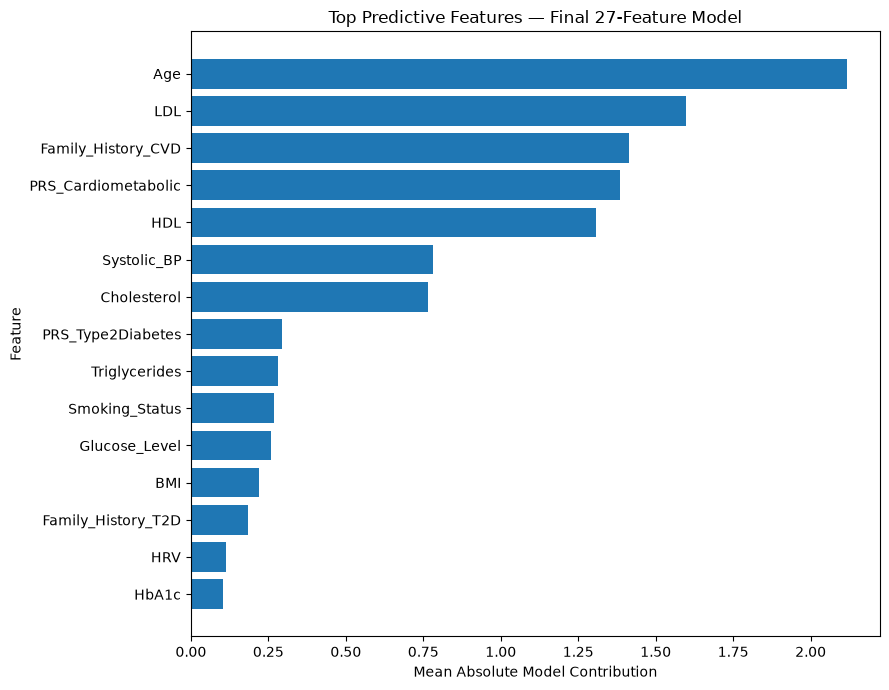

In [199]:
# ============================================================
# STEP 126E: Global Importance Plot
# ============================================================

top15 = (
    global_importance_df
    .head(15)
    .sort_values(
        'Mean_Absolute_Contribution'
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top15['Feature'],
    top15['Mean_Absolute_Contribution']
)

plt.xlabel(
    'Mean Absolute Model Contribution'
)

plt.ylabel(
    'Feature'
)

plt.title(
    'Top Predictive Features — Final 27-Feature Model'
)

plt.tight_layout()
plt.show()

In [200]:
# ============================================================
# STEP 126F: Class-Specific Feature Importance
# ============================================================

class_importance_tables = {}

for class_index, class_name in enumerate(
    final_classifier.classes_
):

    rows = []

    for raw_feature in final_features:

        matching_indices = [
            i
            for i, name in enumerate(transformed_feature_names)
            if name.startswith(f"num__{raw_feature}")
            or name.startswith(f"cat__{raw_feature}")
        ]

        if len(matching_indices) == 0:
            continue

        contribution = (
            X_test_transformed[:, matching_indices]
            *
            coefficients[
                class_index,
                matching_indices
            ]
        )

        mean_absolute = np.mean(
            np.abs(contribution)
        )

        mean_signed = np.mean(
            contribution
        )

        rows.append({
            'Feature': raw_feature,
            'Mean_Absolute_Contribution': mean_absolute,
            'Mean_Signed_Contribution': mean_signed
        })

    class_df = pd.DataFrame(rows)

    class_df = (
        class_df
        .sort_values(
            'Mean_Absolute_Contribution',
            ascending=False
        )
        .reset_index(drop=True)
    )

    class_importance_tables[class_name] = class_df

    print("\n" + "=" * 65)
    print(f"TOP FEATURES — {class_name}")
    print("=" * 65)

    display(
        class_df.head(10).round(5)
    )


TOP FEATURES — High


,Feature,Mean_Absolute_Contribution,Mean_Signed_Contribution
0,Age,3.17694,-0.04947
1,LDL,2.39731,-0.00147
2,Family_History_CVD,2.12158,0.00805
3,PRS_Cardiometabolic,2.07746,-0.13387
4,HDL,1.95944,0.02652
5,Systolic_BP,1.17351,-0.05878
6,Cholesterol,1.14774,-0.05195
7,Triglycerides,0.42294,0.04883
8,Smoking_Status,0.39985,-0.20187
9,Glucose_Level,0.38565,0.01489



TOP FEATURES — Low


,Feature,Mean_Absolute_Contribution,Mean_Signed_Contribution
0,Age,2.97565,0.04634
1,LDL,2.05265,0.00126
2,Family_History_CVD,1.91841,-0.00728
3,PRS_Cardiometabolic,1.84201,0.11870
4,HDL,1.71659,-0.02323
5,Systolic_BP,1.08704,0.05445
6,Cholesterol,0.97793,0.04426
7,PRS_Type2Diabetes,0.44218,0.02273
8,Smoking_Status,0.36590,0.18792
9,Triglycerides,0.35758,-0.04128



TOP FEATURES — Moderate


,Feature,Mean_Absolute_Contribution,Mean_Signed_Contribution
0,LDL,0.34466,0.00021
1,HDL,0.24286,-0.00329
2,PRS_Cardiometabolic,0.23545,0.01517
3,Family_History_CVD,0.20317,-0.00077
4,Age,0.20129,0.00313
5,BMI,0.16999,0.00551
6,Cholesterol,0.16980,0.00769
7,HbA1c,0.11198,0.01116
8,Systolic_BP,0.08646,0.00433
9,Family_History_T2D,0.08199,0.00147


In [201]:
# ============================================================
# STEP 127A: Select Patient for Explanation
# ============================================================

patient_index = 84

patient = X_test_final.iloc[
    patient_index
].copy()

print("Patient index:", patient_index)

display(
    patient.to_frame(
        name='Value'
    )
)

Patient index: 84


,Value
Age,60
BMI,17.9
Cholesterol,229.7
Glucose_Level,71.1
HbA1c,3.5
Systolic_BP,108
Diastolic_BP,68
LDL,170.4
HDL,38.5
Triglycerides,104.0


In [202]:
# ============================================================
# STEP 127B: Patient Prediction
# ============================================================

patient_input = X_test_final.iloc[
    [patient_index]
]

patient_prediction = calibrated_model.predict(
    patient_input
)[0]

patient_probability = calibrated_model.predict_proba(
    patient_input
)[0]

patient_probability_df = pd.DataFrame({
    'Risk_Class': calibrated_model.classes_,
    'Probability': patient_probability
})

print("Predicted Risk:", patient_prediction)

display(
    patient_probability_df.assign(
        Probability_Percent=lambda x:
        x['Probability'] * 100
    ).round(2)
)

Predicted Risk: High


,Risk_Class,Probability,Probability_Percent
0,High,0.79,79.46
1,Low,0.00,0.00
2,Moderate,0.21,20.54


In [203]:
# ============================================================
# STEP 127C: Patient-Level Model Contributions
# ============================================================

patient_transformed = (
    final_preprocessor_fitted
    .transform(patient_input)
)

if hasattr(patient_transformed, "toarray"):
    patient_transformed = patient_transformed.toarray()

# Predicted class from the uncalibrated model
patient_model_prediction = final_model_test.predict(
    patient_input
)[0]

class_index = list(
    final_classifier.classes_
).index(
    patient_model_prediction
)

# ------------------------------------------------------------
# Contribution of each transformed feature
# ------------------------------------------------------------

patient_contributions = (
    patient_transformed[0]
    *
    coefficients[class_index]
)

# ------------------------------------------------------------
# Build dataframe
# ------------------------------------------------------------

patient_contribution_df = pd.DataFrame({
    'Transformed_Feature': transformed_feature_names,
    'Contribution': patient_contributions,
    'Absolute_Contribution': np.abs(
        patient_contributions
    )
})

patient_contribution_df = (
    patient_contribution_df
    .sort_values(
        'Absolute_Contribution',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    patient_contribution_df.head(20).round(5)
)

,Transformed_Feature,Contribution,Absolute_Contribution
0,num__LDL,5.21437,5.21437
1,num__Age,2.59801,2.59801
2,num__HDL,2.56736,2.56736
3,num__Family_History_CVD,2.37947,2.37947
4,num__PRS_Cardiometabolic,2.17615,2.17615
5,cat__Smoking_Status_Current smoker,1.45775,1.45775
6,num__Cholesterol,1.39037,1.39037
7,num__Glucose_Level,-0.76897,0.76897
8,num__HbA1c,0.45991,0.45991
9,num__Triglycerides,0.40987,0.40987


In [204]:
# ============================================================
# STEP 127D: Aggregate Patient Contributions
# ============================================================

patient_raw_contributions = []

for raw_feature in final_features:

    matching_indices = [
        i
        for i, name in enumerate(transformed_feature_names)
        if name.startswith(f"num__{raw_feature}")
        or name.startswith(f"cat__{raw_feature}")
    ]

    if len(matching_indices) == 0:
        continue

    signed_contribution = np.sum(
        patient_contributions[
            matching_indices
        ]
    )

    patient_raw_contributions.append({
        'Feature': raw_feature,
        'Signed_Contribution': signed_contribution,
        'Absolute_Contribution': abs(
            signed_contribution
        )
    })

patient_explanation_df = pd.DataFrame(
    patient_raw_contributions
)

patient_explanation_df = (
    patient_explanation_df
    .sort_values(
        'Absolute_Contribution',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    patient_explanation_df
    .head(15)
    .round(5)
)

,Feature,Signed_Contribution,Absolute_Contribution
0,LDL,5.21437,5.21437
1,Age,2.59801,2.59801
2,HDL,2.56736,2.56736
3,Family_History_CVD,2.37947,2.37947
4,PRS_Cardiometabolic,2.17615,2.17615
5,Smoking_Status,1.45775,1.45775
6,Cholesterol,1.39037,1.39037
7,Glucose_Level,-0.76897,0.76897
8,HbA1c,0.45991,0.45991
9,Triglycerides,0.40987,0.40987


In [205]:
# ============================================================
# STEP 127E: Positive and Negative Drivers
# ============================================================

positive_drivers = (
    patient_explanation_df[
        patient_explanation_df[
            'Signed_Contribution'
        ] > 0
    ]
    .sort_values(
        'Signed_Contribution',
        ascending=False
    )
    .head(10)
)

negative_drivers = (
    patient_explanation_df[
        patient_explanation_df[
            'Signed_Contribution'
        ] < 0
    ]
    .sort_values(
        'Signed_Contribution'
    )
    .head(10)
)

print("=" * 65)
print("TOP FACTORS SUPPORTING PREDICTED CLASS")
print("=" * 65)

display(
    positive_drivers.round(5)
)

print("=" * 65)
print("TOP FACTORS OPPOSING PREDICTED CLASS")
print("=" * 65)

display(
    negative_drivers.round(5)
)

TOP FACTORS SUPPORTING PREDICTED CLASS


,Feature,Signed_Contribution,Absolute_Contribution
0,LDL,5.21437,5.21437
1,Age,2.59801,2.59801
2,HDL,2.56736,2.56736
3,Family_History_CVD,2.37947,2.37947
4,PRS_Cardiometabolic,2.17615,2.17615
5,Smoking_Status,1.45775,1.45775
6,Cholesterol,1.39037,1.39037
8,HbA1c,0.45991,0.45991
9,Triglycerides,0.40987,0.40987
14,PRS_Type2Diabetes,0.11886,0.11886


TOP FACTORS OPPOSING PREDICTED CLASS


,Feature,Signed_Contribution,Absolute_Contribution
7,Glucose_Level,-0.76897,0.76897
10,BMI,-0.35690,0.35690
11,Systolic_BP,-0.33073,0.33073
12,Alcohol_Consumption,-0.21379,0.21379
13,Family_History_T2D,-0.16631,0.16631
17,Resting_Heart_Rate,-0.08560,0.08560
18,CRP,-0.07220,0.07220
22,Diet_Type,-0.02674,0.02674
24,Diastolic_BP,-0.02035,0.02035


In [206]:
# ============================================================
# STEP 128: Patient Explanation Summary
# ============================================================

top_drivers = (
    patient_explanation_df
    .head(5)
    .copy()
)

print("=" * 70)
print("PERSONALISED MODEL EXPLANATION")
print("=" * 70)

print(
    f"\nPredicted Risk Category: "
    f"{patient_prediction}"
)

print("\nRisk Probabilities:")

for _, row in patient_probability_df.iterrows():

    print(
        f"  {row['Risk_Class']}: "
        f"{row['Probability'] * 100:.1f}%"
    )

print("\nTop Model Contributors:")

for rank, (_, row) in enumerate(
    top_drivers.iterrows(),
    start=1
):

    direction = (
        "toward predicted class"
        if row['Signed_Contribution'] > 0
        else "away from predicted class"
    )

    print(
        f"  {rank}. {row['Feature']} "
        f"({row['Signed_Contribution']:.3f}; "
        f"{direction})"
    )

PERSONALISED MODEL EXPLANATION

Predicted Risk Category: High

Risk Probabilities:
  High: 79.5%
  Low: 0.0%
  Moderate: 20.5%

Top Model Contributors:
  1. LDL (5.214; toward predicted class)
  2. Age (2.598; toward predicted class)
  3. HDL (2.567; toward predicted class)
  4. Family_History_CVD (2.379; toward predicted class)
  5. PRS_Cardiometabolic (2.176; toward predicted class)


In [207]:
# ============================================================
# STEP 129A: Recommendation Knowledge Base
# ============================================================

recommendation_rules = {

    'LDL': {
        'domain': 'Lipid management',
        'actionable': True,
        'recommendation':
            'Consider clinical assessment of LDL cholesterol and '
            'review of overall cardiovascular risk. Dietary pattern '
            'and other lipid-management strategies should be discussed '
            'with an appropriate healthcare professional.'
    },

    'Triglycerides': {
        'domain': 'Lipid / metabolic health',
        'actionable': True,
        'recommendation':
            'Review dietary pattern, metabolic risk factors and '
            'physical activity. Consider clinical assessment if '
            'triglycerides remain elevated.'
    },

    'Cholesterol': {
        'domain': 'Lipid management',
        'actionable': True,
        'recommendation':
            'Consider reviewing the complete lipid profile and '
            'overall cardiovascular risk with a healthcare professional.'
    },

    'Smoking_Status': {
        'domain': 'Smoking cessation',
        'actionable': True,
        'recommendation':
            'Smoking cessation support should be prioritized. '
            'Consider behavioural support and evidence-based cessation '
            'options with a healthcare professional.'
    },

    'Physical_Activity_Level': {
        'domain': 'Physical activity',
        'actionable': True,
        'recommendation':
            'Review current physical activity and aim for a sustainable '
            'activity pattern appropriate to the individual.'
    },

    'Diet_Type': {
        'domain': 'Dietary pattern',
        'actionable': True,
        'recommendation':
            'Review overall dietary quality, emphasizing a balanced '
            'nutrient-dense dietary pattern appropriate to individual needs.'
    },

    'Alcohol_Consumption': {
        'domain': 'Alcohol use',
        'actionable': True,
        'recommendation':
            'Review alcohol intake and consider reducing consumption '
            'if intake is excessive.'
    },

    'Sleep_Quality': {
        'domain': 'Sleep quality',
        'actionable': True,
        'recommendation':
            'Review sleep quality and identify modifiable factors '
            'that may be interfering with restorative sleep.'
    },

    'Sleep_Hours': {
        'domain': 'Sleep duration',
        'actionable': True,
        'recommendation':
            'Review sleep duration and aim for an adequate, consistent '
            'sleep schedule.'
    },

    'Stress_Level': {
        'domain': 'Stress management',
        'actionable': True,
        'recommendation':
            'Consider stress-management strategies and assess persistent '
            'or substantial stress with an appropriate professional when needed.'
    },

    'BMI': {
        'domain': 'Weight status',
        'actionable': True,
        'recommendation':
            'Interpret BMI in context rather than targeting weight change '
            'automatically. Consider nutritional and clinical assessment '
            'when BMI is outside the healthy range.'
    },

    'Systolic_BP': {
        'domain': 'Blood pressure',
        'actionable': True,
        'recommendation':
            'Review blood pressure using repeated measurements and '
            'appropriate clinical context rather than relying on a single value.'
    },

    'Diastolic_BP': {
        'domain': 'Blood pressure',
        'actionable': True,
        'recommendation':
            'Review blood pressure using repeated measurements and '
            'appropriate clinical context rather than relying on a single value.'
    },

    'Glucose_Level': {
        'domain': 'Glucose / metabolic health',
        'actionable': True,
        'recommendation':
            'Interpret glucose together with symptoms, fasting status '
            'and other metabolic measures. Consider clinical assessment '
            'when abnormal.'
    },

    'HbA1c': {
        'domain': 'Glycemic health',
        'actionable': True,
        'recommendation':
            'Interpret HbA1c in clinical context and consider follow-up '
            'assessment when abnormal.'
    },

    'Waist_Circumference': {
        'domain': 'Metabolic health',
        'actionable': True,
        'recommendation':
            'Interpret waist circumference together with BMI and other '
            'metabolic risk indicators.'
    },

    'Age': {
        'domain': 'Non-modifiable risk factor',
        'actionable': False,
        'recommendation':
            'Age is non-modifiable and should be used for risk context only.'
    },

    'Family_History_CVD': {
        'domain': 'Family cardiovascular history',
        'actionable': False,
        'recommendation':
            'Family history is non-modifiable but should be considered '
            'when interpreting overall cardiovascular risk.'
    },

    'Family_History_T2D': {
        'domain': 'Family diabetes history',
        'actionable': False,
        'recommendation':
            'Family history is non-modifiable but can inform metabolic '
            'risk assessment.'
    },

    'PRS_Cardiometabolic': {
        'domain': 'Genetic risk',
        'actionable': False,
        'recommendation':
            'Genetic risk is non-modifiable and should be interpreted '
            'as part of the overall risk profile rather than as a treatment target.'
    },

    'PRS_Type2Diabetes': {
        'domain': 'Genetic risk',
        'actionable': False,
        'recommendation':
            'Genetic risk is non-modifiable and should be interpreted '
            'as part of the overall metabolic risk profile.'
    },

    'APOE_e4_Carrier': {
        'domain': 'Genetic risk',
        'actionable': False,
        'recommendation':
            'Genetic carrier status is non-modifiable and should be '
            'used for risk context only.'
    },

    'BRCA_Pathogenic_Variant': {
        'domain': 'Genetic risk',
        'actionable': False,
        'recommendation':
            'Genetic variant status is non-modifiable and should be '
            'interpreted through appropriate genetic/clinical context.'
    },

    'HDL': {
        'domain': 'Lipid profile',
        'actionable': False,
        'recommendation':
            'HDL should be interpreted as part of the complete lipid '
            'profile rather than treated as an isolated target.'
    },

    'eGFR': {
        'domain': 'Kidney function',
        'actionable': False,
        'recommendation':
            'Interpret eGFR in clinical context and according to repeated '
            'measurements and relevant kidney-health assessment.'
    },

    'Resting_Heart_Rate': {
        'domain': 'Cardiovascular monitoring',
        'actionable': False,
        'recommendation':
            'Interpret resting heart rate in the context of fitness, '
            'medications, symptoms and repeated measurements.'
    },

    'HRV': {
        'domain': 'Physiological monitoring',
        'actionable': False,
        'recommendation':
            'Interpret HRV cautiously and in context rather than treating '
            'it as an independent treatment target.'
    },

    'CRP': {
        'domain': 'Inflammatory marker',
        'actionable': False,
        'recommendation':
            'Interpret CRP in clinical context because many factors can '
            'influence this biomarker.'
    }
}

In [208]:
# ============================================================
# STEP 129B: Clinical Signal Detection
# ============================================================

def clinical_signal(feature, patient):

    value = patient[feature]

    # --------------------------------------------------------
    # LDL
    # --------------------------------------------------------

    if feature == 'LDL':

        if value >= 160:
            return 'HIGH'

        elif value >= 130:
            return 'MODERATE'

        else:
            return 'LOW'

    # --------------------------------------------------------
    # Triglycerides
    # --------------------------------------------------------

    if feature == 'Triglycerides':

        if value >= 200:
            return 'HIGH'

        elif value >= 150:
            return 'MODERATE'

        else:
            return 'LOW'

    # --------------------------------------------------------
    # Total cholesterol
    # --------------------------------------------------------

    if feature == 'Cholesterol':

        if value >= 240:
            return 'HIGH'

        elif value >= 200:
            return 'MODERATE'

        else:
            return 'LOW'

    # --------------------------------------------------------
    # Smoking
    # --------------------------------------------------------

    if feature == 'Smoking_Status':

        if value == 'Current smoker':
            return 'HIGH'

        elif value == 'Former smoker':
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # BMI
    # --------------------------------------------------------

    if feature == 'BMI':

        if value < 18.5:
            return 'LOW_BMI'

        elif value >= 30:
            return 'HIGH'

        elif value >= 25:
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Blood pressure
    # --------------------------------------------------------

    if feature in ['Systolic_BP', 'Diastolic_BP']:

        sbp = patient['Systolic_BP']
        dbp = patient['Diastolic_BP']

        if sbp >= 140 or dbp >= 90:
            return 'HIGH'

        elif sbp >= 130 or dbp >= 80:
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Glucose
    # --------------------------------------------------------

    if feature == 'Glucose_Level':

        if value >= 126:
            return 'HIGH'

        elif value >= 100:
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # HbA1c
    # --------------------------------------------------------

    if feature == 'HbA1c':

        if value >= 6.5:
            return 'HIGH'

        elif value >= 5.7:
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Physical activity
    # --------------------------------------------------------

    if feature == 'Physical_Activity_Level':

        if value == 'Sedentary':
            return 'HIGH'

        elif value == 'Lightly Active':
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Sleep quality
    # --------------------------------------------------------

    if feature == 'Sleep_Quality':

        if value == 'Poor':
            return 'HIGH'

        elif value == 'Fair':
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Alcohol
    # --------------------------------------------------------

    if feature == 'Alcohol_Consumption':

        if value == 'High':
            return 'HIGH'

        elif value == 'Moderate':
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Stress
    # --------------------------------------------------------

    if feature == 'Stress_Level':

        if value >= 7:
            return 'HIGH'

        elif value >= 5:
            return 'MODERATE'

        return 'LOW'

    # --------------------------------------------------------
    # Default
    # --------------------------------------------------------

    return 'UNKNOWN'

In [209]:
# ============================================================
# STEP 129C: Recommendation Safety Gate
# ============================================================

def recommendation_gate(feature, patient):

    value = patient[feature]

    # --------------------------------------------------------
    # BMI
    # --------------------------------------------------------

    if feature == 'BMI':

        if value < 18.5:
            return False, 'LOW_BMI'

        return True, 'ACTIONABLE'

    # --------------------------------------------------------
    # Blood pressure
    # --------------------------------------------------------

    if feature in ['Systolic_BP', 'Diastolic_BP']:

        sbp = patient['Systolic_BP']
        dbp = patient['Diastolic_BP']

        if sbp < 130 and dbp < 80:
            return False, 'BP_NOT_ELEVATED'

        return True, 'ELEVATED_BP'

    # --------------------------------------------------------
    # Glucose
    # --------------------------------------------------------

    if feature == 'Glucose_Level':

        if value < 70:
            return False, 'LOW_GLUCOSE'

        return value >= 100, 'GLUCOSE_SIGNAL'

    # --------------------------------------------------------
    # HbA1c
    # --------------------------------------------------------

    if feature == 'HbA1c':

        if value < 5.7:
            return False, 'NOT_ELEVATED'

        return True, 'ELEVATED_HBA1C'

    # --------------------------------------------------------
    # Smoking
    # --------------------------------------------------------

    if feature == 'Smoking_Status':

        return (
            value == 'Current smoker',
            'CURRENT_SMOKER'
        )

    # --------------------------------------------------------
    # Default
    # --------------------------------------------------------

    return True, 'GENERAL'

In [210]:
# ============================================================
# STEP 129D: Personalized Recommendation Engine
# ============================================================

def generate_recommendations(
    patient,
    explanation_df,
    top_n=10
):

    recommendations = []

    for _, row in explanation_df.iterrows():

        feature = row['Feature']

        contribution = row[
            'Signed_Contribution'
        ]

        absolute_contribution = row[
            'Absolute_Contribution'
        ]

        # ----------------------------------------------------
        # Check whether recommendation rule exists
        # ----------------------------------------------------

        if feature not in recommendation_rules:
            continue

        rule = recommendation_rules[
            feature
        ]

        # ----------------------------------------------------
        # Clinical signal
        # ----------------------------------------------------

        signal = clinical_signal(
            feature,
            patient
        )

        # ----------------------------------------------------
        # Safety gate
        # ----------------------------------------------------

        allowed, gate_reason = (
            recommendation_gate(
                feature,
                patient
            )
        )

        # ----------------------------------------------------
        # Non-actionable variables
        # ----------------------------------------------------

        if not rule['actionable']:

            recommendations.append({

                'Feature': feature,

                'Patient_Value':
                    patient[feature],

                'Model_Contribution':
                    contribution,

                'Clinical_Signal':
                    signal,

                'Actionable':
                    False,

                'Recommendation_Priority':
                    'CONTEXT',

                'Recommendation':
                    rule['recommendation']

            })

            continue

        # ----------------------------------------------------
        # Safety gate blocks recommendation
        # ----------------------------------------------------

        if not allowed:

            continue

        # ----------------------------------------------------
        # Only recommend when clinical signal exists
        # ----------------------------------------------------

        if signal not in [
            'HIGH',
            'MODERATE'
        ]:

            continue

        # ----------------------------------------------------
        # Priority score
        # ----------------------------------------------------

        signal_weight = {

            'HIGH': 3,

            'MODERATE': 2

        }.get(
            signal,
            0
        )

        priority_score = (
            absolute_contribution
            *
            signal_weight
        )

        recommendations.append({

            'Feature': feature,

            'Patient_Value':
                patient[feature],

            'Model_Contribution':
                contribution,

            'Clinical_Signal':
                signal,

            'Actionable':
                True,

            'Priority_Score':
                priority_score,

            'Recommendation_Priority':
                'HIGH'
                if signal == 'HIGH'
                else 'MODERATE',

            'Recommendation':
                rule['recommendation']

        })

    # --------------------------------------------------------
    # Sort recommendations
    # --------------------------------------------------------

    recommendations_df = pd.DataFrame(
        recommendations
    )

    if len(recommendations_df) == 0:

        return recommendations_df

    recommendations_df = (
        recommendations_df
        .sort_values(
            'Priority_Score',
            ascending=False,
            na_position='last'
        )
        .reset_index(drop=True)
    )

    return recommendations_df.head(top_n)

In [211]:
# ============================================================
# STEP 129E: Generate Patient 84 Recommendations
# ============================================================

recommendations_patient84 = (
    generate_recommendations(
        patient=patient,
        explanation_df=patient_explanation_df,
        top_n=10
    )
)

display(
    recommendations_patient84.round(4)
)

,Feature,Patient_Value,Model_Contribution,Clinical_Signal,Actionable,Priority_Score,Recommendation_Priority,Recommendation
0,LDL,170.4,5.2144,HIGH,True,15.6431,HIGH,Consider clinical assessment of LDL cholestero...
1,Smoking_Status,Current smoker,1.4577,HIGH,True,4.3732,HIGH,Smoking cessation support should be prioritize...
2,Cholesterol,229.7,1.3904,MODERATE,True,2.7807,MODERATE,Consider reviewing the complete lipid profile ...
3,Alcohol_Consumption,Moderate,-0.2138,MODERATE,True,0.4276,MODERATE,Review alcohol intake and consider reducing co...
4,Sleep_Quality,Fair,0.1019,MODERATE,True,0.2038,MODERATE,Review sleep quality and identify modifiable f...
5,Age,60,2.5980,UNKNOWN,False,NaN,CONTEXT,Age is non-modifiable and should be used for r...
6,HDL,38.5,2.5674,UNKNOWN,False,NaN,CONTEXT,HDL should be interpreted as part of the compl...
7,Family_History_CVD,1,2.3795,UNKNOWN,False,NaN,CONTEXT,Family history is non-modifiable but should be...
8,PRS_Cardiometabolic,0.8,2.1762,UNKNOWN,False,NaN,CONTEXT,Genetic risk is non-modifiable and should be i...
9,Family_History_T2D,0,-0.1663,UNKNOWN,False,NaN,CONTEXT,Family history is non-modifiable but can infor...


In [212]:
# ============================================================
# STEP 129F: Patient Recommendation Report
# ============================================================

print("=" * 75)
print("PERSONALISED HEALTHCARE RECOMMENDATION REPORT")
print("=" * 75)

print(
    f"\nPredicted Risk: {patient_prediction}"
)

print("\nRisk Probabilities:")

for _, row in patient_probability_df.iterrows():

    print(
        f"  {row['Risk_Class']}: "
        f"{row['Probability'] * 100:.1f}%"
    )

print("\nTop Model Contributors:")

for rank, (_, row) in enumerate(
    patient_explanation_df.head(5).iterrows(),
    start=1
):

    print(
        f"  {rank}. {row['Feature']} "
        f"({row['Signed_Contribution']:.3f})"
    )

print("\n" + "-" * 75)
print("PRIORITIZED ACTIONABLE AREAS")
print("-" * 75)

for rank, (_, row) in enumerate(
    recommendations_patient84.iterrows(),
    start=1
):

    print(
        f"\n{rank}. {row['Feature']}"
    )

    print(
        f"   Patient value: "
        f"{row['Patient_Value']}"
    )

    print(
        f"   Clinical signal: "
        f"{row['Clinical_Signal']}"
    )

    print(
        f"   Priority: "
        f"{row['Recommendation_Priority']}"
    )

    print(
        f"   Recommendation: "
        f"{row['Recommendation']}"
    )

print("\n" + "=" * 75)
print(
    "Research prototype — not a diagnostic or treatment system."
)
print("=" * 75)

PERSONALISED HEALTHCARE RECOMMENDATION REPORT

Predicted Risk: High

Risk Probabilities:
  High: 79.5%
  Low: 0.0%
  Moderate: 20.5%

Top Model Contributors:
  1. LDL (5.214)
  2. Age (2.598)
  3. HDL (2.567)
  4. Family_History_CVD (2.379)
  5. PRS_Cardiometabolic (2.176)

---------------------------------------------------------------------------
PRIORITIZED ACTIONABLE AREAS
---------------------------------------------------------------------------

1. LDL
   Patient value: 170.4
   Clinical signal: HIGH
   Priority: HIGH
   Recommendation: Consider clinical assessment of LDL cholesterol and review of overall cardiovascular risk. Dietary pattern and other lipid-management strategies should be discussed with an appropriate healthcare professional.

2. Smoking_Status
   Patient value: Current smoker
   Clinical signal: HIGH
   Priority: HIGH
   Recommendation: Smoking cessation support should be prioritized. Consider behavioural support and evidence-based cessation options with a heal

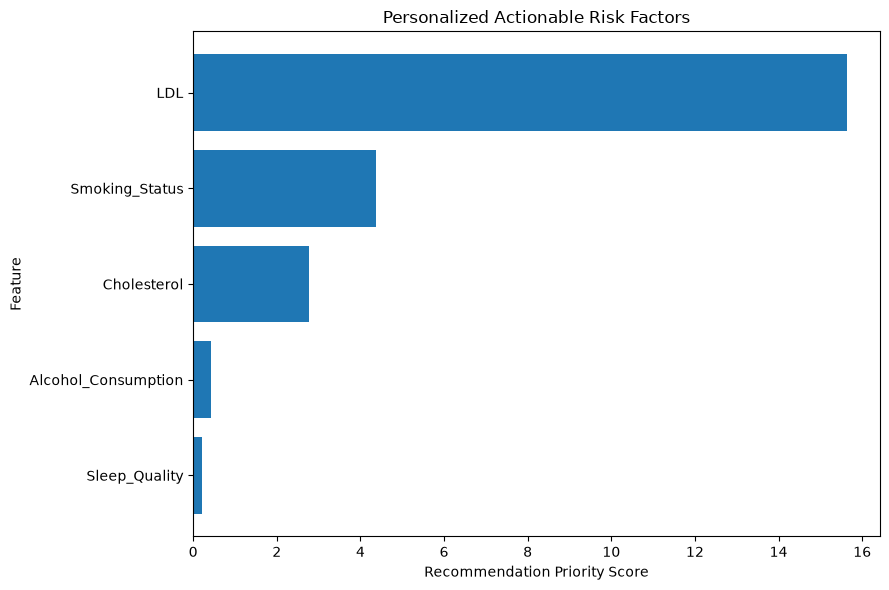

In [213]:
# ============================================================
# STEP 130: Recommendation Priority Plot
# ============================================================

plot_recs = (
    recommendations_patient84
    .copy()
)

if len(plot_recs) > 0:

    plot_recs = (
        plot_recs
        .sort_values(
            'Priority_Score'
        )
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        plot_recs['Feature'],
        plot_recs['Priority_Score']
    )

    plt.xlabel(
        'Recommendation Priority Score'
    )

    plt.ylabel(
        'Feature'
    )

    plt.title(
        'Personalized Actionable Risk Factors'
    )

    plt.tight_layout()
    plt.show()

In [214]:
# ============================================================
# STEP 131A: Intelligent Recommendation Decision Matrix
# ============================================================

decision_matrix = {

    # --------------------------------------------------------
    # HIGH-PRIORITY ACTIONABLE
    # --------------------------------------------------------

    'LDL': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 3
    },

    'Smoking_Status': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 3
    },

    'Cholesterol': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Triglycerides': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Physical_Activity_Level': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Diet_Type': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Sleep_Quality': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    'Sleep_Hours': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    'Stress_Level': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    'Alcohol_Consumption': {
        'actionability': 'MODIFIABLE',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    'BMI': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    'Systolic_BP': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Diastolic_BP': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Glucose_Level': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'HbA1c': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 2
    },

    'Waist_Circumference': {
        'actionability': 'CONTEXT_DEPENDENT',
        'recommendation_allowed': True,
        'priority_multiplier': 1
    },

    # --------------------------------------------------------
    # NON-MODIFIABLE / CONTEXT
    # --------------------------------------------------------

    'Age': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'Family_History_CVD': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'Family_History_T2D': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'PRS_Cardiometabolic': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'PRS_Type2Diabetes': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'APOE_e4_Carrier': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'BRCA_Pathogenic_Variant': {
        'actionability': 'NON_MODIFIABLE',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    # --------------------------------------------------------
    # CONTEXTUAL BIOMARKERS
    # --------------------------------------------------------

    'HDL': {
        'actionability': 'CONTEXTUAL',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'eGFR': {
        'actionability': 'CONTEXTUAL',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'Resting_Heart_Rate': {
        'actionability': 'CONTEXTUAL',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'HRV': {
        'actionability': 'CONTEXTUAL',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    },

    'CRP': {
        'actionability': 'CONTEXTUAL',
        'recommendation_allowed': False,
        'priority_multiplier': 0
    }
}

print(
    "Decision matrix created."
)

print(
    "Features defined:",
    len(decision_matrix)
)

Decision matrix created.
Features defined: 28


In [215]:
# ============================================================
# STEP 131B: Enhanced Safety Gate
# ============================================================

def enhanced_safety_gate(feature, patient):

    value = patient[feature]

    # --------------------------------------------------------
    # BMI
    # --------------------------------------------------------

    if feature == 'BMI':

        if value < 18.5:
            return False, 'LOW_BMI — DO NOT RECOMMEND WEIGHT LOSS'

        elif value >= 30:
            return True, 'HIGH_BMI'

        elif value >= 25:
            return True, 'OVERWEIGHT_RANGE'

        return False, 'HEALTHY_RANGE'

    # --------------------------------------------------------
    # Blood pressure
    # --------------------------------------------------------

    if feature in [
        'Systolic_BP',
        'Diastolic_BP'
    ]:

        sbp = patient['Systolic_BP']
        dbp = patient['Diastolic_BP']

        if sbp >= 140 or dbp >= 90:
            return True, 'HIGH_BP'

        elif sbp >= 130 or dbp >= 80:
            return True, 'MODERATE_BP'

        return False, 'BP_NOT_ELEVATED'

    # --------------------------------------------------------
    # Glucose
    # --------------------------------------------------------

    if feature == 'Glucose_Level':

        if value < 70:
            return False, 'LOW_GLUCOSE'

        elif value >= 126:
            return True, 'HIGH_GLUCOSE'

        elif value >= 100:
            return True, 'ELEVATED_GLUCOSE'

        return False, 'NORMAL_RANGE'

    # --------------------------------------------------------
    # HbA1c
    # --------------------------------------------------------

    if feature == 'HbA1c':

        if value < 5.7:
            return False, 'NOT_ELEVATED'

        return True, 'ELEVATED_HBA1C'

    # --------------------------------------------------------
    # Smoking
    # --------------------------------------------------------

    if feature == 'Smoking_Status':

        if value == 'Current smoker':
            return True, 'CURRENT_SMOKER'

        return False, 'NOT_CURRENT_SMOKER'

    # --------------------------------------------------------
    # LDL
    # --------------------------------------------------------

    if feature == 'LDL':

        if value >= 160:
            return True, 'HIGH_LDL'

        elif value >= 130:
            return True, 'ELEVATED_LDL'

        return False, 'LOWER_RANGE'

    # --------------------------------------------------------
    # Total cholesterol
    # --------------------------------------------------------

    if feature == 'Cholesterol':

        if value >= 240:
            return True, 'HIGH_CHOLESTEROL'

        elif value >= 200:
            return True, 'ELEVATED_CHOLESTEROL'

        return False, 'LOWER_RANGE'

    # --------------------------------------------------------
    # Triglycerides
    # --------------------------------------------------------

    if feature == 'Triglycerides':

        if value >= 200:
            return True, 'HIGH_TRIGLYCERIDES'

        elif value >= 150:
            return True, 'ELEVATED_TRIGLYCERIDES'

        return False, 'LOWER_RANGE'

    # --------------------------------------------------------
    # Physical activity
    # --------------------------------------------------------

    if feature == 'Physical_Activity_Level':

        if value == 'Sedentary':
            return True, 'SEDENTARY'

        elif value == 'Lightly Active':
            return True, 'LIGHT_ACTIVITY'

        return False, 'ADEQUATE_ACTIVITY_CATEGORY'

    # --------------------------------------------------------
    # Sleep quality
    # --------------------------------------------------------

    if feature == 'Sleep_Quality':

        if value == 'Poor':
            return True, 'POOR_SLEEP'

        elif value == 'Fair':
            return True, 'FAIR_SLEEP'

        return False, 'GOOD_SLEEP_CATEGORY'

    # --------------------------------------------------------
    # Alcohol
    # --------------------------------------------------------

    if feature == 'Alcohol_Consumption':

        if value == 'High':
            return True, 'HIGH_ALCOHOL'

        # Moderate is not automatically an intervention trigger
        return False, 'NO_EXCESSIVE_ALCOHOL_SIGNAL'

    # --------------------------------------------------------
    # Stress
    # --------------------------------------------------------

    if feature == 'Stress_Level':

        if value >= 7:
            return True, 'HIGH_STRESS'

        elif value >= 5:
            return True, 'MODERATE_STRESS'

        return False, 'LOWER_STRESS'

    # --------------------------------------------------------
    # Default
    # --------------------------------------------------------

    return False, 'NO_SAFETY_TRIGGER'

In [216]:
# ============================================================
# STEP 131C: Final Intelligent Recommendation Engine
# ============================================================

def intelligent_recommendation_engine(
    patient,
    explanation_df,
    max_recommendations=5
):

    results = []

    for _, row in explanation_df.iterrows():

        feature = row['Feature']

        contribution = row[
            'Signed_Contribution'
        ]

        abs_contribution = row[
            'Absolute_Contribution'
        ]

        # ----------------------------------------------------
        # Check feature definition
        # ----------------------------------------------------

        if feature not in decision_matrix:
            continue

        matrix = decision_matrix[
            feature
        ]

        # ----------------------------------------------------
        # Skip non-actionable features
        # ----------------------------------------------------

        if not matrix[
            'recommendation_allowed'
        ]:

            continue

        # ----------------------------------------------------
        # Safety gate
        # ----------------------------------------------------

        allowed, gate_status = (
            enhanced_safety_gate(
                feature,
                patient
            )
        )

        if not allowed:
            continue

        # ----------------------------------------------------
        # Clinical signal
        # ----------------------------------------------------

        signal = clinical_signal(
            feature,
            patient
        )

        if signal not in [
            'HIGH',
            'MODERATE'
        ]:
            continue

        # ----------------------------------------------------
        # Signal weight
        # ----------------------------------------------------

        signal_weight = {

            'HIGH': 3,

            'MODERATE': 2

        }[signal]

        # ----------------------------------------------------
        # Actionability weight
        # ----------------------------------------------------

        actionability_weight = (
            matrix[
                'priority_multiplier'
            ]
        )

        # ----------------------------------------------------
        # Final priority
        # ----------------------------------------------------

        priority_score = (
            abs_contribution
            *
            signal_weight
            *
            actionability_weight
        )

        # ----------------------------------------------------
        # Recommendation text
        # ----------------------------------------------------

        recommendation = (
            recommendation_rules[
                feature
            ]['recommendation']
        )

        results.append({

            'Feature': feature,

            'Patient_Value':
                patient[feature],

            'Model_Contribution':
                contribution,

            'Clinical_Signal':
                signal,

            'Safety_Status':
                gate_status,

            'Actionability':
                matrix['actionability'],

            'Priority_Score':
                priority_score,

            'Recommendation':
                recommendation
        })

    # --------------------------------------------------------
    # Create output
    # --------------------------------------------------------

    result_df = pd.DataFrame(
        results
    )

    if len(result_df) == 0:
        return result_df

    result_df = (
        result_df
        .sort_values(
            'Priority_Score',
            ascending=False
        )
        .reset_index(drop=True)
    )

    result_df[
        'Priority_Rank'
    ] = np.arange(
        1,
        len(result_df) + 1
    )

    return result_df.head(
        max_recommendations
    )

In [217]:
# ============================================================
# STEP 131D: Run Improved Engine — Patient 84
# ============================================================

smart_recommendations = (
    intelligent_recommendation_engine(
        patient=patient,
        explanation_df=patient_explanation_df,
        max_recommendations=5
    )
)

display(
    smart_recommendations.round(4)
)

,Feature,Patient_Value,Model_Contribution,Clinical_Signal,Safety_Status,Actionability,Priority_Score,Recommendation,Priority_Rank
0,LDL,170.4,5.2144,HIGH,HIGH_LDL,MODIFIABLE,46.9294,Consider clinical assessment of LDL cholestero...,1
1,Smoking_Status,Current smoker,1.4577,HIGH,CURRENT_SMOKER,MODIFIABLE,13.1197,Smoking cessation support should be prioritize...,2
2,Cholesterol,229.7,1.3904,MODERATE,ELEVATED_CHOLESTEROL,MODIFIABLE,5.5615,Consider reviewing the complete lipid profile ...,3
3,Sleep_Quality,Fair,0.1019,MODERATE,FAIR_SLEEP,MODIFIABLE,0.2038,Review sleep quality and identify modifiable f...,4


In [218]:
# ============================================================
# STEP 131E: Final Recommendation Summary
# ============================================================

print("=" * 80)
print("SMART PERSONALIZED RECOMMENDATION ENGINE")
print("=" * 80)

print(
    f"\nRisk Category: {patient_prediction}"
)

print(
    f"High Probability: "
    f"{patient_probability_df.loc[0, 'Probability'] * 100:.1f}%"
)

print("\nPriority Recommendations:")
print("-" * 80)

for _, row in smart_recommendations.iterrows():

    print(
        f"\n#{int(row['Priority_Rank'])} "
        f"{row['Feature']}"
    )

    print(
        f"   Value: {row['Patient_Value']}"
    )

    print(
        f"   Clinical signal: "
        f"{row['Clinical_Signal']}"
    )

    print(
        f"   Actionability: "
        f"{row['Actionability']}"
    )

    print(
        f"   Priority score: "
        f"{row['Priority_Score']:.3f}"
    )

    print(
        f"   Recommendation: "
        f"{row['Recommendation']}"
    )

print("\n" + "=" * 80)
print(
    "Research prototype — recommendations require clinical validation."
)
print("=" * 80)

SMART PERSONALIZED RECOMMENDATION ENGINE

Risk Category: High
High Probability: 79.5%

Priority Recommendations:
--------------------------------------------------------------------------------

#1 LDL
   Value: 170.4
   Clinical signal: HIGH
   Actionability: MODIFIABLE
   Priority score: 46.929
   Recommendation: Consider clinical assessment of LDL cholesterol and review of overall cardiovascular risk. Dietary pattern and other lipid-management strategies should be discussed with an appropriate healthcare professional.

#2 Smoking_Status
   Value: Current smoker
   Clinical signal: HIGH
   Actionability: MODIFIABLE
   Priority score: 13.120
   Recommendation: Smoking cessation support should be prioritized. Consider behavioural support and evidence-based cessation options with a healthcare professional.

#3 Cholesterol
   Value: 229.7
   Clinical signal: MODERATE
   Actionability: MODIFIABLE
   Priority score: 5.561
   Recommendation: Consider reviewing the complete lipid profile and

In [219]:
# ============================================================
# STEP 132A: Safe What-If Simulation
# ============================================================

modifiable_features = [

    'LDL',
    'Cholesterol',
    'Triglycerides',
    'Smoking_Status',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours',
    'Stress_Level',
    'Alcohol_Consumption',
    'BMI'
]


def safe_what_if(
    patient,
    changes
):

    scenario = patient.copy()

    # --------------------------------------------------------
    # Only approved modifiable variables
    # --------------------------------------------------------

    for feature, new_value in changes.items():

        if feature not in modifiable_features:

            raise ValueError(
                f"{feature} is not an approved "
                f"modifiable what-if variable."
            )

        scenario[feature] = new_value

    # --------------------------------------------------------
    # Current probability
    # --------------------------------------------------------

    current_input = pd.DataFrame(
        [patient]
    )

    scenario_input = pd.DataFrame(
        [scenario]
    )

    current_prob = (
        calibrated_model
        .predict_proba(
            current_input
        )[0]
    )

    scenario_prob = (
        calibrated_model
        .predict_proba(
            scenario_input
        )[0]
    )

    # --------------------------------------------------------
    # Build comparison
    # --------------------------------------------------------

    comparison = pd.DataFrame({

        'Risk_Class':
            calibrated_model.classes_,

        'Current_Probability':
            current_prob,

        'Scenario_Probability':
            scenario_prob,

        'Change':
            scenario_prob - current_prob
    })

    comparison[
        'Current_Percent'
    ] = (
        comparison[
            'Current_Probability'
        ] * 100
    )

    comparison[
        'Scenario_Percent'
    ] = (
        comparison[
            'Scenario_Probability'
        ] * 100
    )

    comparison[
        'Change_Percentage_Points'
    ] = (
        comparison[
            'Change'
        ] * 100
    )

    return comparison

In [220]:
# ============================================================
# STEP 132B: Example — Smoking What-If
# ============================================================

scenario_smoking = safe_what_if(
    patient=patient,
    changes={
        'Smoking_Status': 'Non-smoker'
    }
)

display(
    scenario_smoking.round(3)
)

,Risk_Class,Current_Probability,Scenario_Probability,Change,Current_Percent,Scenario_Percent,Change_Percentage_Points
0,High,0.795,0.793,-0.001,79.456,79.335,-0.121
1,Low,0.000,0.000,0.000,0.000,0.001,0.001
2,Moderate,0.205,0.207,0.001,20.544,20.664,0.120


In [221]:
# ============================================================
# STEP 132C: Example — LDL What-If
# ============================================================

scenario_ldl = safe_what_if(
    patient=patient,
    changes={
        'LDL': 130
    }
)

display(
    scenario_ldl.round(3)
)

,Risk_Class,Current_Probability,Scenario_Probability,Change,Current_Percent,Scenario_Percent,Change_Percentage_Points
0,High,0.795,0.791,-0.003,79.456,79.126,-0.330
1,Low,0.000,0.000,0.000,0.000,0.001,0.001
2,Moderate,0.205,0.209,0.003,20.544,20.873,0.329


In [231]:
# ============================================================
# STEP 133A — CORRECT MODIFIABLE FEATURES
# Based strictly on the final 27-feature model
# ============================================================

modifiable_features = [
    'LDL',
    'Cholesterol',
    'Triglycerides',
    'Smoking_Status',
    'Physical_Activity_Level',
    'Diet_Type',
    'Sleep_Quality',
    'Sleep_Hours',
    'Alcohol_Consumption',
    'BMI',
    'Systolic_BP',
    'Diastolic_BP',
    'Glucose_Level',
    'HbA1c',
    'Waist_Circumference'
]

print(
    "Number of approved modifiable/context-dependent features:",
    len(modifiable_features)
)

print("\nApproved features:")
for feature in modifiable_features:
    print("-", feature)

Number of approved modifiable/context-dependent features: 15

Approved features:
- LDL
- Cholesterol
- Triglycerides
- Smoking_Status
- Physical_Activity_Level
- Diet_Type
- Sleep_Quality
- Sleep_Hours
- Alcohol_Consumption
- BMI
- Systolic_BP
- Diastolic_BP
- Glucose_Level
- HbA1c
- Waist_Circumference


In [232]:
# ============================================================
# STEP 133B — CORRECTED WHAT-IF SCENARIO LIBRARY
# ============================================================

def create_patient_scenarios(patient):

    scenarios = {

        # ----------------------------------------------------
        # Baseline
        # ----------------------------------------------------

        'Current state': {},

        # ----------------------------------------------------
        # Smoking
        # ----------------------------------------------------

        'Smoking cessation scenario': {
            'Smoking_Status': 'Non-smoker'
        },

        # ----------------------------------------------------
        # LDL
        # ----------------------------------------------------

        'LDL improvement scenario': {
            'LDL': 130
        },

        # ----------------------------------------------------
        # Cholesterol
        # ----------------------------------------------------

        'Cholesterol improvement scenario': {
            'Cholesterol': 200
        },

        # ----------------------------------------------------
        # Triglycerides
        # ----------------------------------------------------

        'Triglyceride improvement scenario': {
            'Triglycerides': 150
        },

        # ----------------------------------------------------
        # Sleep quality
        # ----------------------------------------------------

        'Sleep quality improvement scenario': {
            'Sleep_Quality': 'Good'
        },

        # ----------------------------------------------------
        # Combined LDL + smoking
        # ----------------------------------------------------

        'Combined LDL + smoking scenario': {
            'LDL': 130,
            'Smoking_Status': 'Non-smoker'
        },

        # ----------------------------------------------------
        # Combined LDL + smoking + sleep
        # ----------------------------------------------------

        'Combined LDL + smoking + sleep scenario': {
            'LDL': 130,
            'Smoking_Status': 'Non-smoker',
            'Sleep_Quality': 'Good'
        }
    }

    return scenarios

In [233]:
# ============================================================
# STEP 133C — SAFE SCENARIO EXECUTION
# ============================================================

def run_all_scenarios(
    patient,
    scenarios
):

    # --------------------------------------------------------
    # Verify patient features
    # --------------------------------------------------------

    missing_patient_features = [
        feature
        for feature in final_features
        if feature not in patient.index
    ]

    if missing_patient_features:

        raise ValueError(
            "Patient is missing final model features: "
            +
            ", ".join(missing_patient_features)
        )

    # --------------------------------------------------------
    # Current state
    # --------------------------------------------------------

    current_input = pd.DataFrame(
        [patient]
    )

    current_prob = (
        calibrated_model
        .predict_proba(
            current_input
        )[0]
    )

    current_prediction = (
        calibrated_model
        .predict(
            current_input
        )[0]
    )

    # --------------------------------------------------------
    # High-risk class index
    # --------------------------------------------------------

    high_index = list(
        calibrated_model.classes_
    ).index('High')

    high_current = (
        current_prob[high_index]
    )

    results = []

    # --------------------------------------------------------
    # Run scenarios
    # --------------------------------------------------------

    for scenario_name, changes in scenarios.items():

        scenario = patient.copy()

        # ----------------------------------------------------
        # Validate every changed variable
        # ----------------------------------------------------

        for feature, new_value in changes.items():

            if feature not in final_features:

                raise ValueError(
                    f"'{feature}' is not part of the "
                    "final 27-feature model. "
                    "It cannot be used in what-if simulation."
                )

            if feature not in modifiable_features:

                raise ValueError(
                    f"'{feature}' is not an approved "
                    "modifiable feature."
                )

            scenario[feature] = new_value

        # ----------------------------------------------------
        # Scenario prediction
        # ----------------------------------------------------

        scenario_input = pd.DataFrame(
            [scenario]
        )

        scenario_prob = (
            calibrated_model
            .predict_proba(
                scenario_input
            )[0]
        )

        scenario_prediction = (
            calibrated_model
            .predict(
                scenario_input
            )[0]
        )

        high_scenario = (
            scenario_prob[high_index]
        )

        high_change = (
            high_scenario
            -
            high_current
        )

        results.append({

            'Scenario':
                scenario_name,

            'Predicted_Risk':
                scenario_prediction,

            'High_Current_%':
                high_current * 100,

            'High_Scenario_%':
                high_scenario * 100,

            'High_Change_pp':
                high_change * 100,

            'Changes':
                str(changes)
        })

    return pd.DataFrame(results)

In [234]:
# ============================================================
# STEP 133D — PATIENT 84 SCENARIO ANALYSIS
# ============================================================

patient_scenarios = create_patient_scenarios(
    patient
)

scenario_results = run_all_scenarios(
    patient=patient,
    scenarios=patient_scenarios
)

display(
    scenario_results.round(3)
)

,Scenario,Predicted_Risk,High_Current_%,High_Scenario_%,High_Change_pp,Changes
0,Current state,High,79.456,79.456,0.000,{}
1,Smoking cessation scenario,High,79.456,79.335,-0.121,{'Smoking_Status': 'Non-smoker'}
2,LDL improvement scenario,High,79.456,79.126,-0.330,{'LDL': 130}
3,Cholesterol improvement scenario,High,79.456,79.346,-0.110,{'Cholesterol': 200}
4,Triglyceride improvement scenario,High,79.456,79.412,-0.044,{'Triglycerides': 150}
5,Sleep quality improvement scenario,High,79.456,79.433,-0.024,{'Sleep_Quality': 'Good'}
6,Combined LDL + smoking scenario,High,79.456,78.937,-0.520,"{'LDL': 130, 'Smoking_Status': 'Non-smoker'}"
7,Combined LDL + smoking + sleep scenario,High,79.456,78.915,-0.541,"{'LDL': 130, 'Smoking_Status': 'Non-smoker', '..."


In [235]:
# ============================================================
# STEP 131F — VERIFY FINAL MODEL FEATURES
# ============================================================

print(
    "Final model raw features:",
    len(final_features)
)

print("\nFinal model features:")

for i, feature in enumerate(
    final_features,
    start=1
):
    print(
        f"{i:02d}. {feature}"
    )

Final model raw features: 27

Final model features:
01. Age
02. BMI
03. Cholesterol
04. Glucose_Level
05. HbA1c
06. Systolic_BP
07. Diastolic_BP
08. LDL
09. HDL
10. Triglycerides
11. CRP
12. eGFR
13. Waist_Circumference
14. Resting_Heart_Rate
15. HRV
16. Smoking_Status
17. Alcohol_Consumption
18. Physical_Activity_Level
19. Diet_Type
20. Sleep_Quality
21. Sleep_Hours
22. PRS_Cardiometabolic
23. PRS_Type2Diabetes
24. APOE_e4_Carrier
25. BRCA_Pathogenic_Variant
26. Family_History_CVD
27. Family_History_T2D


In [236]:
# ============================================================
# STEP 134A: Final Model Input Schema
# ============================================================

print("=" * 70)
print("FINAL MODEL INPUT SCHEMA")
print("=" * 70)

print(f"\nTotal required features: {len(final_features)}")

for i, feature in enumerate(final_features, start=1):
    print(f"{i:02d}. {feature}")

FINAL MODEL INPUT SCHEMA

Total required features: 27
01. Age
02. BMI
03. Cholesterol
04. Glucose_Level
05. HbA1c
06. Systolic_BP
07. Diastolic_BP
08. LDL
09. HDL
10. Triglycerides
11. CRP
12. eGFR
13. Waist_Circumference
14. Resting_Heart_Rate
15. HRV
16. Smoking_Status
17. Alcohol_Consumption
18. Physical_Activity_Level
19. Diet_Type
20. Sleep_Quality
21. Sleep_Hours
22. PRS_Cardiometabolic
23. PRS_Type2Diabetes
24. APOE_e4_Carrier
25. BRCA_Pathogenic_Variant
26. Family_History_CVD
27. Family_History_T2D


In [237]:
# ============================================================
# STEP 134B: New Patient Prediction Function
# ============================================================

def predict_new_patient(patient_data):

    # --------------------------------------------------------
    # Convert dictionary to DataFrame
    # --------------------------------------------------------

    patient_df = pd.DataFrame([patient_data])

    # --------------------------------------------------------
    # Check missing required features
    # --------------------------------------------------------

    missing_features = [
        feature
        for feature in final_features
        if feature not in patient_df.columns
    ]

    if missing_features:

        raise ValueError(
            "Missing required features: "
            + ", ".join(missing_features)
        )

    # --------------------------------------------------------
    # Keep EXACT final model order
    # --------------------------------------------------------

    patient_df = patient_df[
        final_features
    ]

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = calibrated_model.predict(
        patient_df
    )[0]

    probabilities = calibrated_model.predict_proba(
        patient_df
    )[0]

    # --------------------------------------------------------
    # Probability table
    # --------------------------------------------------------

    probability_df = pd.DataFrame({

        'Risk_Class':
            calibrated_model.classes_,

        'Probability':
            probabilities,

        'Probability_%':
            probabilities * 100

    })

    return (
        prediction,
        probability_df,
        patient_df
    )

In [238]:
# ============================================================
# STEP 134C: Validate New Patient Interface
# ============================================================

patient84_dict = patient.to_dict()

new_prediction, new_probabilities, new_patient_df = (
    predict_new_patient(
        patient84_dict
    )
)

print(
    "Predicted Risk:",
    new_prediction
)

display(
    new_probabilities.round(3)
)

Predicted Risk: High


,Risk_Class,Probability,Probability_%
0,High,0.795,79.456
1,Low,0.000,0.000
2,Moderate,0.205,20.544


In [239]:
# ============================================================
# STEP 134D: Example New Patient
# ============================================================

new_patient = {

    'Age': 45,

    'BMI': 26.5,

    'Cholesterol': 215.0,

    'Glucose_Level': 98.0,

    'HbA1c': 5.5,

    'Systolic_BP': 128.0,

    'Diastolic_BP': 82.0,

    'LDL': 145.0,

    'HDL': 45.0,

    'Triglycerides': 165.0,

    'CRP': 1.5,

    'eGFR': 95.0,

    'Waist_Circumference': 88.0,

    'Resting_Heart_Rate': 72.0,

    'HRV': 45.0,

    'Smoking_Status': 'Former smoker',

    'Alcohol_Consumption': 'Moderate',

    'Physical_Activity_Level': 'Moderately Active',

    'Diet_Type': 'Balanced',

    'Sleep_Quality': 'Fair',

    'Sleep_Hours': 6.8,

    'PRS_Cardiometabolic': 0.2,

    'PRS_Type2Diabetes': 0.1,

    'APOE_e4_Carrier': 0,

    'BRCA_Pathogenic_Variant': 0,

    'Family_History_CVD': 1,

    'Family_History_T2D': 1
}

In [240]:
# ============================================================
# STEP 134E: Predict New Patient
# ============================================================

new_prediction, new_probability_df, new_patient_df = (
    predict_new_patient(
        new_patient
    )
)

print("=" * 70)
print("NEW PATIENT RISK ASSESSMENT")
print("=" * 70)

print(
    f"\nPredicted Risk Category: {new_prediction}"
)

display(
    new_probability_df.round(2)
)

NEW PATIENT RISK ASSESSMENT

Predicted Risk Category: High


,Risk_Class,Probability,Probability_%
0,High,0.78,78.18
1,Low,0.00,0.02
2,Moderate,0.22,21.80


In [245]:
# ============================================================
# STEP 135A: FIXED INTELLIGENT RECOMMENDATION ENGINE
# ============================================================

def intelligent_recommendation_engine(
    patient,
    explanation_df,
    max_recommendations=5
):

    # --------------------------------------------------------
    # Make a copy so original dataframe is not modified
    # --------------------------------------------------------

    explanation_df = explanation_df.copy()

    # --------------------------------------------------------
    # Accept either column name
    # --------------------------------------------------------

    if 'Signed_Contribution' in explanation_df.columns:

        explanation_df[
            'Signed_Contribution'
        ] = explanation_df[
            'Signed_Contribution'
        ]

    elif 'Contribution' in explanation_df.columns:

        explanation_df[
            'Signed_Contribution'
        ] = explanation_df[
            'Contribution'
        ]

    else:

        raise ValueError(
            "Explanation dataframe must contain either "
            "'Signed_Contribution' or 'Contribution'."
        )

    # --------------------------------------------------------
    # Make sure absolute contribution exists
    # --------------------------------------------------------

    if 'Absolute_Contribution' not in explanation_df.columns:

        explanation_df[
            'Absolute_Contribution'
        ] = np.abs(
            explanation_df[
                'Signed_Contribution'
            ]
        )

    recommendations = []

    # --------------------------------------------------------
    # Process features
    # --------------------------------------------------------

    for _, row in explanation_df.iterrows():

        feature = row['Feature']

        contribution = row[
            'Signed_Contribution'
        ]

        absolute_contribution = row[
            'Absolute_Contribution'
        ]

        # ----------------------------------------------------
        # Check feature definition
        # ----------------------------------------------------

        if feature not in decision_matrix:
            continue

        matrix = decision_matrix[
            feature
        ]

        # ----------------------------------------------------
        # Skip non-actionable variables
        # ----------------------------------------------------

        if not matrix[
            'recommendation_allowed'
        ]:
            continue

        # ----------------------------------------------------
        # Clinical safety gate
        # ----------------------------------------------------

        allowed, gate_status = (
            enhanced_safety_gate(
                feature,
                patient
            )
        )

        if not allowed:
            continue

        # ----------------------------------------------------
        # Clinical signal
        # ----------------------------------------------------

        signal = clinical_signal(
            feature,
            patient
        )

        if signal not in [
            'HIGH',
            'MODERATE'
        ]:
            continue

        # ----------------------------------------------------
        # Signal weight
        # ----------------------------------------------------

        signal_weight = {

            'HIGH': 3,

            'MODERATE': 2

        }[signal]

        # ----------------------------------------------------
        # Actionability weight
        # ----------------------------------------------------

        actionability_weight = (
            matrix[
                'priority_multiplier'
            ]
        )

        # ----------------------------------------------------
        # Final priority score
        # ----------------------------------------------------

        priority_score = (
            absolute_contribution
            *
            signal_weight
            *
            actionability_weight
        )

        # ----------------------------------------------------
        # Recommendation text
        # ----------------------------------------------------

        recommendation = (
            recommendation_rules[
                feature
            ]['recommendation']
        )

        results_row = {

            'Feature':
                feature,

            'Patient_Value':
                patient[feature],

            'Model_Contribution':
                contribution,

            'Clinical_Signal':
                signal,

            'Safety_Status':
                gate_status,

            'Actionability':
                matrix['actionability'],

            'Priority_Score':
                priority_score,

            'Recommendation':
                recommendation
        }

        recommendations.append(
            results_row
        )

    # --------------------------------------------------------
    # No recommendations
    # --------------------------------------------------------

    if len(recommendations) == 0:

        return pd.DataFrame(
            columns=[
                'Feature',
                'Patient_Value',
                'Model_Contribution',
                'Clinical_Signal',
                'Safety_Status',
                'Actionability',
                'Priority_Score',
                'Recommendation'
            ]
        )

    # --------------------------------------------------------
    # Convert to dataframe
    # --------------------------------------------------------

    recommendations_df = pd.DataFrame(
        recommendations
    )

    # --------------------------------------------------------
    # Sort
    # --------------------------------------------------------

    recommendations_df = (
        recommendations_df
        .sort_values(
            'Priority_Score',
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Rank
    # --------------------------------------------------------

    recommendations_df[
        'Priority_Rank'
    ] = np.arange(
        1,
        len(recommendations_df) + 1
    )

    return recommendations_df.head(
        max_recommendations
    )

In [246]:
# ============================================================
# STEP 135B: COMPLETE SYSTEM — NEW PATIENT
# ============================================================

new_patient_report = (
    personalized_healthcare_system(
        patient_data=new_patient,
        run_what_if=True
    )
)

print("=" * 80)
print("PERSONALISED HEALTHCARE SYSTEM")
print("=" * 80)

print(
    "\nRisk Category:",
    new_patient_report['prediction']
)

print("\nRisk Probabilities:")

display(
    new_patient_report[
        'probabilities'
    ].round(2)
)

print("\nTop Model Contributors:")

display(
    new_patient_report[
        'explanation'
    ].head(10).round(4)
)

print("\nPersonalized Recommendations:")

display(
    new_patient_report[
        'recommendations'
    ].round(4)
)

print("\nWhat-if Analysis:")

display(
    new_patient_report[
        'what_if'
    ].round(3)
)

PERSONALISED HEALTHCARE SYSTEM

Risk Category: High

Risk Probabilities:


,Risk_Class,Probability,Probability_%
0,High,0.78,78.18
1,Low,0.00,0.02
2,Moderate,0.22,21.80



Top Model Contributors:


,Feature,Contribution,Absolute_Contribution
0,LDL,2.7395,2.7395
1,Family_History_CVD,2.3795,2.3795
2,Systolic_BP,1.7026,1.7026
3,HDL,1.2188,1.2188
4,Age,-1.0328,1.0328
5,Cholesterol,0.7563,0.7563
6,PRS_Cardiometabolic,0.5408,0.5408
7,Physical_Activity_Level,-0.2897,0.2897
8,Glucose_Level,0.2497,0.2497
9,Family_History_T2D,0.2332,0.2332



Personalized Recommendations:


,Feature,Patient_Value,Model_Contribution,Clinical_Signal,Safety_Status,Actionability,Priority_Score,Recommendation,Priority_Rank
0,LDL,145.0,2.7395,MODERATE,ELEVATED_LDL,MODIFIABLE,16.4369,Consider clinical assessment of LDL cholestero...,1
1,Systolic_BP,128.0,1.7026,MODERATE,MODERATE_BP,CONTEXT_DEPENDENT,6.8104,Review blood pressure using repeated measureme...,2
2,Cholesterol,215.0,0.7563,MODERATE,ELEVATED_CHOLESTEROL,MODIFIABLE,3.0252,Consider reviewing the complete lipid profile ...,3
3,Triglycerides,165.0,-0.1515,MODERATE,ELEVATED_TRIGLYCERIDES,MODIFIABLE,0.6060,"Review dietary pattern, metabolic risk factors...",4
4,Diastolic_BP,82.0,0.0750,MODERATE,MODERATE_BP,CONTEXT_DEPENDENT,0.3000,Review blood pressure using repeated measureme...,5



What-if Analysis:


,Scenario,Predicted_Risk,High_Current_%,High_Scenario_%,High_Change_pp,Changes
0,Current state,High,78.178,78.178,0.000,{}
1,Smoking cessation scenario,High,78.178,76.823,-1.355,{'Smoking_Status': 'Non-smoker'}
2,LDL improvement scenario,High,78.178,77.169,-1.008,{'LDL': 130}
3,Cholesterol improvement scenario,High,78.178,77.861,-0.316,{'Cholesterol': 200}
4,Triglyceride improvement scenario,High,78.178,78.231,0.053,{'Triglycerides': 150}
5,Sleep quality improvement scenario,High,78.178,78.156,-0.022,{'Sleep_Quality': 'Good'}
6,Combined LDL + smoking scenario,High,78.178,72.773,-5.405,"{'LDL': 130, 'Smoking_Status': 'Non-smoker'}"
7,Combined LDL + smoking + sleep scenario,High,78.178,72.850,-5.328,"{'LDL': 130, 'Smoking_Status': 'Non-smoker', '..."


In [247]:
# ============================================================
# STEP 136A: Consolidate Blood Pressure Recommendations
# ============================================================

def consolidate_recommendations(
    recommendations_df
):

    if recommendations_df.empty:
        return recommendations_df

    df = recommendations_df.copy()

    # --------------------------------------------------------
    # Identify BP recommendations
    # --------------------------------------------------------

    bp_mask = df['Feature'].isin([
        'Systolic_BP',
        'Diastolic_BP'
    ])

    bp_rows = df[bp_mask]

    if len(bp_rows) > 0:

        # ----------------------------------------------------
        # Keep the strongest BP model contribution
        # ----------------------------------------------------

        strongest_bp = (
            bp_rows
            .loc[
                bp_rows['Model_Contribution']
                .abs()
                .idxmax()
            ]
        )

        sbp = None
        dbp = None

        if 'Systolic_BP' in df['Feature'].values:
            sbp = df.loc[
                df['Feature'] == 'Systolic_BP',
                'Patient_Value'
            ].iloc[0]

        if 'Diastolic_BP' in df['Feature'].values:
            dbp = df.loc[
                df['Feature'] == 'Diastolic_BP',
                'Patient_Value'
            ].iloc[0]

        # ----------------------------------------------------
        # Create one BP recommendation
        # ----------------------------------------------------

        bp_recommendation = pd.DataFrame([{

            'Feature':
                'Blood_Pressure',

            'Patient_Value':
                f'{sbp}/{dbp} mmHg',

            'Model_Contribution':
                strongest_bp['Model_Contribution'],

            'Clinical_Signal':
                strongest_bp['Clinical_Signal'],

            'Safety_Status':
                strongest_bp['Safety_Status'],

            'Actionability':
                strongest_bp['Actionability'],

            'Priority_Score':
                bp_rows['Priority_Score'].max(),

            'Recommendation':
                'Review blood pressure using repeated measurements '
                'and appropriate clinical context rather than relying '
                'on a single value.'
        }])

        # ----------------------------------------------------
        # Remove individual SBP/DBP rows
        # ----------------------------------------------------

        df = df[
            ~bp_mask
        ].copy()

        # ----------------------------------------------------
        # Add consolidated BP
        # ----------------------------------------------------

        df = pd.concat(
            [
                df,
                bp_recommendation
            ],
            ignore_index=True
        )

    # --------------------------------------------------------
    # Re-sort
    # --------------------------------------------------------

    df = (
        df
        .sort_values(
            'Priority_Score',
            ascending=False
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Re-rank
    # --------------------------------------------------------

    df['Priority_Rank'] = np.arange(
        1,
        len(df) + 1
    )

    return df

In [248]:
# ============================================================
# STEP 136B: Test Consolidated Recommendations
# ============================================================

consolidated_recommendations = (
    consolidate_recommendations(
        new_patient_report['recommendations']
    )
)

display(
    consolidated_recommendations.round(4)
)

,Feature,Patient_Value,Model_Contribution,Clinical_Signal,Safety_Status,Actionability,Priority_Score,Recommendation,Priority_Rank
0,LDL,145.0,2.7395,MODERATE,ELEVATED_LDL,MODIFIABLE,16.4369,Consider clinical assessment of LDL cholestero...,1
1,Blood_Pressure,128.0/82.0 mmHg,1.7026,MODERATE,MODERATE_BP,CONTEXT_DEPENDENT,6.8104,Review blood pressure using repeated measureme...,2
2,Cholesterol,215.0,0.7563,MODERATE,ELEVATED_CHOLESTEROL,MODIFIABLE,3.0252,Consider reviewing the complete lipid profile ...,3
3,Triglycerides,165.0,-0.1515,MODERATE,ELEVATED_TRIGLYCERIDES,MODIFIABLE,0.6060,"Review dietary pattern, metabolic risk factors...",4


In [249]:
# ============================================================
# STEP 137: Final Patient Report
# ============================================================

def build_final_report(
    report
):

    probability_df = (
        report['probabilities']
        .copy()
    )

    explanation_df = (
        report['explanation']
        .copy()
    )

    recommendations_df = (
        consolidate_recommendations(
            report['recommendations']
        )
    )

    # --------------------------------------------------------
    # Extract probabilities
    # --------------------------------------------------------

    probability_lookup = dict(
        zip(
            probability_df['Risk_Class'],
            probability_df['Probability']
        )
    )

    # --------------------------------------------------------
    # Final report structure
    # --------------------------------------------------------

    final_report = {

        'risk_category':
            report['prediction'],

        'probabilities': {

            'High':
                probability_lookup.get(
                    'High',
                    0
                ),

            'Moderate':
                probability_lookup.get(
                    'Moderate',
                    0
                ),

            'Low':
                probability_lookup.get(
                    'Low',
                    0
                )
        },

        'top_contributors':
            explanation_df.head(5),

        'recommendations':
            recommendations_df,

        'what_if':
            report['what_if']
    }

    return final_report

In [250]:
# ============================================================
# STEP 137B: Generate Final Report
# ============================================================

final_patient_report = (
    build_final_report(
        new_patient_report
    )
)

print("=" * 80)
print("FINAL PERSONALISED HEALTHCARE REPORT")
print("=" * 80)

print(
    "\nRisk Category:",
    final_patient_report[
        'risk_category'
    ]
)

print("\nProbabilities:")

for risk, probability in (
    final_patient_report[
        'probabilities'
    ].items()
):

    print(
        f"  {risk}: "
        f"{probability * 100:.2f}%"
    )

print("\nTop Contributors:")

display(
    final_patient_report[
        'top_contributors'
    ].round(4)
)

print("\nPriority Recommendations:")

display(
    final_patient_report[
        'recommendations'
    ].round(4)
)

FINAL PERSONALISED HEALTHCARE REPORT

Risk Category: High

Probabilities:
  High: 78.18%
  Moderate: 21.80%
  Low: 0.02%

Top Contributors:


,Feature,Contribution,Absolute_Contribution
0,LDL,2.7395,2.7395
1,Family_History_CVD,2.3795,2.3795
2,Systolic_BP,1.7026,1.7026
3,HDL,1.2188,1.2188
4,Age,-1.0328,1.0328



Priority Recommendations:


,Feature,Patient_Value,Model_Contribution,Clinical_Signal,Safety_Status,Actionability,Priority_Score,Recommendation,Priority_Rank
0,LDL,145.0,2.7395,MODERATE,ELEVATED_LDL,MODIFIABLE,16.4369,Consider clinical assessment of LDL cholestero...,1
1,Blood_Pressure,128.0/82.0 mmHg,1.7026,MODERATE,MODERATE_BP,CONTEXT_DEPENDENT,6.8104,Review blood pressure using repeated measureme...,2
2,Cholesterol,215.0,0.7563,MODERATE,ELEVATED_CHOLESTEROL,MODIFIABLE,3.0252,Consider reviewing the complete lipid profile ...,3
3,Triglycerides,165.0,-0.1515,MODERATE,ELEVATED_TRIGLYCERIDES,MODIFIABLE,0.6060,"Review dietary pattern, metabolic risk factors...",4


In [251]:
# ============================================================
# STEP 138: Human-Readable Report
# ============================================================

def print_patient_report(
    final_report
):

    print("\n")
    print("=" * 80)
    print("       PERSONALISED HEALTHCARE ASSESSMENT")
    print("=" * 80)

    print(
        f"\nRISK CATEGORY: "
        f"{final_report['risk_category'].upper()}"
    )

    print("\nRISK PROBABILITIES")
    print("-" * 80)

    for risk, probability in (
        final_report[
            'probabilities'
        ].items()
    ):

        print(
            f"{risk:<12}: "
            f"{probability * 100:6.2f}%"
        )

    print("\nTOP MODEL CONTRIBUTORS")
    print("-" * 80)

    for rank, (_, row) in enumerate(
        final_report[
            'top_contributors'
        ].iterrows(),
        start=1
    ):

        print(
            f"{rank}. "
            f"{row['Feature']} "
            f"({row['Contribution']:.3f})"
        )

    print("\nPRIORITY ACTIONS")
    print("-" * 80)

    for _, row in (
        final_report[
            'recommendations'
        ].iterrows()
    ):

        print(
            f"\n#{int(row['Priority_Rank'])} "
            f"{row['Feature']}"
        )

        print(
            f"   Value: "
            f"{row['Patient_Value']}"
        )

        print(
            f"   Signal: "
            f"{row['Clinical_Signal']}"
        )

        print(
            f"   Actionability: "
            f"{row['Actionability']}"
        )

        print(
            f"   Recommendation: "
            f"{row['Recommendation']}"
        )

    print("\n" + "=" * 80)

    print(
        "IMPORTANT: This is a research prototype. "
        "It is not a diagnostic or treatment system."
    )

    print(
        "What-if results represent model sensitivity, "
        "not causal treatment effects."
    )

    print("=" * 80)

In [252]:
# ============================================================
# STEP 138B: Print Final Report
# ============================================================

print_patient_report(
    final_patient_report
)



       PERSONALISED HEALTHCARE ASSESSMENT

RISK CATEGORY: HIGH

RISK PROBABILITIES
--------------------------------------------------------------------------------
High        :  78.18%
Moderate    :  21.80%
Low         :   0.02%

TOP MODEL CONTRIBUTORS
--------------------------------------------------------------------------------
1. LDL (2.739)
2. Family_History_CVD (2.379)
3. Systolic_BP (1.703)
4. HDL (1.219)
5. Age (-1.033)

PRIORITY ACTIONS
--------------------------------------------------------------------------------

#1 LDL
   Value: 145.0
   Signal: MODERATE
   Actionability: MODIFIABLE
   Recommendation: Consider clinical assessment of LDL cholesterol and review of overall cardiovascular risk. Dietary pattern and other lipid-management strategies should be discussed with an appropriate healthcare professional.

#2 Blood_Pressure
   Value: 128.0/82.0 mmHg
   Signal: MODERATE
   Actionability: CONTEXT_DEPENDENT
   Recommendation: Review blood pressure using repeated measur

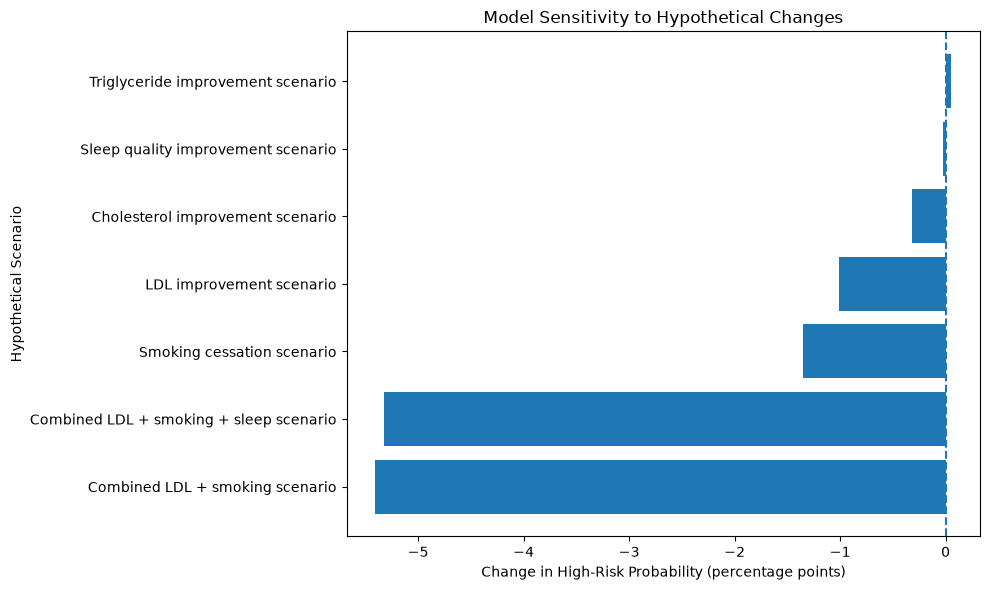

In [253]:
# ============================================================
# STEP 139: What-If Visualization
# ============================================================

what_if_df = (
    final_patient_report[
        'what_if'
    ]
    .copy()
)

plot_df = what_if_df[
    what_if_df['Scenario'] != 'Current state'
].copy()

plot_df = (
    plot_df
    .sort_values(
        'High_Change_pp'
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df['Scenario'],
    plot_df['High_Change_pp']
)

plt.axvline(
    0,
    linestyle='--'
)

plt.xlabel(
    'Change in High-Risk Probability (percentage points)'
)

plt.ylabel(
    'Hypothetical Scenario'
)

plt.title(
    'Model Sensitivity to Hypothetical Changes'
)

plt.tight_layout()
plt.show()

In [254]:
# ============================================================
# STEP 139: FINAL MODEL VALIDATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_test_pred = calibrated_model.predict(X_test)

y_test_prob = calibrated_model.predict_proba(X_test)

# ------------------------------------------------------------
# Basic performance
# ------------------------------------------------------------

final_accuracy = accuracy_score(y_test, y_test_pred)

final_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_test_pred
)

final_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

final_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

final_logloss = log_loss(
    y_test,
    y_test_prob,
    labels=calibrated_model.classes_
)

final_macro_auc = roc_auc_score(
    y_test,
    y_test_prob,
    multi_class="ovr",
    average="macro",
    labels=calibrated_model.classes_
)

print("=" * 80)
print("FINAL MODEL VALIDATION")
print("=" * 80)

print(f"Accuracy            : {final_accuracy:.4f}")
print(f"Balanced Accuracy   : {final_balanced_accuracy:.4f}")
print(f"Macro F1            : {final_macro_f1:.4f}")
print(f"Weighted F1         : {final_weighted_f1:.4f}")
print(f"Macro ROC-AUC       : {final_macro_auc:.4f}")
print(f"Log Loss            : {final_logloss:.4f}")

print("\nCLASSIFICATION REPORT")
print("-" * 80)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

print("\nCONFUSION MATRIX")
print("-" * 80)

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=calibrated_model.classes_
)

print(cm)

FINAL MODEL VALIDATION
Accuracy            : 0.9050
Balanced Accuracy   : 0.8888
Macro F1            : 0.8934
Weighted F1         : 0.8998
Macro ROC-AUC       : 0.9815
Log Loss            : 0.4366

CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        High     0.8905    0.9760    0.9313       125
         Low     0.8804    1.0000    0.9364       162
    Moderate     0.9873    0.6903    0.8125       113

    accuracy                         0.9050       400
   macro avg     0.9194    0.8888    0.8934       400
weighted avg     0.9138    0.9050    0.8998       400


CONFUSION MATRIX
--------------------------------------------------------------------------------
[[122   2   1]
 [  0 162   0]
 [ 15  20  78]]


<Figure size 700x600 with 0 Axes>

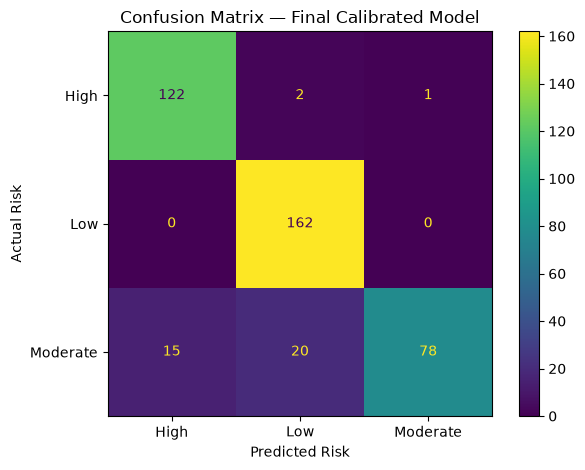

In [255]:
# ============================================================
# STEP 140: CONFUSION MATRIX VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=calibrated_model.classes_
)

disp.plot(values_format="d")

plt.title("Confusion Matrix — Final Calibrated Model")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.tight_layout()
plt.show()

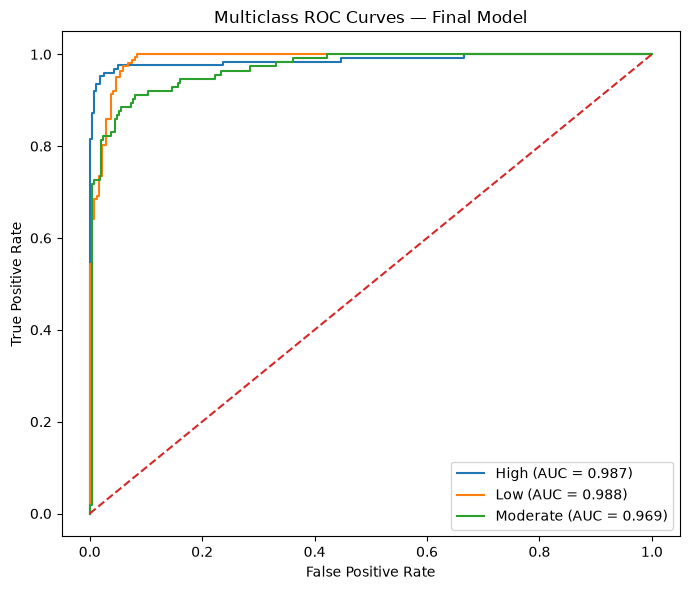

In [256]:
# ============================================================
# STEP 141: MULTICLASS ROC CURVE
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = calibrated_model.classes_

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(7, 6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves — Final Model")
plt.legend()
plt.tight_layout()
plt.show()

In [257]:
# ============================================================
# STEP 142: FINAL SHAP EXPLAINABILITY
# ============================================================

import shap

# Transform test data
X_test_transformed = final_preprocessor_fitted.transform(X_test)

# Create SHAP explainer
explainer = shap.Explainer(
    final_classifier,
    X_test_transformed
)

shap_values = explainer(
    X_test_transformed
)

print("SHAP calculation completed.")
print("SHAP shape:", shap_values.values.shape)

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


SHAP calculation completed.
SHAP shape: (400, 43, 3)


In [260]:
# ============================================================
# STEP 142B: GLOBAL SHAP IMPORTANCE
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=16
)

IndexError: list index out of range

Original SHAP shape: (400, 43, 3)

GLOBAL SHAP IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,num__Age,2.1173
1,num__LDL,1.5984
2,num__Family_History_CVD,1.4037
3,num__PRS_Cardiometabolic,1.3846
4,num__HDL,1.3071
5,num__Systolic_BP,0.7831
6,num__Cholesterol,0.7655
7,cat__Smoking_Status_Non-smoker,0.5273
8,cat__Smoking_Status_Current smoker,0.3180
9,num__PRS_Type2Diabetes,0.2965


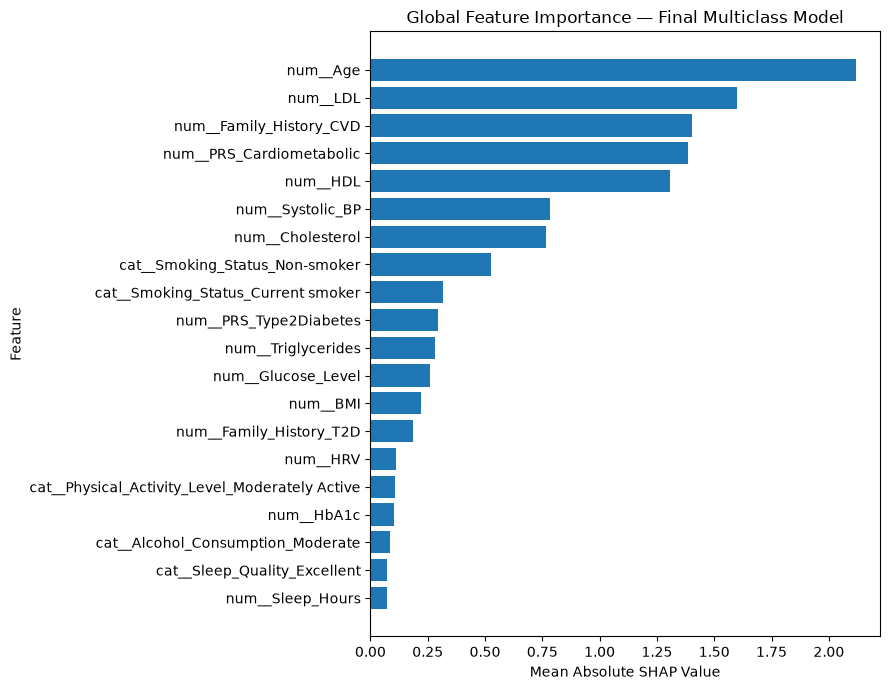

In [261]:
# ============================================================
# STEP 142B: GLOBAL SHAP IMPORTANCE — FIXED FOR MULTICLASS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Check SHAP dimensions
# ------------------------------------------------------------

print("Original SHAP shape:", shap_values.values.shape)

# ------------------------------------------------------------
# Calculate global importance
# Mean absolute SHAP across:
#   1. samples
#   2. risk classes
# ------------------------------------------------------------

shap_array = np.asarray(shap_values.values)

if shap_array.ndim == 3:

    # Shape:
    # samples × features × classes
    global_importance = np.mean(
        np.abs(shap_array),
        axis=(0, 2)
    )

elif shap_array.ndim == 2:

    # Shape:
    # samples × features
    global_importance = np.mean(
        np.abs(shap_array),
        axis=0
    )

else:

    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_array.shape}"
    )

# ------------------------------------------------------------
# Get feature names
# ------------------------------------------------------------

feature_names = list(transformed_feature_names)

# Safety check
if len(global_importance) != len(feature_names):

    raise ValueError(
        f"Feature mismatch: "
        f"{len(global_importance)} SHAP values vs "
        f"{len(feature_names)} feature names"
    )

# ------------------------------------------------------------
# Create importance table
# ------------------------------------------------------------

global_shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": global_importance
})

global_shap_df = (
    global_shap_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nGLOBAL SHAP IMPORTANCE")
print("=" * 70)

display(
    global_shap_df.head(20).round(4)
)

# ------------------------------------------------------------
# Plot top 20 features
# ------------------------------------------------------------

top_n = 20

plot_df = global_shap_df.head(top_n).sort_values(
    "Mean_Absolute_SHAP",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "Global Feature Importance — Final Multiclass Model"
)

plt.tight_layout()
plt.show()

In [262]:
# ============================================================
# STEP 143: PATIENT-LEVEL SHAP EXPLANATION
# ============================================================

patient_df = pd.DataFrame([new_patient])

patient_transformed = final_preprocessor_fitted.transform(
    patient_df[final_features]
)

patient_shap = explainer(
    patient_transformed
)

print("Patient SHAP explanation generated.")

Patient SHAP explanation generated.


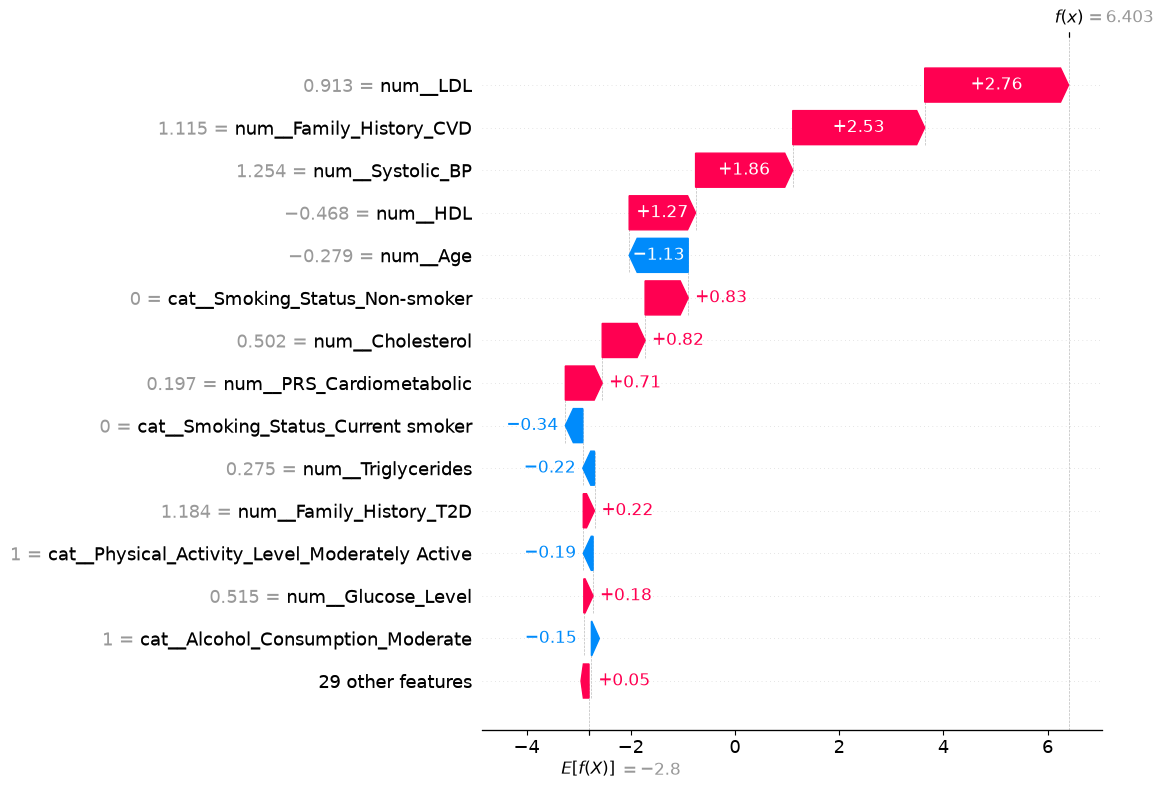

In [263]:
# Predicted class index
patient_prediction = calibrated_model.predict(
    patient_df[final_features]
)[0]

class_index = list(
    calibrated_model.classes_
).index(patient_prediction)

# Extract single-class explanation
single_class_explanation = shap.Explanation(
    values=patient_shap.values[0, :, class_index],
    base_values=patient_shap.base_values[0, class_index],
    data=patient_transformed[0],
    feature_names=transformed_feature_names
)

shap.plots.waterfall(
    single_class_explanation,
    max_display=15
)

In [264]:
# ============================================================
# STEP 144: EXPORT FINAL MODEL
# ============================================================

import joblib
import os

os.makedirs("personalised_healthcare_model", exist_ok=True)

joblib.dump(
    calibrated_model,
    "personalised_healthcare_model/calibrated_model.pkl"
)

joblib.dump(
    final_preprocessor_fitted,
    "personalised_healthcare_model/preprocessor.pkl"
)

joblib.dump(
    final_features,
    "personalised_healthcare_model/final_features.pkl"
)

joblib.dump(
    modifiable_features,
    "personalised_healthcare_model/modifiable_features.pkl"
)

print("Model files exported successfully.")

Model files exported successfully.


In [265]:
# ============================================================
# STEP 145: MODEL METADATA
# ============================================================

model_metadata = {
    "model_type": "Calibrated Multinomial Logistic Regression",
    "target": "Health_Risk",
    "n_features": len(final_features),
    "features": final_features,
    "classes": list(calibrated_model.classes_),

    "accuracy": final_accuracy,
    "balanced_accuracy": final_balanced_accuracy,
    "macro_f1": final_macro_f1,
    "weighted_f1": final_weighted_f1,
    "macro_roc_auc": final_macro_auc,
    "log_loss": final_logloss,

    "test_size": len(X_test),
    "random_state": 42,

    "prototype_status": True,
    "clinical_diagnostic_system": False
}

joblib.dump(
    model_metadata,
    "personalised_healthcare_model/model_metadata.pkl"
)

print("Model metadata saved.")

Model metadata saved.


In [266]:
# ============================================================
# STEP 146: MODEL CARD
# ============================================================

model_card = f"""
PERSONALISED HEALTHCARE RECOMMENDATION SYSTEM
============================================================

MODEL TYPE
Calibrated multinomial logistic regression.

TARGET
Health_Risk

RISK CLASSES
{list(calibrated_model.classes_)}

INPUT FEATURES
{len(final_features)}

FINAL FEATURES
{final_features}

TEST SET
{len(X_test)} participants

PERFORMANCE
------------------------------------------------------------
Accuracy              : {final_accuracy:.4f}
Balanced Accuracy     : {final_balanced_accuracy:.4f}
Macro F1              : {final_macro_f1:.4f}
Weighted F1            : {final_weighted_f1:.4f}
Macro ROC-AUC          : {final_macro_auc:.4f}
Log Loss              : {final_logloss:.4f}

SYSTEM COMPONENTS
------------------------------------------------------------
1. Patient data input
2. Data preprocessing
3. Risk classification
4. Probability estimation
5. Model explainability
6. Clinical safety gate
7. Recommendation prioritisation
8. What-if model sensitivity
9. Personalised report generation

IMPORTANT LIMITATIONS
------------------------------------------------------------
This system is a research prototype.

It is NOT a diagnostic system.

It is NOT a treatment recommendation system.

Model contributions represent predictive model behaviour
and should not be interpreted as causal effects.

What-if scenarios represent model sensitivity rather than
causal treatment effects.

Clinical thresholds and recommendation rules require
appropriate clinical validation before real-world deployment.

External validation in an independent population is required.

The dataset may contain synthetic or algorithmically generated
relationships; therefore, excellent internal performance does
not establish clinical validity or generalisability.

The model should not replace professional medical assessment.
"""

with open(
    "personalised_healthcare_model/model_card.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(model_card)

print("Model card created successfully.")

Model card created successfully.


In [267]:
# ============================================================
# STEP 147: FINAL END-TO-END SYSTEM TEST
# ============================================================

final_patient_report = personalized_healthcare_system(
    new_patient,
    run_what_if=True
)

final_report = build_final_report(
    final_patient_report
)

print_patient_report(
    final_report
)



       PERSONALISED HEALTHCARE ASSESSMENT

RISK CATEGORY: HIGH

RISK PROBABILITIES
--------------------------------------------------------------------------------
High        :  78.18%
Moderate    :  21.80%
Low         :   0.02%

TOP MODEL CONTRIBUTORS
--------------------------------------------------------------------------------
1. LDL (2.739)
2. Family_History_CVD (2.379)
3. Systolic_BP (1.703)
4. HDL (1.219)
5. Age (-1.033)

PRIORITY ACTIONS
--------------------------------------------------------------------------------

#1 LDL
   Value: 145.0
   Signal: MODERATE
   Actionability: MODIFIABLE
   Recommendation: Consider clinical assessment of LDL cholesterol and review of overall cardiovascular risk. Dietary pattern and other lipid-management strategies should be discussed with an appropriate healthcare professional.

#2 Blood_Pressure
   Value: 128.0/82.0 mmHg
   Signal: MODERATE
   Actionability: CONTEXT_DEPENDENT
   Recommendation: Review blood pressure using repeated measur

In [268]:
# ============================================================
# STEP 139: FREEZE FINAL MODEL CONFIGURATION
# ============================================================

import json
import os

os.makedirs("final_model_artifacts", exist_ok=True)

# ------------------------------------------------------------
# Final model classes
# ------------------------------------------------------------

final_classes = list(calibrated_model.classes_)

# ------------------------------------------------------------
# Final raw feature list
# ------------------------------------------------------------

final_raw_features = [
    "Age",
    "BMI",
    "Cholesterol",
    "Glucose_Level",
    "HbA1c",
    "Systolic_BP",
    "Diastolic_BP",
    "LDL",
    "HDL",
    "Triglycerides",
    "CRP",
    "eGFR",
    "Waist_Circumference",
    "Resting_Heart_Rate",
    "HRV",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Physical_Activity_Level",
    "Diet_Type",
    "Sleep_Quality",
    "Sleep_Hours",
    "PRS_Cardiometabolic",
    "PRS_Type2Diabetes",
    "APOE_e4_Carrier",
    "BRCA_Pathogenic_Variant",
    "Family_History_CVD",
    "Family_History_T2D"
]

# ------------------------------------------------------------
# Approved actionable features
# ------------------------------------------------------------

approved_actionable_features = [
    "LDL",
    "Cholesterol",
    "Triglycerides",
    "Smoking_Status",
    "Physical_Activity_Level",
    "Diet_Type",
    "Sleep_Quality",
    "Sleep_Hours",
    "Alcohol_Consumption",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP",
    "Glucose_Level",
    "HbA1c",
    "Waist_Circumference"
]

# ------------------------------------------------------------
# Configuration object
# ------------------------------------------------------------

final_config = {
    "model_type": "Calibrated Multinomial Logistic Regression",
    "calibration": "Sigmoid",
    "calibration_cv": 5,
    "classification_classes": final_classes,
    "number_of_raw_features": len(final_raw_features),
    "raw_features": final_raw_features,
    "number_of_actionable_features": len(
        approved_actionable_features
    ),
    "approved_actionable_features":
        approved_actionable_features,
    "random_state": 42,
    "research_prototype": True,
    "clinical_diagnostic_system": False,
    "causal_interpretation": False
}

# ------------------------------------------------------------
# Save configuration
# ------------------------------------------------------------

with open(
    "final_model_artifacts/final_model_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_config,
        f,
        indent=4
    )

print("=" * 80)
print("FINAL MODEL CONFIGURATION")
print("=" * 80)

print("Model type:", final_config["model_type"])
print("Classes:", final_classes)
print("Raw features:", len(final_raw_features))
print(
    "Actionable features:",
    len(approved_actionable_features)
)

print("\nConfiguration saved successfully.")

FINAL MODEL CONFIGURATION
Model type: Calibrated Multinomial Logistic Regression
Classes: ['High', 'Low', 'Moderate']
Raw features: 27
Actionable features: 15

Configuration saved successfully.


In [270]:
# ============================================================
# FINAL FEATURE LIST
# ============================================================

final_features = [
    "Age",
    "BMI",
    "Cholesterol",
    "Glucose_Level",
    "HbA1c",
    "Systolic_BP",
    "Diastolic_BP",
    "LDL",
    "HDL",
    "Triglycerides",
    "CRP",
    "eGFR",
    "Waist_Circumference",
    "Resting_Heart_Rate",
    "HRV",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Physical_Activity_Level",
    "Diet_Type",
    "Sleep_Quality",
    "Sleep_Hours",
    "PRS_Cardiometabolic",
    "PRS_Type2Diabetes",
    "APOE_e4_Carrier",
    "BRCA_Pathogenic_Variant",
    "Family_History_CVD",
    "Family_History_T2D"
]

print(f"Final features: {len(final_features)}")
print("FINAL FEATURE LIST READY")

Final features: 27
FINAL FEATURE LIST READY


In [271]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import os
import json
import joblib

os.makedirs("final_model_artifacts", exist_ok=True)

# Save trained model
joblib.dump(
    calibrated_model,
    "final_model_artifacts/calibrated_final_model.pkl"
)

# Save feature configuration
with open("final_model_artifacts/model_config.json", "w") as f:
    json.dump({
        "features": final_features,
        "n_features": len(final_features),
        "classes": list(calibrated_model.classes_)
    }, f, indent=2)

print("FINAL MODEL SAVED")
print(f"Features: {len(final_features)}")
print("Files created:")
print("- calibrated_final_model.pkl")
print("- model_config.json")

FINAL MODEL SAVED
Features: 27
Files created:
- calibrated_final_model.pkl
- model_config.json


In [272]:
# ============================================================
# FINAL MODEL CHECK
# ============================================================

import joblib

final_model = joblib.load(
    "final_model_artifacts/calibrated_final_model.pkl"
)

print("FINAL MODEL LOADED")
print("Ready for prediction.")

FINAL MODEL LOADED
Ready for prediction.


In [273]:
# ============================================================
# FINAL PREDICTION FUNCTION
# ============================================================

import pandas as pd
import numpy as np

def predict_patient(patient_data):

    # Convert input to DataFrame
    X = pd.DataFrame([patient_data])

    # Ensure correct feature order
    X = X[final_features]

    # Prediction
    prediction = final_model.predict(X)[0]

    # Probabilities
    probabilities = final_model.predict_proba(X)[0]

    probability_dict = {
        cls: round(float(prob), 4)
        for cls, prob in zip(final_model.classes_, probabilities)
    }

    return {
        "risk_category": prediction,
        "probabilities": probability_dict
    }

print("FINAL PREDICTION FUNCTION READY")

FINAL PREDICTION FUNCTION READY


In [274]:
# ============================================================
# TEST PATIENT
# ============================================================

test_patient = {
    "Age": 50,
    "BMI": 27,
    "Cholesterol": 215,
    "Glucose_Level": 100,
    "HbA1c": 5.6,
    "Systolic_BP": 128,
    "Diastolic_BP": 82,
    "LDL": 145,
    "HDL": 45,
    "Triglycerides": 165,
    "CRP": 2.0,
    "eGFR": 90,
    "Waist_Circumference": 90,
    "Resting_Heart_Rate": 75,
    "HRV": 45,
    "Smoking_Status": "Never",
    "Alcohol_Consumption": "Low",
    "Physical_Activity_Level": "Moderately Active",
    "Diet_Type": "Balanced",
    "Sleep_Quality": "Good",
    "Sleep_Hours": 7,
    "PRS_Cardiometabolic": 0.2,
    "PRS_Type2Diabetes": 0.1,
    "APOE_e4_Carrier": 0,
    "BRCA_Pathogenic_Variant": 0,
    "Family_History_CVD": 1,
    "Family_History_T2D": 0
}

result = predict_patient(test_patient)

print("RISK CATEGORY:", result["risk_category"])
print("\nRISK PROBABILITIES:")

for risk, probability in result["probabilities"].items():
    print(f"{risk}: {probability:.2%}")

RISK CATEGORY: High

RISK PROBABILITIES:
High: 78.44%
Low: 0.01%
Moderate: 21.55%


In [275]:
# ============================================================
# FINAL PATIENT REPORT
# ============================================================

def generate_final_report(patient_data):

    result = predict_patient(patient_data)

    print("=" * 60)
    print("PERSONALISED HEALTHCARE SYSTEM")
    print("=" * 60)

    print(f"\nRisk Category: {result['risk_category']}")

    print("\nRisk Probabilities:")
    for risk, probability in result["probabilities"].items():
        print(f"  {risk}: {probability:.2%}")

    print("\n" + "=" * 60)
    print("RESEARCH PROTOTYPE")
    print("=" * 60)
    print("This output is for research purposes only.")
    print("It is not a diagnostic or treatment system.")

    return result


final_result = generate_final_report(test_patient)

PERSONALISED HEALTHCARE SYSTEM

Risk Category: High

Risk Probabilities:
  High: 78.44%
  Low: 0.01%
  Moderate: 21.55%

RESEARCH PROTOTYPE
This output is for research purposes only.
It is not a diagnostic or treatment system.


In [277]:
# ============================================================
# FINAL COMPLETE REPORT
# ============================================================

def complete_patient_report(patient_data, explanation_df=None,
                            recommendations=None, what_if=None):

    result = predict_patient(patient_data)

    print("=" * 65)
    print("PERSONALISED HEALTHCARE SYSTEM")
    print("=" * 65)

    print(f"\nRisk Category: {result['risk_category']}")

    print("\nRisk Probabilities:")
    for risk, probability in result["probabilities"].items():
        print(f"  {risk}: {probability:.2%}")

    # Top contributors
    if explanation_df is not None:
        print("\nTop Model Contributors:")
        print(explanation_df.head(5).to_string(index=False))

    # Recommendations
    if recommendations:
        print("\nPriority Actions:")
        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec}")

    # What-if analysis
    if what_if is not None:
        print("\nWhat-if Analysis:")
        print(what_if)

    print("\n" + "=" * 65)
    print("SAFETY NOTE")
    print("=" * 65)
    print("Research prototype only.")
    print("Not a diagnostic or treatment system.")
    print("What-if results represent model sensitivity,")
    print("not causal treatment effects.")

    return result

In [278]:
# ============================================================
# CREATE STREAMLIT APP
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import joblib
import json

# Load model
model = joblib.load("final_model_artifacts/calibrated_final_model.pkl")

with open("final_model_artifacts/model_config.json") as f:
    config = json.load(f)

features = config["features"]

st.title("Personalised Healthcare Risk Assessment")
st.caption("Research Prototype — Not a Diagnostic System")

st.header("Patient Information")

patient = {}

for feature in features:

    if feature in [
        "Smoking_Status",
        "Alcohol_Consumption",
        "Physical_Activity_Level",
        "Diet_Type",
        "Sleep_Quality"
    ]:
        patient[feature] = st.text_input(feature)

    elif feature in [
        "APOE_e4_Carrier",
        "BRCA_Pathogenic_Variant",
        "Family_History_CVD",
        "Family_History_T2D"
    ]:
        patient[feature] = st.number_input(
            feature, min_value=0, max_value=1, value=0
        )

    else:
        patient[feature] = st.number_input(
            feature, value=0.0
        )

if st.button("Assess Health Risk"):

    X = pd.DataFrame([patient])[features]

    prediction = model.predict(X)[0]
    probabilities = model.predict_proba(X)[0]

    st.subheader("Risk Assessment")

    st.write(f"### Risk Category: {prediction}")

    probability_df = pd.DataFrame({
        "Risk Category": model.classes_,
        "Probability": probabilities
    })

    st.dataframe(
        probability_df.style.format(
            {"Probability": "{:.2%}"}
        ),
        use_container_width=True
    )

    st.warning(
        "This is a research prototype. "
        "It should not be used for diagnosis or treatment decisions."
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("STREAMLIT APP CREATED")
print("File: app.py")

STREAMLIT APP CREATED
File: app.py


In [ ]:
# ============================================================
# LAUNCH STREAMLIT APP
# ============================================================

!streamlit run app.py